# <font color="steelblue">Bosques aleatorios (Random Forest) y alternativas</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 08/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install shap
!pip install mlxtend --upgrade --no-deps

import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from auto_ML import *

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, ParameterGrid, cross_val_score, learning_curve
from sklearn.datasets import make_blobs, make_moons, make_classification, load_digits
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             f1_score, accuracy_score)
from mlxtend.plotting import plot_decision_regions
import shap
RNG = 123

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.3 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4


# <font color="steelblue">Introducción</font>

Un **único árbol de decisión** es intuitivo y fácil de interpretar, pero **inestable**: pequeños cambios en los datos producen árboles muy distintos. Esa **alta varianza** limita su capacidad predictiva. La idea para corregirlo es tan simple como poderosa y se resume en la **sabiduría de la multitud**: en lugar de fiarlo todo a un único árbol —que puede equivocarse por el camino concreto que tomó—, se consulta a **muchos** y se combina su opinión. Como cada árbol comete errores **distintos**, al promediar sus predicciones esos errores tienden a **cancelarse** y queda lo que tienen en común, que suele ser la señal correcta.

Los **bosques aleatorios** (*Random Forest*) llevan esa idea a la práctica: combinan **muchos árboles** —cada uno entrenado sobre datos y variables ligeramente distintos, para que no sean copias unos de otros— y **agregan** sus predicciones (por votación), obteniendo un modelo **mucho más robusto y preciso**. El precio a pagar es que **dejamos de tener un único árbol que dibujar**: ganamos exactitud a cambio de una interpretación menos directa, un compromiso que abordaremos con las herramientas de explicabilidad.

En este cuaderno desarrollamos en profundidad el bosque aleatorio y sus **alternativas en scikit-learn** (Extra Trees y el Bagging genérico de árboles), siempre en **clasificación**: cómo se **entrena**, cómo **predice**, cómo medir la **importancia de las variables**, qué efecto tienen sus **hiperparámetros** y el **out-of-bag**, y cómo diagnosticar el **sobreajuste**. Dedicamos además una sección amplia a la **explicabilidad (XAI)** con **valores de Shapley** y la librería `shap`. La teoría se acompaña de **ejemplos ilustrativos** sencillos y, al final, de cinco aplicaciones de clasificación.

# <font color="steelblue">1. ¿Qué es un bosque aleatorio?</font>

Un **bosque aleatorio** es un conjunto (*ensemble*) de árboles de decisión. Cada árbol se entrena sobre una **muestra bootstrap** distinta (muestreo con reemplazamiento) de los datos y, además, en cada división solo puede usar un **subconjunto aleatorio de variables**. La predicción de una observación nueva se obtiene **agregando** las de todos los árboles: **voto mayoritario** en clasificación (la clase modal) y **promedio** en regresión.

<small><img src=https://raw.githubusercontent.com/ia4legos/MachineLearning/main/images/bagging-1.png width="650" height="300"></small>

El árbol único era **inestable**; para que combinar árboles sirva de algo, necesitamos que sean **diferentes entre sí**. De ahí las dos inyecciones de aleatoriedad, cada una con su papel:

* **Muestra bootstrap (filas):** cada árbol ve un conjunto de datos ligeramente distinto, así que crece de forma distinta.
* **Subconjunto de variables por división (columnas):** sin esto, si hubiera una variable muy predictiva, **casi todos** los árboles la elegirían para el primer corte y acabarían pareciéndose mucho. Al ocultar variables al azar en cada división, se obliga a los árboles a **explorar caminos alternativos**.

La clave es esta segunda idea: promediar sirve **solo si los árboles son poco parecidos**. Dos árboles que se equivocan en lo mismo no se corrigen entre ellos; el objetivo es que sus errores sean **independientes** para que, al agregarlos, se compensen. A esto se le llama **decorrelacionar** los árboles.

Los modelos de bosques aleatorios pertenecen a la familia **bagging** (*bootstrap aggregating*), cuyo objetivo es **reducir la varianza** de modelos inestables. La intuición, apoyada en el Teorema Central del Límite, es que **promediar** $B$ modelos poco correlacionados con varianza $\sigma^2$ reduce la varianza del conjunto hacia $\sigma^2/B$, **sin aumentar el sesgo**. Como los árboles profundos tienen **poco sesgo y mucha varianza**, son el candidato ideal: al promediar muchos, el bosque conserva su flexibilidad pero estabiliza enormemente la predicción. (El matiz importante: esa reducción es plena solo si los árboles están **decorrelacionados**; por eso el subconjunto de variables no es un detalle, sino lo que hace funcionar al bosque.)

**Ventajas**
* Capturan **relaciones no lineales** e interacciones complejas y seleccionan predictores de forma automática.
* No paramétricos: **no exigen estandarización** ni distribuciones concretas, y son **robustos a valores atípicos**.
* Estiman su error de generalización con el ***out-of-bag*** (sin validación cruzada).
* Permiten **cuantificar la importancia** de los predictores.
* **Muy poco sensibles a los hiperparámetros**: funcionan bien «de fábrica», y añadir más árboles nunca sobreajusta (solo deja de mejorar).

**Inconvenientes**
* Se **pierde la interpretabilidad** de un único árbol (no hay un diagrama único) → de ahí la necesidad de técnicas **XAI**.
* Sesgo hacia variables **continuas o de alta cardinalidad** (más puntos de corte posibles).
* **No extrapolan** fuera del rango observado en el entrenamiento.
* Más **costosos** en cómputo y memoria (muchos árboles) y más **lentos al predecir** que un modelo simple.

## <font color="steelblue">1.1. Visualización: de árboles inestables a un bosque estable</font>

La mejor forma de *ver* la idea es entrenar **varios árboles sobre muestras bootstrap distintas** y comparar sus fronteras de decisión con la del bosque. Cada árbol individual produce una frontera **irregular y muy distinta** de los demás (alta varianza); el bosque, al **promediarlos**, obtiene una frontera **suave y robusta**. Probanos el comportamento sobre un banco simulado de datos en dos dimensiones.

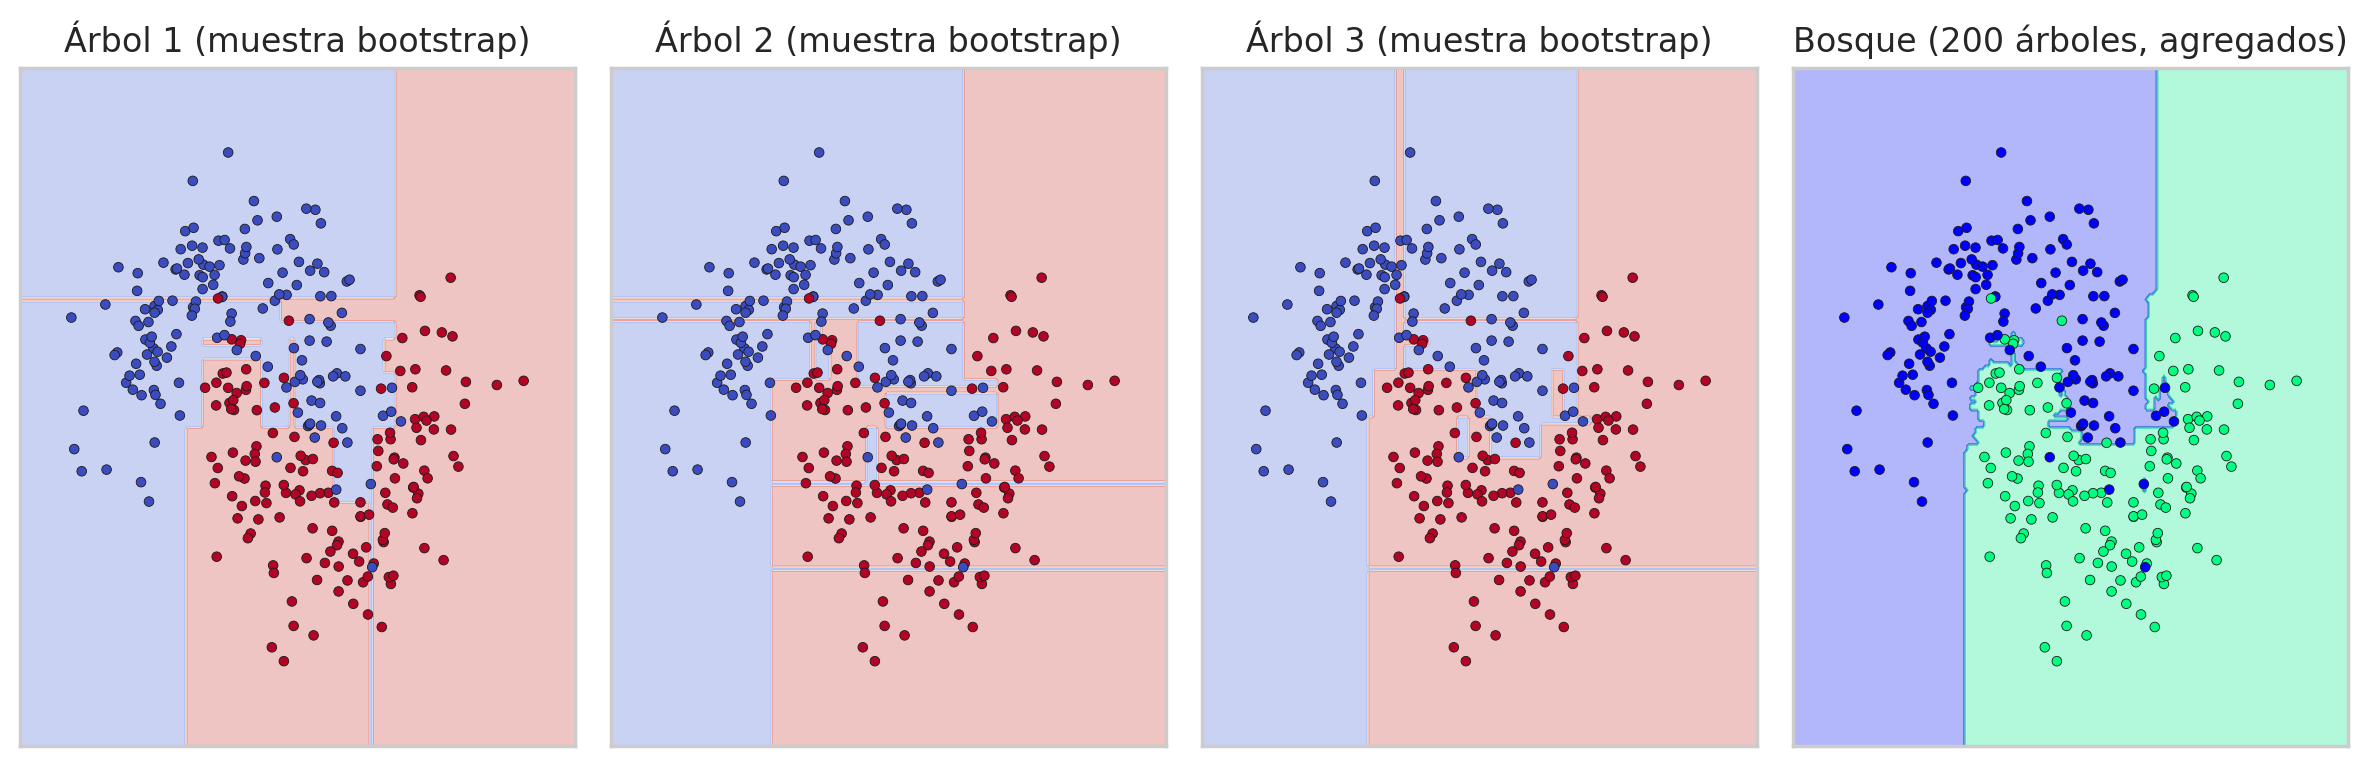

In [2]:
# Datos de juguete en 2D (dos lunas solapadas)
# Generación del banco de datos
Xv, yv = make_moons(n_samples=300, noise=0.30, random_state=0)
xx, yy = np.meshgrid(np.linspace(Xv[:,0].min()-.5, Xv[:,0].max()+.5, 200),
                     np.linspace(Xv[:,1].min()-.5, Xv[:,1].max()+.5, 200))
rng = np.random.RandomState(0)
# Representamso la solucióna pra tres árboles y para el resultado agregado de 200 árboles
fig, ax = plt.subplots(1, 4, figsize=(12, 4))
for k in range(3):
    idx = rng.choice(len(Xv), len(Xv), replace=True)          # muestra bootstrap
    arbol = DecisionTreeClassifier(random_state=k).fit(Xv[idx], yv[idx])
    Z = arbol.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax[k].contourf(xx, yy, Z, alpha=.3, cmap='coolwarm')
    ax[k].scatter(Xv[:,0], Xv[:,1], c=yv, s=12, cmap='coolwarm', edgecolor='k', linewidth=.3)
    ax[k].set_title(f'Árbol {k+1} (muestra bootstrap)')
bosque = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xv, yv)
Z = bosque.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax[3].contourf(xx, yy, Z, alpha=.3, cmap='winter')
ax[3].scatter(Xv[:,0], Xv[:,1], c=yv, s=12, cmap='winter', edgecolor='k', linewidth=.3)
ax[3].set_title('Bosque (200 árboles, agregados)')
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

Los tres primeros paneles son **árboles individuales**, cada uno entrenado con una muestra bootstrap distinta: sus fronteras son **escalonadas y diferentes entre sí** (mucha varianza; pequeñas islas que persiguen puntos concretos = sobreajuste). El cuarto panel es el **bosque**: al promediar 200 árboles, la frontera se **suaviza** y deja de perseguir el ruido. *Esa* es la esencia del Random Forest: combinar muchos modelos inestables para obtener uno estable.

# <font color="steelblue">2. Algoritmo de entrenamiento</font>

El entrenamiento de un bosque aleatorio con $B$ árboles se detalla así:

**Para cada árbol $b = 1, \dots, B$:**

1. **Muestra bootstrap.** Extraer, **con reemplazamiento**, $n$ observaciones de la muestra de entrenamiento (de tamaño $n$). Algunas observaciones se repetirán y otras **no saldrán** (serán *out-of-bag* para ese árbol). En promedio, cada muestra bootstrap contiene solo **~2/3 de las observaciones distintas**; el **~1/3 restante** queda fuera y servirá para estimar el error sin validación cruzada (el *out-of-bag* de la sección siguiente).
2. **Hacer crecer el árbol** sobre esa muestra, y en **cada nodo**:
   * Seleccionar **al azar $m$ de las $p$ variables** disponibles (no todas). Esta elección se repite **en cada nodo**, no una vez por árbol. El valor habitual en clasificación es $m=\sqrt{p}$ (parámetro `max_features`); cuanto **menor** es $m$, más distintos —**decorrelacionados**— salen los árboles.
   * Buscar, **solo entre esas $m$**, la división (variable + punto de corte) que **más reduce la impureza** (Gini o entropía).
   * Dividir el nodo y repetir en los nodos hijos.
3. **Sin poda.** El árbol crece **hasta el final** (hojas puras o el mínimo de observaciones por hoja). Cada árbol tiene así **poco sesgo y mucha varianza**, y no se poda **a propósito**: esa varianza no preocupa porque el promedio del conjunto se encargará de reducirla. En un bosque, la regularización la aporta el **número de árboles**, no la poda de cada uno.

**Predicción del conjunto:** para una observación nueva, se obtiene la predicción de los $B$ árboles y se **agrega** (voto mayoritario en clasificación). En la práctica, scikit-learn no cuenta votos «duros», sino que **promedia las probabilidades** que estima cada árbol y elige la clase con mayor probabilidad media; de paso, esa media sirve como **probabilidad** de la predicción.

Dos apuntes prácticos:
* **$B$ (número de árboles) no sobreajusta:** cuantos más, mejor (o igual); solo aumenta el coste. Se elige un valor lo bastante alto para que el rendimiento se **estabilice** (`n_estimators`).
* Los árboles son **independientes** entre sí, así que el entrenamiento es fácilmente **paralelizable** (`n_jobs=-1`).

En pseudocódigo:

```
para b = 1..B:
    D_b  <- muestra_bootstrap(D)              # paso 1
    árbol_b <- construir_árbol(D_b, m)        # pasos 2-3, con m variables al azar por nodo
predicción(x) = moda( árbol_1(x), ..., árbol_B(x) )
```

## <font color="steelblue">2.1. La clave: variables aleatorias por nodo</font>

El bagging clásico solo hace el paso 1 (bootstrap) y en el paso 2 usaría **todas** las variables. Su punto débil: si hay **un predictor muy dominante**, casi todos los árboles lo eligen en su primera división y resultan **muy parecidos** (correlacionados); promediar árboles correlacionados **apenas** reduce la varianza.

### <font color="steelblue">Por qué el bagging «puro» se queda corto</font>

Recordemos la fórmula del promedio: agregar $B$ modelos reduce la varianza hacia $\sigma^2/B$ **solo si son poco parecidos**. Si están correlacionados, la varianza del promedio no baja hasta $\sigma^2/B$, sino que se queda «anclada» en un valor mayor que depende de esa correlación $\rho$: por muchos árboles que añadas, **no puedes bajar de ese suelo**. En otras palabras, con árboles muy correlacionados, sumar más árboles deja de ayudar pronto. El problema, entonces, no es el número de árboles, sino su **parecido**.

### <font color="steelblue">La solución: esconder variables en cada nodo</font>

Random Forest añade el sorteo de $m$ variables por nodo: en promedio, una fracción $(p-m)/p$ de las divisiones **no podrá** usar el predictor dominante, dando paso a otros. Esto **descorrelaciona** los árboles y hace que su agregación reduzca **mucho más** la varianza.

Un ejemplo lo hace evidente. Supón $p=10$ variables y $m=\sqrt{10}\approx 3$: en cada nodo, el predictor dominante tiene solo **3 de 10** posibilidades de estar entre las candidatas, así que en **~70 %** de los nodos el árbol **se ve obligado a mirar otras variables**. El resultado es un conjunto de árboles que exploran estructuras **distintas** de los datos —justo lo que hace que promediarlos funcione—.

### <font color="steelblue">El compromiso al elegir $m$</font>

El valor de $m$ (parámetro `max_features`) regula un equilibrio:

* **$m$ pequeño** → árboles muy **diversos** (más decorrelación, menos varianza), pero cada árbol es **individualmente más débil**, porque a veces se le ocultan las mejores variables (más sesgo).
* **$m$ grande** → cada árbol es **más fuerte**, pero todos se **parecen más** (menos ganancia al promediar). En el extremo $m=p$ recuperamos el bagging clásico.

Las recomendaciones habituales equilibran ambos efectos y suelen funcionar muy bien por defecto:

$$m \approx \sqrt{p}\ \text{(clasificación)},\qquad m \approx p/3\ \text{(regresión)}.$$

Aun así, $m$ es de los pocos hiperparámetros del bosque que **merece la pena afinar** por validación cruzada si se busca el máximo rendimiento.




## <font color="steelblue">2.2. Ejemplo ilustrativo: la muestra bootstrap y el *out-of-bag*</font>

Veamos, con 12 observaciones, qué entra en una muestra bootstrap y qué queda **fuera de la bolsa** (*out-of-bag*, OOB):

In [3]:
rng = np.random.RandomState(1)
n = 12
muestra = rng.choice(n, size=n, replace=True)           # bootstrap: n con reemplazamiento
dentro = sorted(set(muestra))
fuera  = [i for i in range(n) if i not in dentro]        # OOB de este árbol
print('Observaciones originales      :', list(range(n)))
print('Muestra bootstrap (con repet.):', list(muestra))
print('Dentro de la bolsa (entrenan) :', dentro)
print('Fuera de la bolsa (OOB)       :', fuera)
print(f'Proporción OOB = {len(fuera)/n:.0%}  (teóricamente, para n grande, ~37%)')

Observaciones originales      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Muestra bootstrap (con repet.): [np.int64(5), np.int64(11), np.int64(8), np.int64(9), np.int64(11), np.int64(5), np.int64(0), np.int64(0), np.int64(1), np.int64(7), np.int64(6), np.int64(9)]
Dentro de la bolsa (entrenan) : [np.int64(0), np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11)]
Fuera de la bolsa (OOB)       : [2, 3, 4, 10]
Proporción OOB = 33%  (teóricamente, para n grande, ~37%)


Al muestrear $n$ veces con reemplazamiento, algunas observaciones se **repiten** y otras **no aparecen**: estas últimas son las **OOB** de ese árbol. Para $n$ grande, la probabilidad de que una observación quede fuera es $(1-1/n)^n \to e^{-1}\approx 0.37$, es decir, **alrededor de un tercio**. Esas observaciones OOB, al no haber participado en el entrenamiento de ese árbol, sirven para **validarlo gratis** (lo usaremos en la sección 6).

# <font color="steelblue">3. Predicción mediante bosque aleatorio</font>

Para predecir una observación, cada árbol la lleva hasta uno de sus **nodos terminales** y emite una predicción individual. El bosque las combina de dos formas:

* **Voto duro:** la **clase modal** (la más votada entre los $B$ árboles). Cada árbol aporta **un voto**, todos con el mismo peso, y gana la mayoría. Es la «democracia» del bosque: solo cuenta a qué clase apuesta cada árbol, no con cuánta seguridad.
* **Voto blando / probabilidades:** cada árbol aporta las **proporciones de clase** de su nodo terminal (por ejemplo, una hoja con 8 casos de A y 2 de B da 0.8 para A); se **promedian** sobre los $B$ árboles y se obtiene una probabilidad por clase. Se clasifica en la de mayor probabilidad. Aquí cada árbol vota **con su nivel de confianza**, así que un árbol muy seguro pesa más que uno dubitativo. Es lo que devuelve `predict_proba`.

Por ejemplo, con 5 árboles y dos clases {A, B}, si las predicciones son A, A, B, A, B, el **voto duro** da **A** (3 contra 2); y si las probabilidades de A fueran 0.6, 0.7, 0.4, 0.9, 0.3, el **voto blando** promedia $\bar p_A = 0.58 \Rightarrow$ **A**. El voto blando suele ser algo más fino porque tiene en cuenta la **confianza** de cada árbol.

### <font color="steelblue">Cuándo se notan la diferencia</font>

En muchos casos ambos métodos coinciden, pero **no siempre**, y ahí está la clave. Imagina 5 árboles con probabilidades de A iguales a **0.55, 0.55, 0.55, 0.10, 0.10**:

* **Voto duro:** los tres primeros votan A (0.55 > 0.5) y los dos últimos, B → gana **A** (3–2).
* **Voto blando:** $\bar p_A = (0.55+0.55+0.55+0.10+0.10)/5 = 0.37$ → gana **B**.

La mayoría apostaba «a duras penas» por A, mientras que la minoría lo hacía con **mucha convicción** por B; el voto blando recoge ese matiz y el duro no. Por eso el voto blando suele **generalizar algo mejor** y da, además, una **probabilidad utilizable** (para ordenar por riesgo, ajustar el umbral de decisión o trazar la curva ROC).

**En la práctica (scikit-learn):** `RandomForestClassifier` usa **voto blando** por defecto —`predict` devuelve la clase de mayor probabilidad media y `predict_proba`, esas probabilidades—. Un matiz: esas probabilidades reflejan el **grado de acuerdo** del bosque, pero **no están perfectamente calibradas** (no hay que leerlas como una probabilidad exacta); si se necesita esa calibración, se recurre a `CalibratedClassifierCV`.

# <font color="steelblue">4. Alternativas en scikit-learn</font>

Dentro de scikit-learn conviven tres formas de hacer **bagging de árboles**, que se diferencian en **cuánta aleatoriedad** introducen. La idea es leerlas como una **escalera**: cada peldaño añade una fuente de azar más, que **decorrelaciona** los árboles (baja la varianza) a costa de hacer cada árbol individual un poco **más débil** (sube algo el sesgo).

| Modelo | Muestra observaciones | Variables por división | Punto de corte |
|---|---|---|---|
| **`BaggingClassifier`** (árboles) | sí (bootstrap) | **todas** | **óptimo** |
| **`RandomForestClassifier`** | sí (bootstrap) | **aleatorias** ($m$) | **óptimo** entre las $m$ |
| **`ExtraTreesClassifier`** | no (todo el set)\* | **aleatorias** ($m$) | **aleatorio** (umbral al azar) |

\* `ExtraTreesClassifier` usa por defecto `bootstrap=False`; puede activarse para disponer de OOB.

Recorriendo la escalera, cada modelo añade una «palanca» de azar sobre el anterior:

* **Bagging de árboles** — *azar solo en las filas.* Solo añade el remuestreo de observaciones (bootstrap); en cada división sigue mirando **todas** las variables y buscando el corte óptimo. Si hay un predictor dominante, todos los árboles lo eligen y quedan muy **correlacionados**, así que la reducción de varianza es limitada. Hoy se usa poco para árboles (para eso está Random Forest), pero es útil porque `BaggingClassifier` acepta **cualquier** estimador base, no solo árboles.
* **Random Forest** — *azar en filas y columnas.* Añade la **selección aleatoria de $m$ variables** por nodo → los árboles exploran caminos distintos → más independientes → **mayor reducción de varianza**. Es el equilibrio de referencia y el que se usa por defecto.
* **Extra Trees** (*Extremely Randomized Trees*) — *azar en filas, columnas y en el propio corte.* Además de las variables aleatorias, **no busca el mejor corte**: para cada variable candidata **sortea un umbral al azar** y se queda con el mejor de esos cortes aleatorios. Esto tiene dos consecuencias:
  * **Estadística:** un poco **más de sesgo** (los cortes ya no son óptimos) pero **menos varianza aún** (más diversidad entre árboles), que a menudo se compensan.
  * **Computacional:** es **más rápido de entrenar**, porque el paso caro de un árbol —**probar todos los umbrales** de cada variable para hallar el óptimo— se sustituye por elegir **uno al azar**.

  En la práctica, RF y Extra Trees suelen dar resultados muy parecidos; **probaremos ambos en todos los ejemplos reales**.

### <font color="steelblue">¿Cuál elegir?</font>

* **Random Forest** como **opción por defecto**: robusto, bien equilibrado y con OOB de serie.
* **Extra Trees** cuando quieras **más velocidad** o el bosque parezca sobreajustar (su mayor aleatoriedad regulariza un poco más); merece la pena compararlo con RF, como haremos.
* **Bagging genérico** cuando el estimador base **no** sea un árbol (p. ej. *baggear* un k-NN o un modelo inestable cualquiera).

> **¿Y el *boosting*?** Random Forest se compara con **Gradient Boosting Trees**: ambos usan árboles, pero el boosting los entrena **en secuencia** corrigiendo errores (no es bagging). RF tiene **menos hiperparámetros**, es **paralelizable**, **no sobreajusta al añadir árboles** y ofrece OOB; un boosting bien ajustado suele rendir algo más a costa de un ajuste más delicado. La diferencia de fondo: el bagging **reduce varianza** (parte de árboles fuertes y los promedia), mientras que el boosting **reduce sesgo** (parte de árboles débiles y los va sumando). El boosting se trata en otro cuaderno.

# <font color="steelblue">5. Importancia de los predictores</font>

Al combinar muchos árboles perdemos el diagrama interpretable de uno solo, pero ganamos medidas para **cuantificar la importancia** de cada predictor. Veremos **tres** opciones; las dos primeras aquí y la tercera (SHAP) en la sección 8.

## <font color="steelblue">5.1. Importancia por impureza (MDI)</font>

La **importancia por disminución media de impureza** (*Mean Decrease in Impurity*, MDI) es la forma más inmediata de medir cuánto aporta cada variable a un bosque aleatorio. Parte de una idea sencilla: una variable es tanto más importante cuanto más contribuye a **separar las clases**, es decir, a que los nodos del árbol sean cada vez más **puros**.

Su cálculo se apoya directamente en el proceso de construcción de los árboles. Cada vez que una variable se emplea para dividir un nodo, ese corte genera un **descenso de impureza** (medida con el índice de Gini o la entropía), que se **pondera por la proporción de observaciones** que atraviesan dicho nodo; de este modo, las divisiones situadas cerca de la raíz, que afectan a muchas observaciones, pesan más que las de nodos pequeños y profundos. Para obtener la importancia de una variable, se **suman** sus descensos de impureza a lo largo de todo el árbol y, a continuación, se **promedian sobre los $B$ árboles** del bosque. Por último, los valores se **normalizan** para que sumen 1, lo que permite interpretarlos como la fracción de la capacidad discriminante total que corresponde a cada variable.

Este promediado sobre muchos árboles es, precisamente, lo que distingue a la MDI de un bosque frente a la de un árbol único: al no depender de un solo modelo, el resultado es **considerablemente más estable**. La interpretación es directa: cuanto mayor es el valor, más contribuye la variable a ordenar los datos. En la práctica, se obtiene sin coste adicional a través del atributo `feature_importances_` del modelo, ya que se deriva de la información generada durante el propio entrenamiento.

Ahora bien, esta comodidad tiene contrapartidas que se deben conocer para no interpretar el resultado de forma ingenua. En primer lugar, la MDI presenta un **sesgo hacia las variables continuas o con muchas categorías** (alta cardinalidad): al ofrecer más puntos de corte posibles, tienen más oportunidades de producir divisiones que reduzcan la impureza, aunque sea en parte por azar, de modo que pueden aparecer como importantes sin serlo realmente. En segundo lugar, cuando dos variables están **correlacionadas** y aportan información similar, el bosque tiende a utilizar una u otra de forma alternativa, con lo que la importancia se **reparte** entre ambas y cada una puede parecer poco relevante aunque el par sí lo sea. Por último, conviene recordar que la MDI se calcula **sobre los datos de entrenamiento**: mide cuánto ayudó cada variable a ajustar esos datos, no necesariamente a generalizar, por lo que puede llegar a premiar el sobreajuste.

Por todo ello, la importancia por impureza debe entenderse como un **primer diagnóstico**, rápido y útil, pero no siempre definitivo. Cuando la interpretación resulta crítica —por ejemplo, al decidir qué variables conservar o al comunicar conclusiones—, es recomendable **contrastarla con la importancia por permutación** que veremos a continuación, calculada sobre datos no observados durante el entrenamiento y libre del sesgo de cardinalidad. Si ambas medidas coinciden, el ordenamiento de las variables puede considerarse fiable; si discrepan, suele ser más prudente confiar en la segunda.

**Cómo se valora:** cuanto mayor el valor, más contribuye la variable a "ordenar" los datos. Es la que devuelve `modelo.feature_importances_`: **rápida y gratuita** (sale del propio entrenamiento). **Limitaciones:** tiene un **sesgo** hacia variables **continuas o de alta cardinalidad** (más puntos de corte posibles → más oportunidades de "ganar" por azar), y se calcula sobre el **entrenamiento** (puede premiar el sobreajuste).

## <font color="steelblue">5.2. Importancia por permutación</font>

La **importancia por permutación** aborda la medición de la relevancia de las variables desde una perspectiva distinta a la de la MDI. En lugar de examinar cómo se construyó el modelo internamente, adopta un enfoque puramente experimental: se pregunta **cuánto empeora el rendimiento del modelo cuando se destruye la información de una variable**. La lógica subyacente es intuitiva: si una variable es realmente útil, inutilizarla debería degradar de forma apreciable la calidad de las predicciones; si, por el contrario, es irrelevante, su pérdida apenas tendrá efecto.

El procedimiento se desarrolla en tres pasos. En primer lugar, se calcula la métrica de referencia del modelo ya entrenado, preferiblemente sobre el conjunto de **test** o de validación, que denotamos por $err_0$. A continuación, para cada variable $j$ se **permutan al azar** sus valores entre las observaciones; esta permutación rompe la relación entre la variable y la respuesta, pero conserva su distribución marginal, de modo que la variable sigue «existiendo» pero deja de aportar información útil. Con la variable así alterada se recalcula la métrica, obteniéndose $err_j$, y se cuantifica su deterioro relativo mediante el incremento

$$\%I_j = 100\cdot\frac{err_j - err_0}{err_0}.$$

Dado que el resultado depende del azar concreto de la permutación, el proceso se **repite varias veces y se promedia**, lo que en la implementación se controla con el parámetro `n_repeats`.

La lectura de la medida es sencilla. Si la variable era útil, al permutarla el error aumenta y, por tanto, $\%I_j > 0$: cuanto mayor sea ese incremento, más influyente será la variable. Un valor próximo a cero, o incluso negativo, señala una variable **poco relevante**, cuya alteración no perjudica —o incluso mejora ligeramente por azar— el rendimiento. Esta importancia se obtiene con la función `sklearn.inspection.permutation_importance` y, a diferencia de la MDI, conviene calcularla sobre el conjunto de **test**, puesto que así mide la capacidad de **generalización** del modelo y no su mera capacidad de memorizar los datos de entrenamiento. Presenta, además, la ventaja de no estar sesgada hacia las variables de alta cardinalidad y de ser aplicable a cualquier modelo, no solo a los basados en árboles.

Conviene, no obstante, formular una advertencia que **afecta por igual a la MDI y a la permutación**. Ambas medidas cuantifican la influencia de una variable **sobre el modelo**, y no su relación real con la variable respuesta. Esta distinción resulta especialmente delicada cuando dos variables están **fuertemente correlacionadas** y aportan, por tanto, información redundante: en tal caso, su importancia tiende a **repartirse o diluirse**, ya que al permutar una de ellas la otra «la sustituye» y compensa la pérdida, con lo que ambas pueden parecer poco importantes aunque en conjunto sí lo sean. Por este motivo, cuando se requiere un análisis más riguroso de la contribución de cada variable, resulta aconsejable recurrir a una tercera herramienta, más sólida desde el punto de vista teórico: los **valores de Shapley**, que se desarrollan en la sección 8.

## <font color="steelblue">5.3. Ejemplo ilustrativo: variables informativas, redundantes y de ruido</font>

Generamos datos con **3 variables informativas**, **2 redundantes** (combinaciones de las informativas) y **3 de puro ruido**, y comparamos ambas importancias:

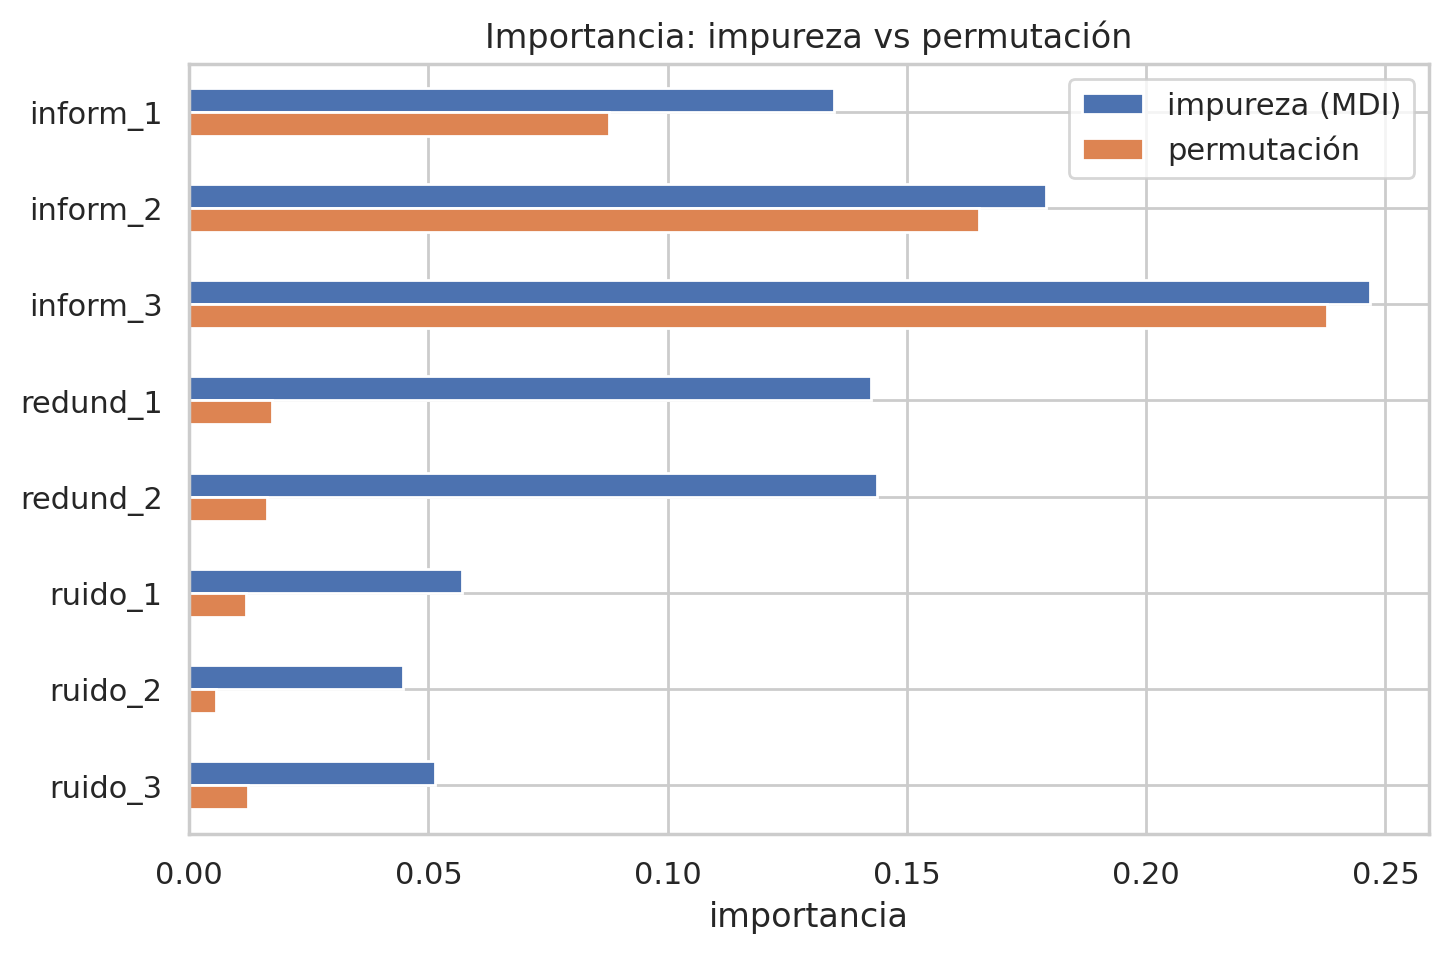

,impureza (MDI),permutación
inform_1,0.135,0.088
inform_2,0.179,0.165
inform_3,0.247,0.238
redund_1,0.142,0.017
redund_2,0.144,0.016
ruido_1,0.057,0.012
ruido_2,0.045,0.006
ruido_3,0.051,0.012


In [4]:
Xi, yi = make_classification(n_samples=800, n_features=8, n_informative=3, n_redundant=2,
                             n_repeated=0, shuffle=False, random_state=0)
cols = ['inform_1', 'inform_2', 'inform_3', 'redund_1', 'redund_2', 'ruido_1', 'ruido_2', 'ruido_3']
Xi = pd.DataFrame(Xi, columns=cols)
rf_i = RandomForestClassifier(n_estimators=300, random_state=RNG).fit(Xi, yi)
perm = permutation_importance(rf_i, Xi, yi, n_repeats=15, random_state=0)
comp = pd.DataFrame({'impureza (MDI)': rf_i.feature_importances_,
                     'permutación': perm.importances_mean}, index=cols)
comp.plot.barh(figsize=(8, 5)); plt.gca().invert_yaxis()
plt.title('Importancia: impureza vs permutación'); plt.xlabel('importancia'); plt.show()
comp.round(3)

Las variables de **ruido** reciben importancia **≈ 0** en ambas medidas: el bosque las ignora. Las **informativas** y **redundantes** concentran la importancia, pero al estar **correlacionadas entre sí** su peso se **reparte** (ninguna destaca tanto como debería): es justo el efecto de las correlaciones del que advertíamos. Ambas medidas coinciden en lo esencial, aunque sus escalas son distintas (MDI suma 1; la permutación se expresa como caída de la métrica).

# <font color="steelblue">6. Hiperparámetros y *out-of-bag*</font>

## <font color="steelblue">6.1. Impacto de los hiperparámetros</font>

Aunque el bosque aleatorio destaca por funcionar razonablemente bien con su configuración por defecto, comprender el papel de sus principales hiperparámetros resulta imprescindible para ajustarlo con criterio. Conviene, además, distinguir desde el principio dos grupos de naturaleza muy distinta: los que gobiernan **cuántos** árboles componen el bosque y los que regulan **cómo de complejo** es cada árbol individual.

El número de árboles se controla con **`n_estimators`**. Aumentarlo **estabiliza** la predicción, pues promediar más árboles reduce la varianza del conjunto, y —a diferencia de lo que ocurre en otros modelos— **no provoca sobreajuste**: a partir de cierto punto el error simplemente se **aplana** y añadir más árboles solo incrementa el tiempo de cómputo y la memoria, sin deteriorar el rendimiento. Por tanto, no es un parámetro que haya que «afinar» en sentido estricto, sino fijarlo en un valor lo bastante alto para que el error se estabilice.

El segundo grupo de hiperparámetros determina la **estructura de cada árbol** y, con ella, el equilibrio entre sesgo y varianza del bosque. El más característico es **`max_features`**, que fija el número $m$ de variables candidatas en cada división y regula así la **decorrelación** entre árboles: valores **pequeños** producen árboles más diversos —y, por tanto, un conjunto con menos varianza—, aunque cada árbol resulte individualmente algo peor; el valor por defecto en clasificación es `'sqrt'`. A su vez, **`max_depth`**, **`min_samples_leaf`** y **`min_samples_split`** **regularizan el tamaño** de los árboles: cuando se les permite crecer sin restricciones, los árboles muy profundos tienden a **memorizar** el conjunto de entrenamiento (sobreajuste), de modo que limitar la profundidad o exigir un número mínimo de observaciones por hoja **reduce la varianza** y, en consecuencia, el desfase entre el rendimiento en entrenamiento y en test. Con un papel más secundario, **`criterion`** selecciona la medida de impureza (`'gini'` o `'entropy'`) y, en la práctica, apenas altera los resultados; por su parte, **`class_weight='balanced'`** pondera las clases en función de su frecuencia y resulta de utilidad en problemas **desequilibrados**.

Esta distinción tiene una consecuencia práctica que conviene retener. Mientras que `n_estimators` no interviene en el compromiso sesgo–varianza —solo hay que garantizar que sea suficientemente grande—, los hiperparámetros que **controlan el tamaño del árbol** (`max_depth`, `min_samples_leaf`, `max_features`) **sí** lo hacen, y serán, por ello, los que **optimicemos** más adelante para combatir el sobreajuste.

## <font color="steelblue">6.2. El error *out-of-bag* (OOB)</font>

Una de las propiedades más elegantes del bagging es que permite estimar el error de generalización **sin necesidad de reservar datos** ni de recurrir a la validación cruzada. La clave está en un subproducto natural del remuestreo *bootstrap*: como ya se señaló, cada árbol se entrena con una muestra que deja fuera, en promedio, alrededor de un tercio de las observaciones. Esas observaciones no utilizadas por un árbol concreto se denominan sus datos ***out-of-bag*** (OOB) y constituyen, para ese árbol, un pequeño conjunto de prueba independiente.

El **error OOB** aprovecha esta circunstancia de forma sistemática. Para cada observación de la muestra se recupera su predicción empleando **únicamente los árboles que no la vieron durante su entrenamiento** y se compara con su valor real; al promediar estas comparaciones sobre todas las observaciones se obtiene una **estimación del error de generalización prácticamente gratuita**, ya que reutiliza el trabajo realizado al construir el bosque. En scikit-learn basta con activar la opción `oob_score=True`. Este mecanismo, propio de los métodos de *bagging*, proporciona una alternativa cómoda y fiable a la validación cruzada, especialmente valiosa cuando el coste computacional de esta última es elevado.

## <font color="steelblue">6.3. Ejemplo ilustrativo: profundidad, OOB y sobreajuste</font>

Para observar en la práctica el papel regularizador de la estructura del árbol y la utilidad del error OOB como herramienta de diagnóstico, en el siguiente experimento hacemos variar el hiperparámetro `max_depth` y comparamos, para cada valor, la exactitud sobre el conjunto de **entrenamiento** con la estimación **OOB**. El comportamiento esperado ilustra con nitidez el fenómeno del sobreajuste: a medida que se permite mayor profundidad, la exactitud en entrenamiento tiende a **1**, señal de que el bosque acaba **memorizando** los datos, mientras que la estimación OOB se **estabiliza** en un valor sensiblemente inferior. La **brecha** que se abre entre ambas curvas es, precisamente, la magnitud del sobreajuste, y el hecho de que el OOB nos permita detectarlo sin datos adicionales pone de manifiesto su valor como instrumento de control.

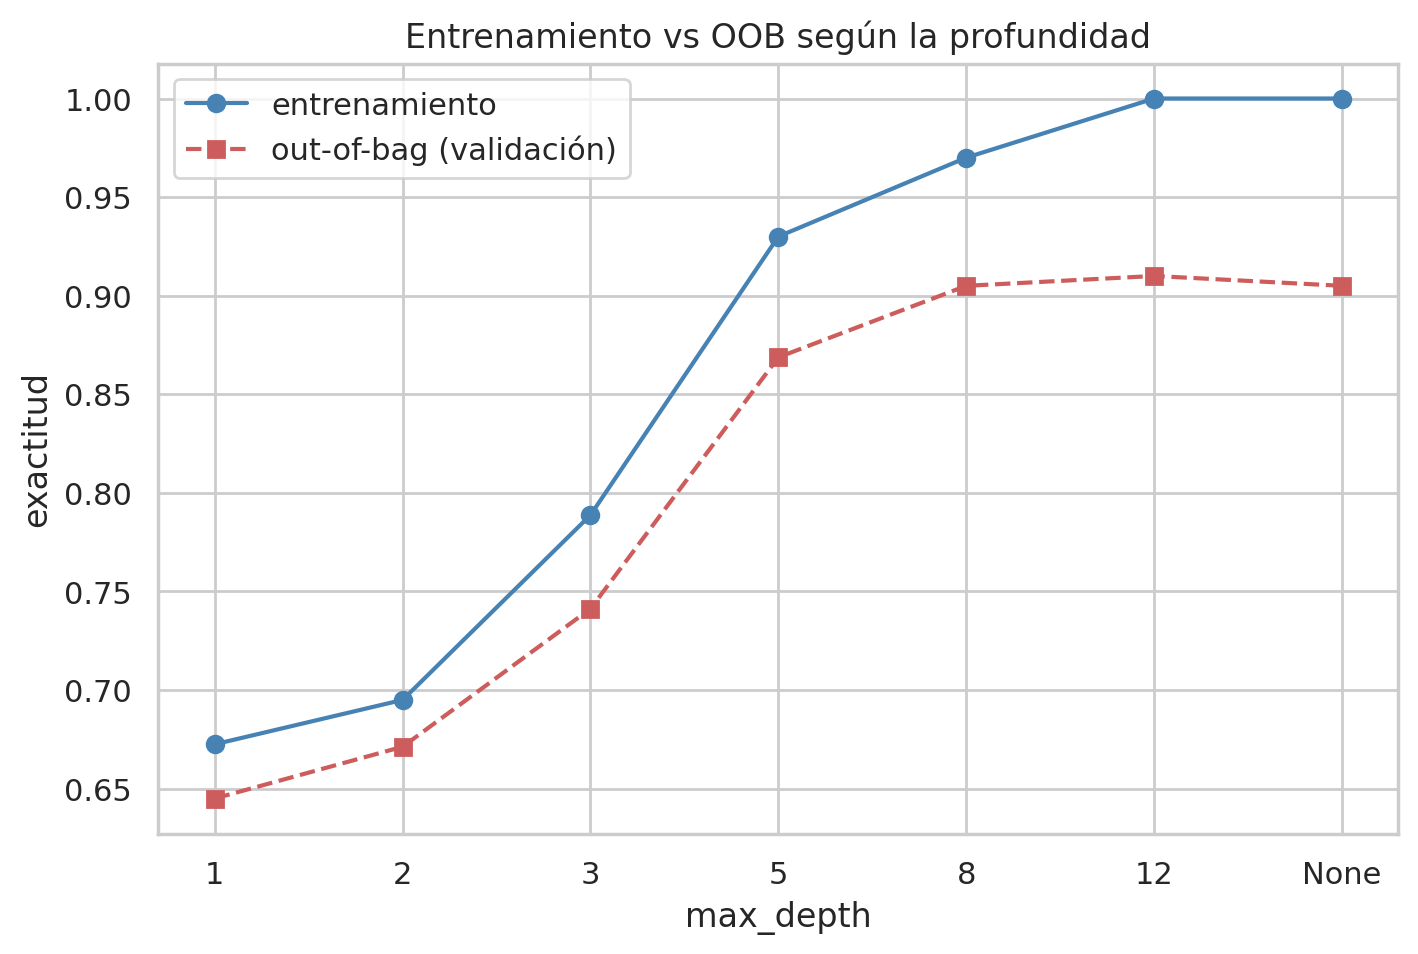

In [5]:
profundidades = [1, 2, 3, 5, 8, 12, None]
tr_sc, oob_sc = [], []
for d in profundidades:
    m = RandomForestClassifier(n_estimators=300, max_depth=d, oob_score=True,
                               n_jobs=-1, random_state=RNG).fit(Xi, yi)
    tr_sc.append(m.score(Xi, yi)); oob_sc.append(m.oob_score_)
etiquetas = [str(d) for d in profundidades]
plt.figure(figsize=(8, 5))
plt.plot(etiquetas, tr_sc, 'o-', color='steelblue', label='entrenamiento')
plt.plot(etiquetas, oob_sc, 's--', color='indianred', label='out-of-bag (validación)')
plt.xlabel('max_depth'); plt.ylabel('exactitud'); plt.title('Entrenamiento vs OOB según la profundidad')
plt.legend(); plt.show()

Al aumentar la profundidad, la exactitud en **entrenamiento sube hasta casi 1** (el bosque acaba memorizando los datos), pero el **OOB se estanca**: la diferencia entre ambas curvas es la **medida del sobreajuste**. El punto de interés es donde el OOB **deja de mejorar**; profundizar más solo agranda la brecha sin ganar generalización. Este diagnóstico —comparar entrenamiento con una estimación honesta (OOB o test)— lo aplicaremos en todos los ejemplos reales.



# <font color="steelblue">7. Codificación de categóricas y preprocesado</font>

Los árboles pueden, en teoría, usar variables **categóricas** directamente, pero **scikit-learn exige codificarlas** con *one-hot encoding* (variables *dummy*). Esto aumenta la dimensionalidad y **diluye la importancia** de la categórica entre sus *dummies*. Otras implementaciones (p. ej. `H2O`) admiten categóricas nativas.

> **Preprocesado correcto para árboles (importante para no confundirse).** A diferencia de los modelos lineales, de distancias (k-NN) o de márgenes (SVM), **los modelos basados en árboles NO necesitan estandarización ni normalización**: un árbol decide con **umbrales** sobre cada variable por separado, y cualquier transformación **monótona** de una variable (como restar la media y dividir por la desviación) **no altera el orden** de los valores ni, por tanto, los cortes posibles. Por eso, en los ejemplos reales **no aplicaremos `preprocesar_datos`** (que estandariza): el único preprocesado **imprescindible** para árboles es **imputar los valores ausentes**, **codificar las categóricas** (*one-hot*) y **eliminar identificadores** que no son predictores. Mantener las variables en su **escala original** tiene además la ventaja de hacer **más legibles** las gráficas de importancia y de SHAP. *(Si en algún ejemplo aparecieran categóricas, sí habría que codificarlas; en los datasets de este cuaderno todas las predictoras son numéricas.)*

# <font color="steelblue">8. Explicabilidad (XAI) y valores de Shapley</font>

## <font color="steelblue">8.1. ¿Qué es la explicabilidad (XAI)?</font>

La **inteligencia artificial explicable** (*eXplainable AI*, XAI) reúne el conjunto de técnicas que permiten entender **por qué** un modelo produce una determinada predicción. Su relevancia ha crecido a la par que la de los modelos más potentes del aprendizaje automático, pues estos suelen alcanzar su elevada precisión a costa de volverse **opacos**: un bosque aleatorio formado por cientos de árboles, por ejemplo, resulta imposible de inspeccionar «a mano», de modo que, aunque predice muy bien, no revela de manera evidente el razonamiento que hay detrás de cada decisión. A esta clase de modelos se les denomina **cajas negras**, y es precisamente sobre ellos donde la explicabilidad adquiere todo su sentido.

Conviene, en este punto, distinguir dos conceptos que a menudo se confunden. Un modelo es **interpretable** cuando su funcionamiento es transparente por su propia naturaleza —como un árbol de decisión único o una regresión lineal, cuyos coeficientes o reglas pueden leerse directamente—. La **explicabilidad**, en cambio, se aplica cuando el modelo **no** es transparente y se requiere, por tanto, una herramienta externa que **reconstruya** a posteriori las razones de sus predicciones. La XAI se ocupa de este segundo caso: dotar de justificación comprensible a modelos que, en sí mismos, no la ofrecen.

La necesidad de estas técnicas trasciende la mera curiosidad académica. En numerosos ámbitos —la **medicina**, la concesión de **crédito** o la **justicia**, entre otros—, las decisiones apoyadas en un modelo tienen consecuencias tangibles sobre las personas, lo que exige poder **justificarlas**, detectar posibles **sesgos**, verificar que el modelo se apoya en variables razonables y, en muchos casos, **cumplir con la normativa**, que reconoce cada vez con mayor frecuencia el derecho a obtener una explicación de las decisiones automatizadas. Una predicción correcta pero injustificable resulta, en estos contextos, insuficiente.

Dentro de la XAI es habitual distinguir dos niveles de explicación, según su alcance:

* **Explicación global:** describe qué variables son importantes para el modelo **en su conjunto** —y en qué sentido influyen—, ofreciendo una visión general de su comportamiento sobre la totalidad de los datos.
* **Explicación local:** justifica por qué el modelo ha clasificado de una determinada manera **una observación concreta**, atendiendo a los valores específicos de sus variables.

Ambos niveles son complementarios: el primero ayuda a comprender y validar el modelo en términos generales, mientras que el segundo permite razonar sobre casos individuales, que es lo que suele demandarse cuando una decisión afecta a una persona en particular.

Las medidas de importancia estudiadas en la sección 5 —tanto la basada en la impureza como la de permutación— proporcionan únicamente una visión **global** del modelo. Los **valores de Shapley**, que desarrollamos a continuación, presentan la ventaja decisiva de ofrecer **ambos niveles a la vez**, global y local, sustentados además en una **base teórica sólida** procedente de la teoría de juegos. Su propiedad más valiosa es la **coherencia** entre ambas escalas: la explicación global se obtiene, sin contradicciones, como agregación de las explicaciones locales, de manera que lo que se afirma sobre el modelo en su conjunto es plenamente compatible con lo que se afirma sobre cada observación individual.

## <font color="steelblue">8.2. Valores de Shapley: la idea</font>

Los **valores de Shapley** tienen su origen en la **teoría de juegos cooperativos**, formulados por Lloyd Shapley en 1953 para resolver un problema de reparto. El planteamiento es el siguiente: si varios jugadores cooperan y obtienen conjuntamente un cierto beneficio, ¿de qué manera puede repartirse ese beneficio entre ellos de forma **justa**, es decir, proporcional a la contribución real de cada uno? La respuesta que propone Shapley consiste en asignar a cada jugador la **media de su contribución marginal** considerada sobre **todas las coaliciones posibles**, esto es, promediando cuánto añade ese jugador al resultado a lo largo de todos los órdenes en que los jugadores podrían irse incorporando al grupo. De este modo, la contribución de cada uno se evalúa no en un escenario aislado, sino teniendo en cuenta todas las combinaciones en las que puede colaborar con los demás.

La aportación de Lundberg y Lee (2017) consistió en trasladar esta idea al terreno del aprendizaje automático, dando lugar al método **SHAP** (*SHapley Additive exPlanations*). La analogía es directa: los **jugadores** pasan a ser las **variables** del modelo, el **beneficio** que se reparte es la **predicción** correspondiente a una observación concreta, y el valor de Shapley $\phi_j$ de cada variable mide **cuánto empuja** dicha variable la predicción, ya sea al alza o a la baja, respecto a un valor de referencia. La explicación de una predicción se convierte, así, en un reparto: cada variable recibe la parte de la predicción que le corresponde según su contribución.

Lo que confiere a este enfoque su solidez es que la solución de Shapley es la **única** que satisface simultáneamente un conjunto de propiedades muy deseables. La primera y más importante es la **eficiencia** o **aditividad**, según la cual la predicción se descompone exactamente como

$$f(x) = \phi_0 + \sum_{j=1}^{p}\phi_j,$$

donde $\phi_0 = E[f(x)]$ es el **valor base** —la predicción media del modelo, el punto de partida cuando no se conoce ninguna variable— y cada $\phi_j$ representa el **empuje** de la variable $j$ sobre esa predicción. Esta igualdad es de gran valor práctico, pues garantiza que las contribuciones individuales **suman con exactitud** la diferencia entre la predicción concreta y la media, sin residuos inexplicados. A ella se añaden otras tres propiedades: la **simetría**, que asegura que dos variables con idéntica contribución reciben el mismo valor; la propiedad ***dummy***, según la cual una variable que no influye en la predicción recibe un valor nulo; y la **aditividad** entre modelos, que permite combinar de forma coherente las explicaciones de modelos agregados, como los propios *ensembles* de árboles.

El principal inconveniente de este planteamiento es su **coste computacional**: calcular los valores de Shapley exactos exige recorrer **todas las coaliciones** de variables, cuyo número crece de forma exponencial y hace inviable el cálculo directo salvo en problemas muy pequeños. Afortunadamente, para los **modelos basados en árboles** existe un algoritmo específico, **TreeSHAP**, capaz de obtener los valores **exactos** de manera **eficiente** al aprovechar la estructura del árbol. Es, precisamente, el procedimiento que emplearemos para explicar las predicciones de nuestro bosque aleatorio.

## <font color="steelblue">8.3. La librería `shap`: salidas numéricas</font>

La librería `shap` implementa el método SHAP y proporciona tanto los valores numéricos como las representaciones gráficas que estudiaremos más adelante. Antes de abordar la parte visual, conviene detenerse en los resultados numéricos, pues son la base sobre la que se construye todo lo demás.

El flujo de trabajo, para un modelo basado en árboles, consta de dos pasos. En primer lugar se crea un **explicador** específico para árboles —que internamente emplea el algoritmo TreeSHAP, exacto y eficiente— y, a continuación, se aplica a las observaciones que se desea explicar:

```python
import shap
explainer = shap.TreeExplainer(modelo)      # TreeSHAP: exacto y rápido para árboles
explicacion = explainer(X)                   # devuelve un objeto Explanation
```

El resultado de esta llamada es un objeto de tipo **`Explanation`**, que actúa como contenedor de todos los resultados numéricos y sobre el que operan después las funciones gráficas. Tres de sus componentes concentran la información esencial:
* El primero, **`.values`**, almacena los propios valores SHAP $\phi_{ij}$, uno por cada observación $i$ y cada variable $j$. En los problemas de **clasificación**, este componente tiene forma `(n_observaciones, n_variables, n_clases)`, ya que existe un «bloque» de valores por cada clase; en un problema **binario** se selecciona la clase de interés mediante `explicacion[:, :, 1]` (la clase positiva), mientras que en los problemas **multiclase** se analiza cada clase por separado con `explicacion[:, :, k]`.
* El segundo componente, **`.base_values`**, recoge el **valor base** $\phi_0$ de cada clase, que no es otra cosa que la **predicción media** del modelo —su punto de partida cuando aún no se conoce el valor de ninguna variable— y que, en clasificación, se corresponde con la **probabilidad media** predicha para esa clase.
* Por último, **`.data`** conserva los **valores reales** de las variables de cada observación, que se emplean para etiquetar y colorear las representaciones gráficas.

A partir de estos elementos, los valores SHAP admiten dos lecturas fundamentales, una de alcance local y otra global, que conviene comprender con claridad.

La primera es la **propiedad de aditividad**, que opera a **nivel local**, esto es, sobre cada observación individual. Para cualquier observación se verifica, de forma **exacta**, la igualdad

$$\underbrace{\text{predicción}(x)}_{\text{p. ej. } P(\text{maligno})} \;=\; \underbrace{\phi_0}_{\text{valor base}} \;+\; \sum_{j=1}^{p}\phi_{j}.$$

Su interpretación es muy intuitiva: partiendo de la predicción media del modelo ($\phi_0$), **cada variable suma o resta** una cantidad $\phi_j$ hasta alcanzar la predicción concreta de esa observación. El **signo** de $\phi_j$ indica la **dirección** del efecto —un valor positivo empuja la predicción hacia la clase considerada y uno negativo, en sentido contrario— y su **magnitud** refleja la **intensidad** de ese empuje. De este modo, la aditividad permite descomponer cualquier predicción individual en las aportaciones exactas de cada variable, sin dejar ninguna parte sin explicar.

La segunda lectura proporciona una medida de **importancia global**. Para resumir la influencia de una variable sobre el conjunto de los datos se promedia el **valor absoluto** de sus valores SHAP a lo largo de todas las observaciones:

$$\text{Imp}(j) = \frac{1}{n}\sum_{i=1}^{n} \lvert \phi_{ij}\rvert.$$

Esta cantidad mide **cuánto mueve** cada variable la predicción en promedio, con independencia de la dirección en que lo haga. Se trata, además, de la medida de importancia **más coherente** de las estudiadas, pues reparte de forma **equitativa** la relevancia entre variables correlacionadas —a diferencia de la importancia por permutación, que tiende a infravalorarlas— y puede calcularse sobre el conjunto de datos que resulte de interés, habitualmente el de test. Obsérvese la elegancia de este planteamiento: la explicación **global** no es sino la agregación de las explicaciones **locales**, lo que garantiza la coherencia entre ambos niveles que ya se anticipó al presentar los valores de Shapley.

Conviene cerrar con dos precisiones de carácter técnico. Por un lado, `TreeExplainer` explica por defecto la **salida de probabilidad** del bosque, razón por la cual el valor base es una probabilidad media y la relación de aditividad reconstruye exactamente la salida de `predict_proba`. Por otro, todos los valores numéricos quedan disponibles como *array* a través de `explicacion.values`, lo que posibilita realizar cálculos a medida —rankings, medias por grupos u otros análisis— más allá de las representaciones gráficas que veremos a continuación.

## <font color="steelblue">8.4. La librería `shap`: herramientas gráficas</font>

Las dos lecturas numéricas descritas en el apartado anterior —la importancia global y la descomposición aditiva de cada predicción— resultan difíciles de aprovechar directamente sobre las tablas de valores. Por ello, la librería `shap` las traduce en un conjunto de representaciones gráficas que hacen visibles esos resultados. A continuación se describen las cuatro que emplearemos, prestando especial atención no solo a lo que muestra cada una, sino a **cómo debe interpretarse**:

* El **gráfico de barras** (`shap.plots.bar`) ofrece la visión **global** más elemental. Representa la importancia de cada variable calculada como el valor SHAP medio absoluto, $\frac{1}{n}\sum_i|\phi_{ij}|$, y ordena las variables de mayor a menor. Su lectura es inmediata: cuanto **más larga** es la barra, más mueve esa variable la predicción del modelo, en promedio y con independencia de la dirección. Puede entenderse como el equivalente «honesto» a la importancia por permutación, con la ventaja de que **no penaliza a las variables correlacionadas**, gracias al reparto equitativo que garantizan los valores de Shapley.

* El **gráfico de enjambre** (`shap.plots.beeswarm`) enriquece la visión global al incorporar la **dirección** del efecto. Para cada variable dibuja **un punto por observación**, lo que permite examinar simultáneamente tres dimensiones de información. El **eje horizontal** representa el valor SHAP: los puntos situados a la derecha corresponden a un empuje hacia la clase positiva y los de la izquierda, en sentido contrario. El **color** codifica el valor que toma la variable en cada observación —rojo para los valores altos y azul para los bajos—, mientras que la **acumulación** de puntos en una zona indica cuántas observaciones comparten un empuje similar. Gracias a esta combinación, el gráfico revela de un solo vistazo qué variables importan, en qué medida y en qué sentido: si, por ejemplo, los puntos rojos (valores altos) se concentran a la derecha, cabe concluir que **los valores altos de esa variable empujan la predicción hacia la clase positiva**. Por el contrario, cuando los colores no se separan con nitidez entre la izquierda y la derecha, el efecto de la variable es débil o depende fuertemente de otras.

* El **gráfico de cascada** (`shap.plots.waterfall`) cambia de escala y pasa al terreno **local**, ya que explica **una única predicción concreta**. Su construcción es la traducción visual directa de la propiedad de aditividad: parte, en la base, del **valor base** $E[f(x)]$ —la predicción media del modelo— y va **apilando** sucesivamente el empuje de cada variable, representado mediante barras rojas cuando favorecen la clase positiva y azules cuando la penalizan, ordenadas por magnitud, hasta alcanzar en la parte superior la predicción final $f(x)$ de esa observación. De este modo, el gráfico justifica **variable a variable** por qué el modelo tomó la decisión que tomó en ese caso particular. En las aplicaciones lo emplearemos sobre **varias observaciones distintas**, con el fin de comparar cómo varían las explicaciones de unos casos a otros.

* Por último, el **gráfico de dependencia o dispersión** (`shap.plots.scatter`) es el más rico para comprender **de qué forma** influye una variable concreta. En él, el **eje horizontal** recoge el valor real que toma la variable y el **eje vertical**, su valor SHAP en cada observación, de manera que muestra **cómo cambia el empuje de la variable a medida que cambia su valor**. Esto permite descubrir la **forma** del efecto —creciente, decreciente, no lineal o con un **umbral** a partir del cual el empuje se dispara—, un matiz que una única cifra de importancia es incapaz de reflejar. Además, si se **colorea según otra variable** mediante el argumento `color=...`, la aparición de patrones de color delata la existencia de **interacciones**, es decir, situaciones en las que el efecto de una variable depende del valor de otra; de forma análoga, una marcada **dispersión vertical** de los puntos para un mismo valor del eje horizontal también apunta a interacciones con el resto de variables.

Conviene añadir una precisión para los problemas **multiclase**: todos estos gráficos se aplican **por clase**, seleccionando el bloque correspondiente con `explicacion[:, :, k]`; si se desea una visión global única, puede promediarse $|\phi|$ sobre las distintas clases. En las aplicaciones que siguen generaremos e interpretaremos estas cuatro salidas sobre datos reales.

# <font color="steelblue">9. Aplicaciones</font>

Aplicamos el bosque aleatorio a cinco problemas de clasificación. Recordemos (sección 7) que **los árboles no requieren estandarización**: cargaremos los datos **sin limpiar** y haremos solo el preprocesado imprescindible (imputar ausentes, eliminar identificadores), manteniendo las variables en su escala original.

Definimos tres **utilidades** que reutilizaremos: comparar Random Forest con Extra Trees (mostrando el desfase **entrenamiento-test**, que mide el **sobreajuste**), optimizar los hiperparámetros por **OOB**, y mostrar el *waterfall* de **varias observaciones** indicando claramente cuál es cada una.

In [6]:
def comparar_rf_extra(Xtr, ytr, Xte, yte):
    # Entrena RF y Extra Trees (por defecto) y compara F1 en train y test; el desfase mide sobreajuste
    filas, modelos = [], {}
    for nombre, mod in [('Random Forest', RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1)),
                        ('Extra Trees',   ExtraTreesClassifier(n_estimators=300, random_state=RNG, n_jobs=-1))]:
        mod.fit(Xtr, ytr); modelos[nombre] = mod
        f1tr = f1_score(ytr, mod.predict(Xtr), average='weighted')
        f1te = f1_score(yte, mod.predict(Xte), average='weighted')
        filas.append({'modelo': nombre, 'F1 train': round(f1tr, 3), 'F1 test': round(f1te, 3),
                      'desfase (train-test)': round(f1tr - f1te, 3)})
    return pd.DataFrame(filas).set_index('modelo'), modelos

def optimizar_oob(Xtr, ytr, malla):
    # Grid search sobre el OOB score; devuelve (modelo_optimo_reentrenado, mejores_params, mejor_oob)
    resultados = []
    for p in ParameterGrid(malla):
        m = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=RNG, **p).fit(Xtr, ytr)
        resultados.append((m.oob_score_, p))
    mejor_oob, mejores = max(resultados, key=lambda t: t[0])
    return RandomForestClassifier(n_jobs=-1, random_state=RNG, **mejores).fit(Xtr, ytr), mejores, mejor_oob

def waterfalls_muestras(expl_clase, proba, y_reset, n=4):
    # Muestra el waterfall de n observaciones que cubren el rango de probabilidad,
    # indicando para cada una su fila, su clase real y la probabilidad predicha de la clase analizada
    indices = [int(np.argmin(np.abs(proba - objetivo))) for objetivo in np.linspace(proba.min(), proba.max(), n)]
    for k, i in enumerate(indices):
        print(f'>>> Muestra {k+1}: fila {i}  |  clase real = {y_reset.iloc[i]}  |  '
              f'probabilidad predicha de la clase analizada = {proba[i]:.2f}')
        shap.plots.waterfall(expl_clase[i])

## <font color="steelblue">9.1. Ejemplo 1: datos simulados</font>

Cuatro grupos en 2D que **no están perfectamente separados**. Al haber solo dos variables, podemos **visualizar las regiones de decisión** del bosque y comprobar el *out-of-bag*.

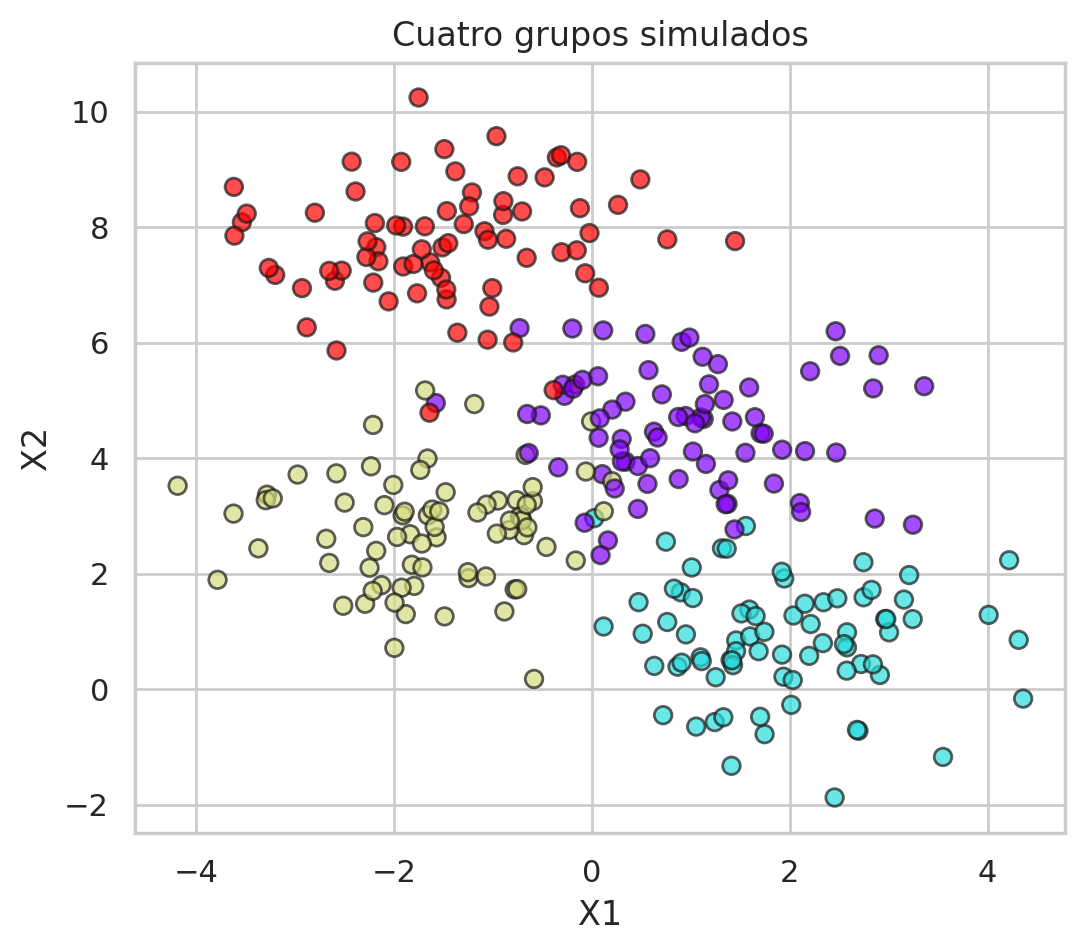

In [7]:
# Gráfico descriptivo
X1, y1 = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)
plt.figure(figsize=(6, 5))
plt.scatter(X1[:, 0], X1[:, 1], c=y1, s=40, cmap='rainbow', edgecolor='k', alpha=.7)
plt.title('Cuatro grupos simulados'); plt.xlabel('X1'); plt.ylabel('X2'); plt.show()

Exactitud out-of-bag: 0.919


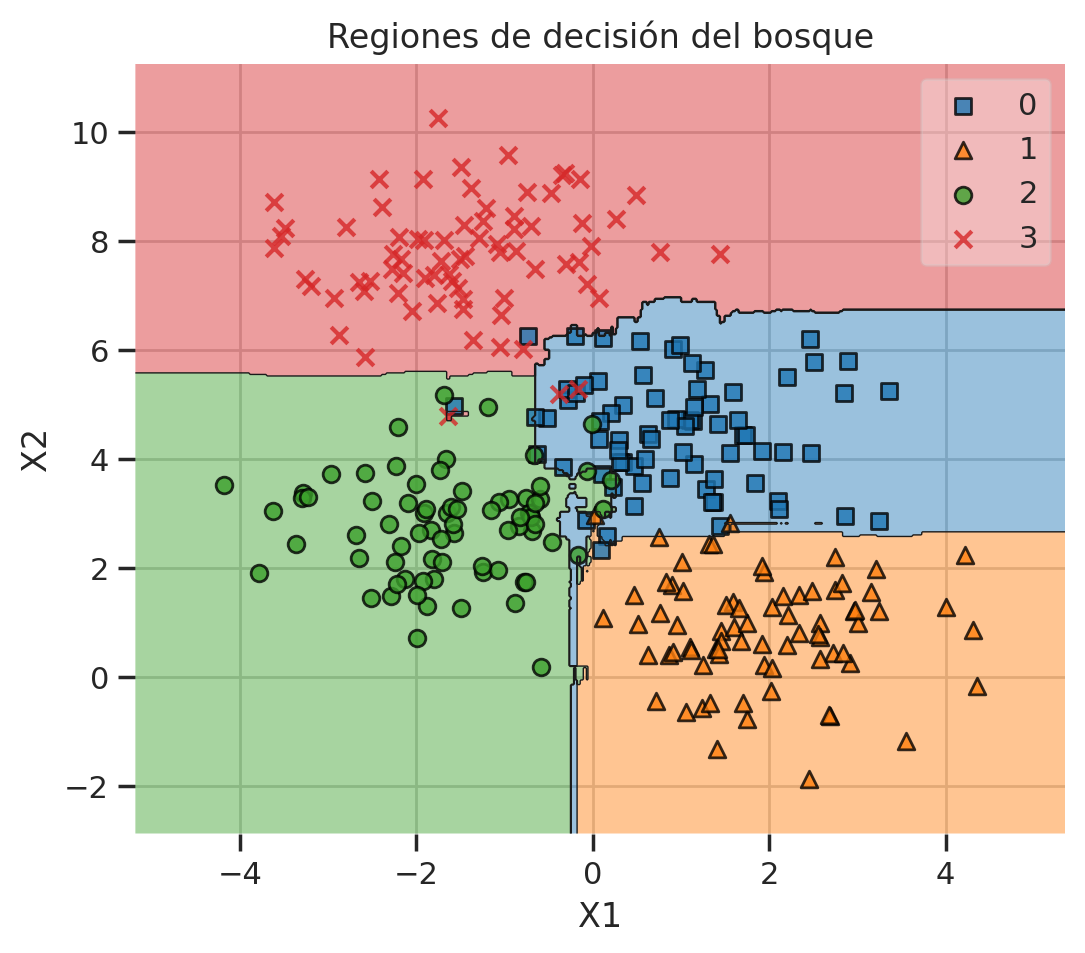

In [8]:
# Regiones de decisión
X1tr, X1te, y1tr, y1te = train_test_split(X1, y1, test_size=0.3, random_state=42)
rf1 = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=RNG).fit(X1tr, y1tr)
print(f'Exactitud out-of-bag: {rf1.oob_score_:.3f}')
plt.figure(figsize=(6, 5)); plot_decision_regions(X=X1, y=y1, clf=rf1)
plt.title('Regiones de decisión del bosque'); plt.xlabel('X1'); plt.ylabel('X2'); plt.show()

Veamos los resulatdos de la clasificación:

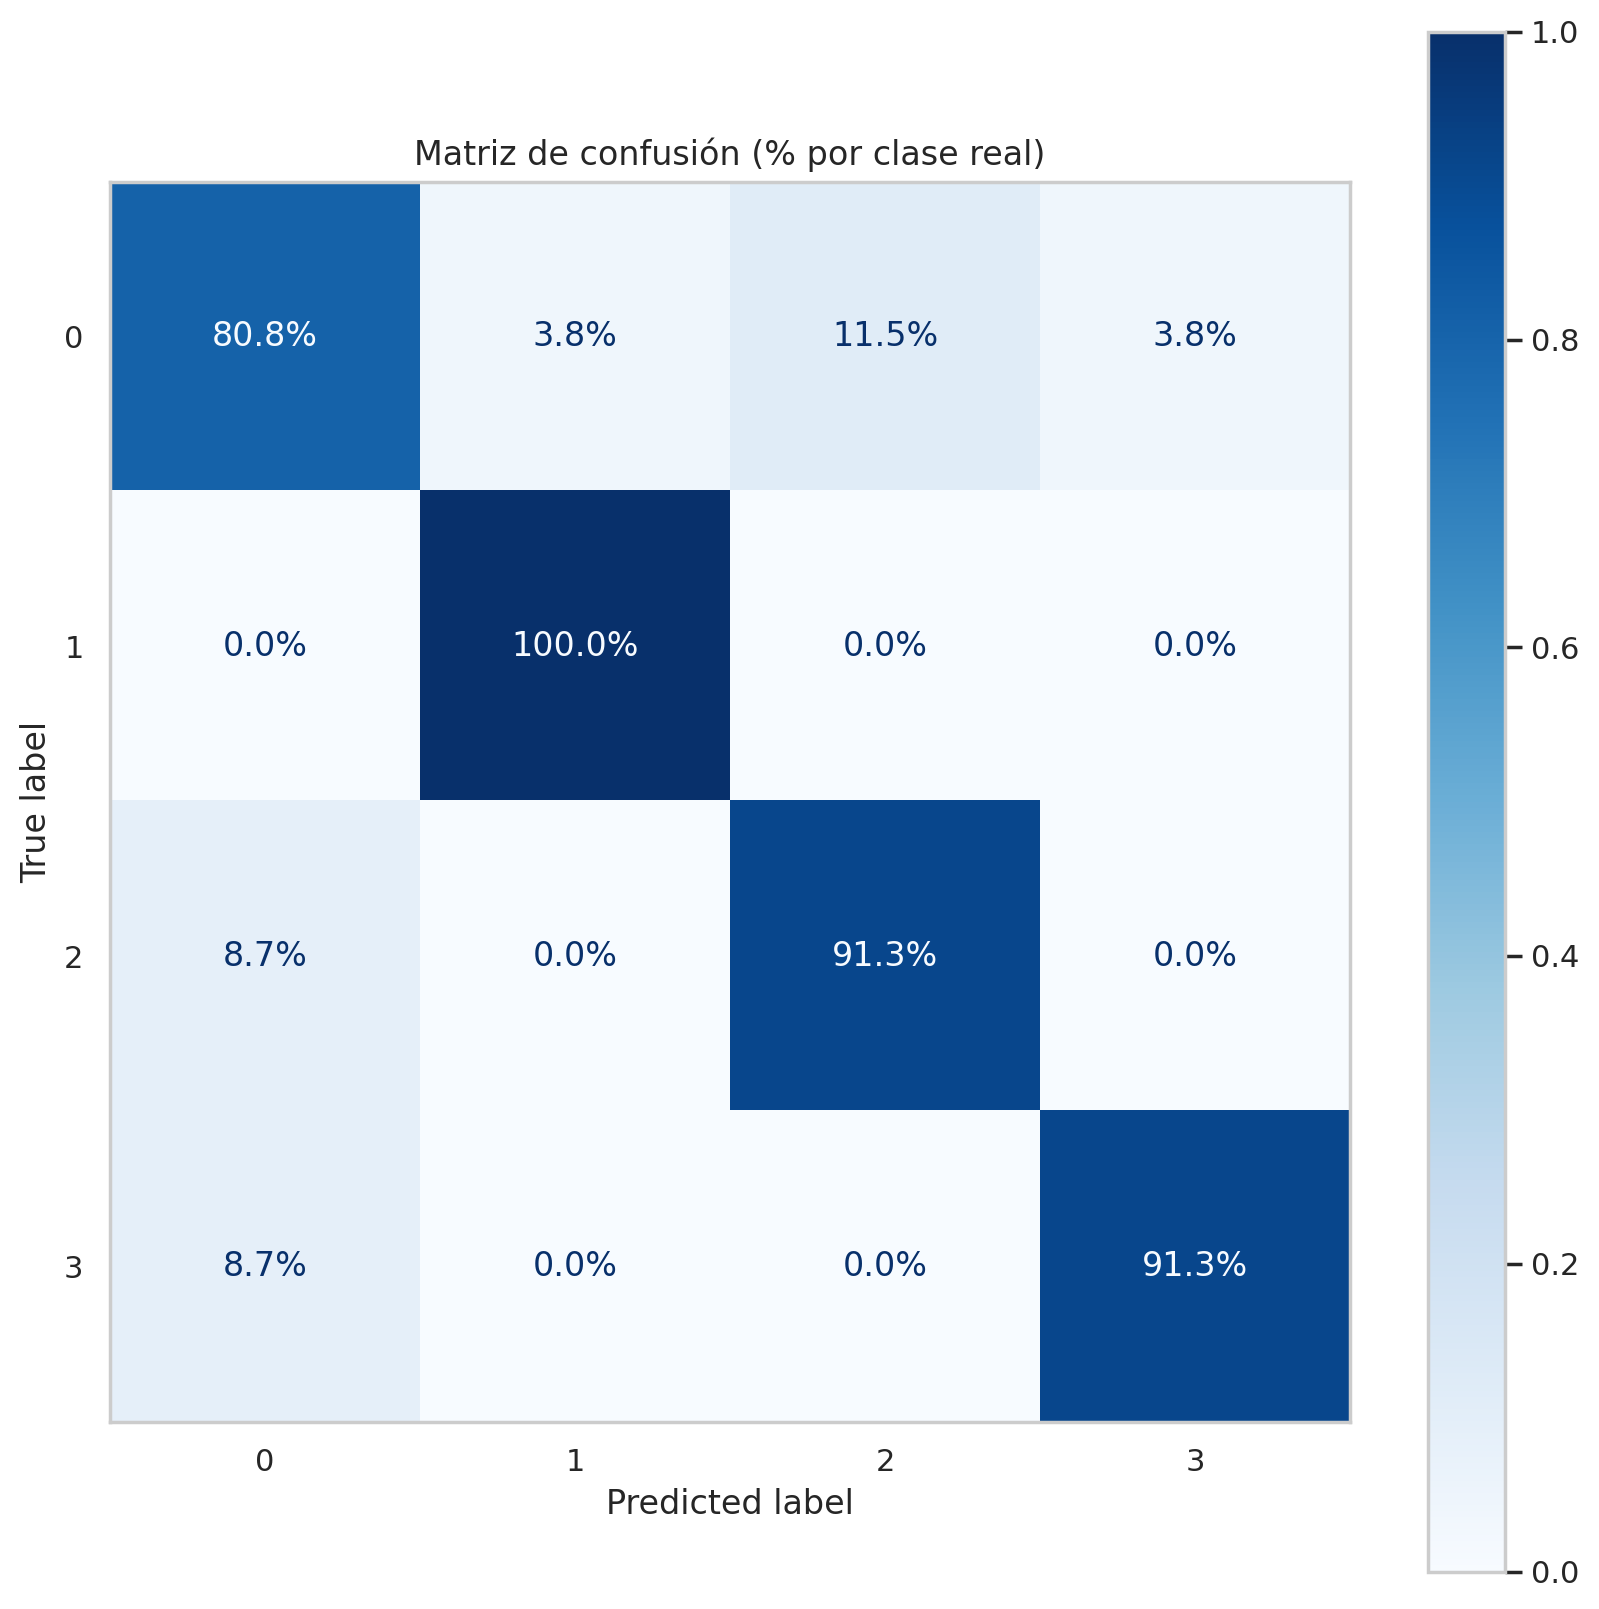

In [9]:
matriz_confusion(rf1, X1te, y1te);

In [10]:
reports_clas(rf1, X1tr, y1tr, X1te, y1te)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        52
           3       1.00      1.00      1.00        52

    accuracy                           1.00       210
   macro avg       1.00      1.00      1.00       210
weighted avg       1.00      1.00      1.00       210


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.84      0.81      0.82        26
           1       0.95      1.00      0.97        18
           2       0.88      0.91      0.89        23
           3       0.95      0.91      0.93        23

    accuracy                           0.90        90
   macro avg       0.90      0.91      0.91        90
weighted avg       0.90      0.90      0.90        90



Las fronteras se adaptan a la forma de los grupos (escalonadas, típicas de árboles). El OOB ya anticipa un buen rendimiento (~0.9) **sin** validación cruzada, confirmado en la matriz y el informe: los pocos errores se concentran en la zona donde los grupos se solapan.

## <font color="steelblue">9.2. Ejemplo 2: dígitos manuscritos</font>

Diez clases (dígitos 0–9), descritas por **64 píxeles** (intensidades 0–16). Datos numéricos y completos: **no requieren limpieza ni escalado** (los árboles son invariantes a la escala, sección 7).

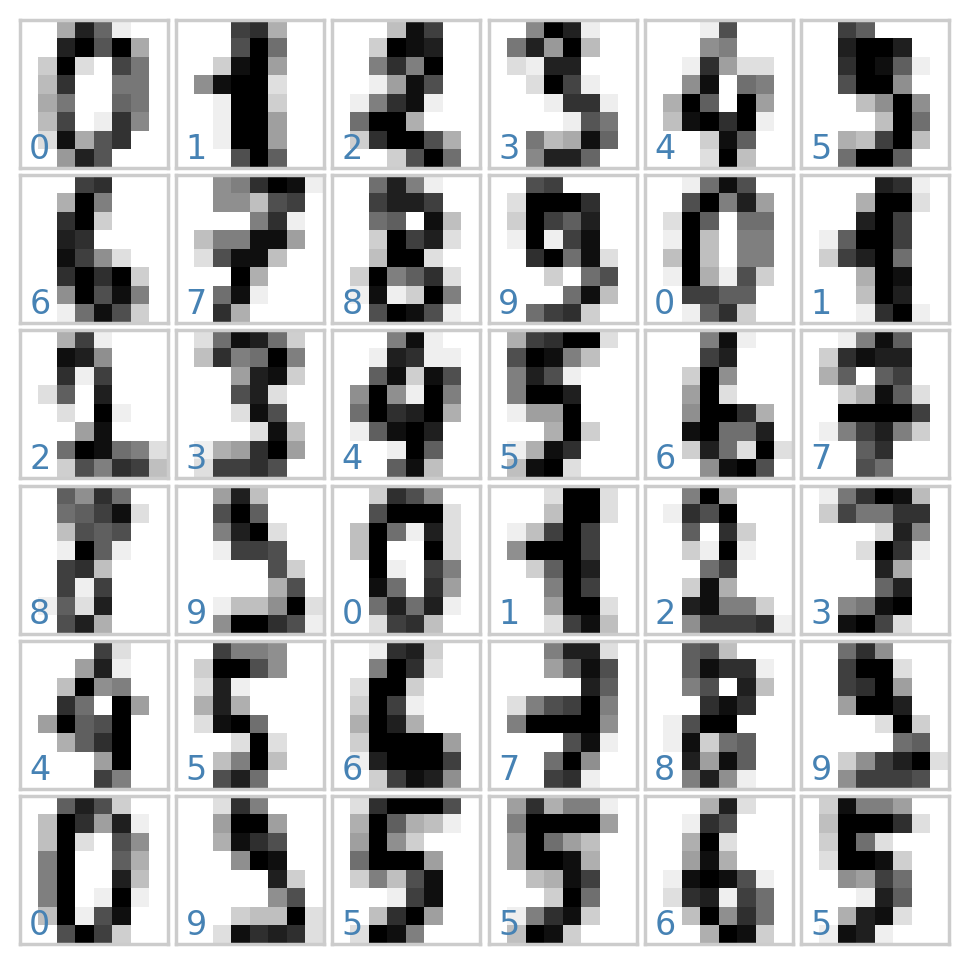

In [11]:
digits = load_digits()
X_dig = pd.DataFrame(digits.data, columns=[f'px_{i}' for i in range(64)])
y_dig = pd.Categorical(digits.target)
fig = plt.figure(figsize=(6, 6)); fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i in range(36):
    ax = fig.add_subplot(6, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
    ax.text(0, 7, str(digits.target[i]), color='steelblue')
plt.show()

### Random Forest vs Extra Trees

Sobre este banco de datos comparamos el modelo de random forest y extra trees:

In [12]:
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(X_dig, y_dig, test_size=0.3, random_state=42)
tabla_d, modelos_d = comparar_rf_extra(Xtr_d, ytr_d, Xte_d, yte_d)
tabla_d

,F1 train,F1 test,desfase (train-test)
modelo,,,
Random Forest,1.0,0.974,0.026
Extra Trees,1.0,0.981,0.019


Ambos modelos alcanzan un valor aproximado de 0.97 en test. El **desfase train-test es pequeño**: aunque el train es casi perfecto, el test también es muy alto, señal de **buena generalización** (poco sobreajuste). Seguimos con el Random Forest.

### Evaluación e importancia por píxel

Evaluamos la matriz de confusión y rerepesntamso la importancia de cada pixel (input de entrada) en la reconstrucción de la imagen.

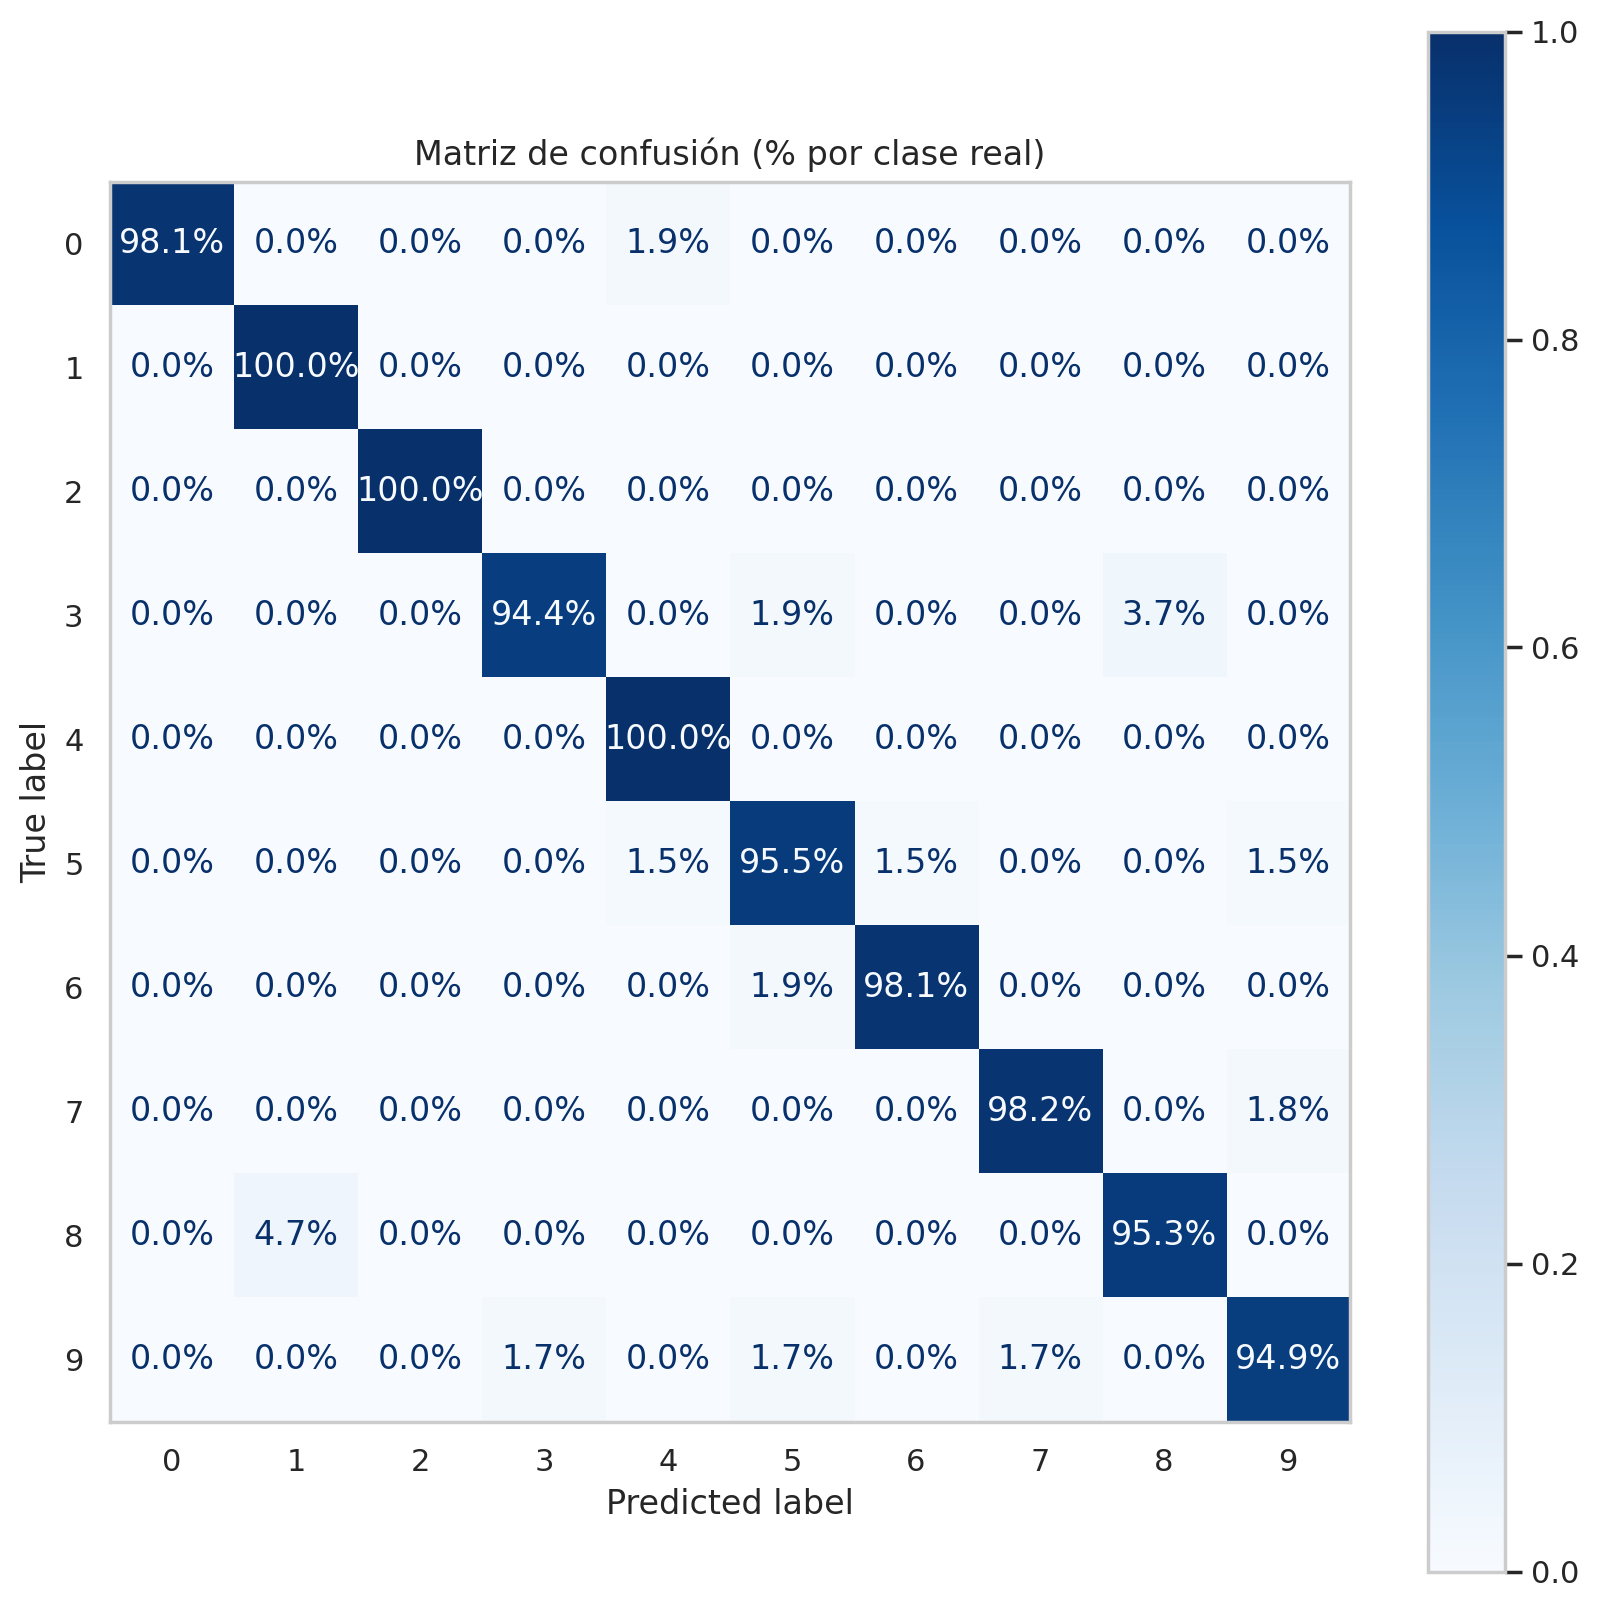

In [13]:
rf_dig = modelos_d['Random Forest']
matriz_confusion(rf_dig, Xte_d, yte_d);

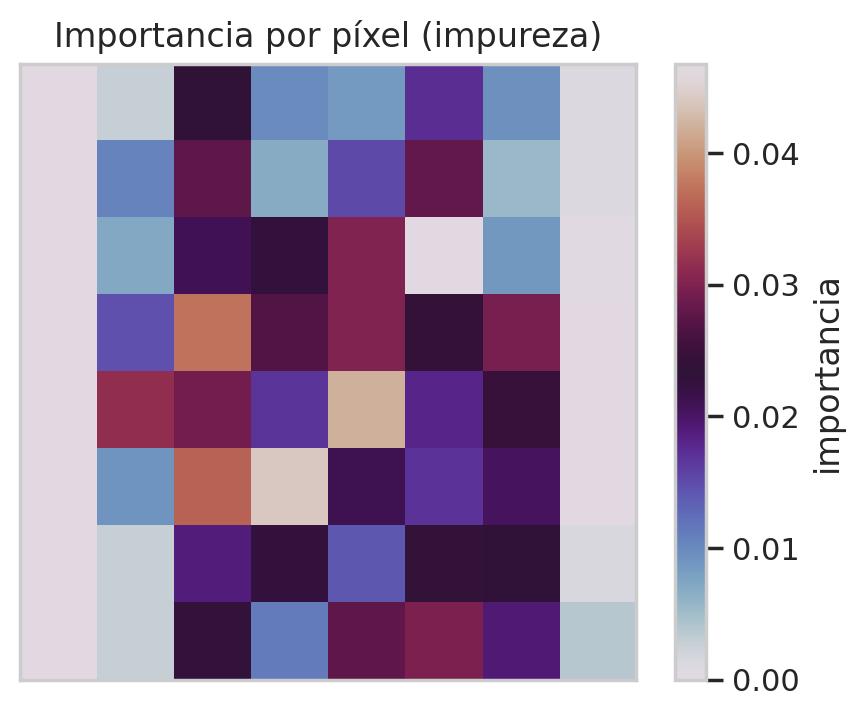

In [14]:
# Importancia de los pixel
plt.figure(figsize=(5, 4))
plt.imshow(rf_dig.feature_importances_.reshape(8, 8), cmap='twilight'); plt.colorbar(label='importancia')
plt.title('Importancia por píxel (impureza)'); plt.xticks([]); plt.yticks([]); plt.show()

Clasificación **excelente** (≈ 0.97); los errores son entre dígitos parecidos. El mapa muestra que el bosque se apoya en los **píxeles centrales** (donde está la tinta) e ignora los **bordes**, casi siempre vacíos. *(Con 64 píxeles y 10 clases el análisis SHAP es poco legible; lo reservamos para los ejemplos con variables interpretables.)*

## <font color="steelblue">9.3. Ejemplo 3: Abulones</font>

Clasificamos el **sexo** del abulón (M/F/I) por medidas físicas. Cargamos el fichero **sin limpiar** `abalone.csv`. **No estandarizamos**: los árboles deciden con umbrales sobre cada variable y son invariantes a la escala (sección 7). No hay ausentes, identificadores ni categóricas que tratar.

In [15]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone.csv'
abalone = pd.read_csv(url); abalone['Sex'] = abalone['Sex'].astype('category')
print('Dimensiones:', abalone.shape)
tr, te = split_sample(abalone, 'Sex', 0.3, 0, True)
Xtr_a, ytr_a = tr.drop(columns='Sex'), tr['Sex']
Xte_a, yte_a = te.drop(columns='Sex'), te['Sex']

Dimensiones: (4177, 9)
Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras


### Random Forest vs Extra Trees y diagnóstico de sobreajuste

In [16]:
tabla_a, modelos_a = comparar_rf_extra(Xtr_a, ytr_a, Xte_a, yte_a)
tabla_a

,F1 train,F1 test,desfase (train-test)
modelo,,,
Random Forest,1.0,0.533,0.467
Extra Trees,1.0,0.532,0.468


Ambos modelos **memorizan** el entrenamiento (**F1 train ≈ 1.0**) pero se desploman en test (**≈ 0.53**): un **desfase enorme**, síntoma claro de **sobreajuste**. RF y Extra Trees rinden casi idéntico. Veamos si optimizando los hiperparámetros se corrige.

### Optimización de hiperparámetros (grid sobre OOB)

In [17]:
malla = {'n_estimators': [300], 'max_depth': [5, 8, 12, None],
         'min_samples_leaf': [0.20, 0.25, 0.30], 'max_features': ['sqrt']}
rf_a, params_a, oob_a = optimizar_oob(Xtr_a, ytr_a, malla)
print('Mejores hiperparámetros:', params_a, '| OOB =', round(oob_a, 3))
print(f'F1 train = {f1_score(ytr_a, rf_a.predict(Xtr_a), average="weighted"):.3f} | '
      f'F1 test = {f1_score(yte_a, rf_a.predict(Xte_a), average="weighted"):.3f}')

Mejores hiperparámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 0.2, 'n_estimators': 300} | OOB = 0.531
F1 train = 0.440 | F1 test = 0.445


El problema es **intrínsecamente difícil**: las medidas físicas **no separan** machos de hembras adultos.

### Evaluación del modelo óptimo

In [18]:
reports_clas(rf_a, Xtr_a, ytr_a, Xte_a, yte_a)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           F       0.00      0.00      0.00       915
           I       0.64      0.80      0.71       939
           M       0.46      0.76      0.57      1069

    accuracy                           0.54      2923
   macro avg       0.37      0.52      0.43      2923
weighted avg       0.38      0.54      0.44      2923


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           F       0.00      0.00      0.00       392
           I       0.63      0.79      0.70       403
           M       0.49      0.79      0.60       459

    accuracy                           0.54      1254
   macro avg       0.37      0.53      0.43      1254
weighted avg       0.38      0.54      0.44      1254



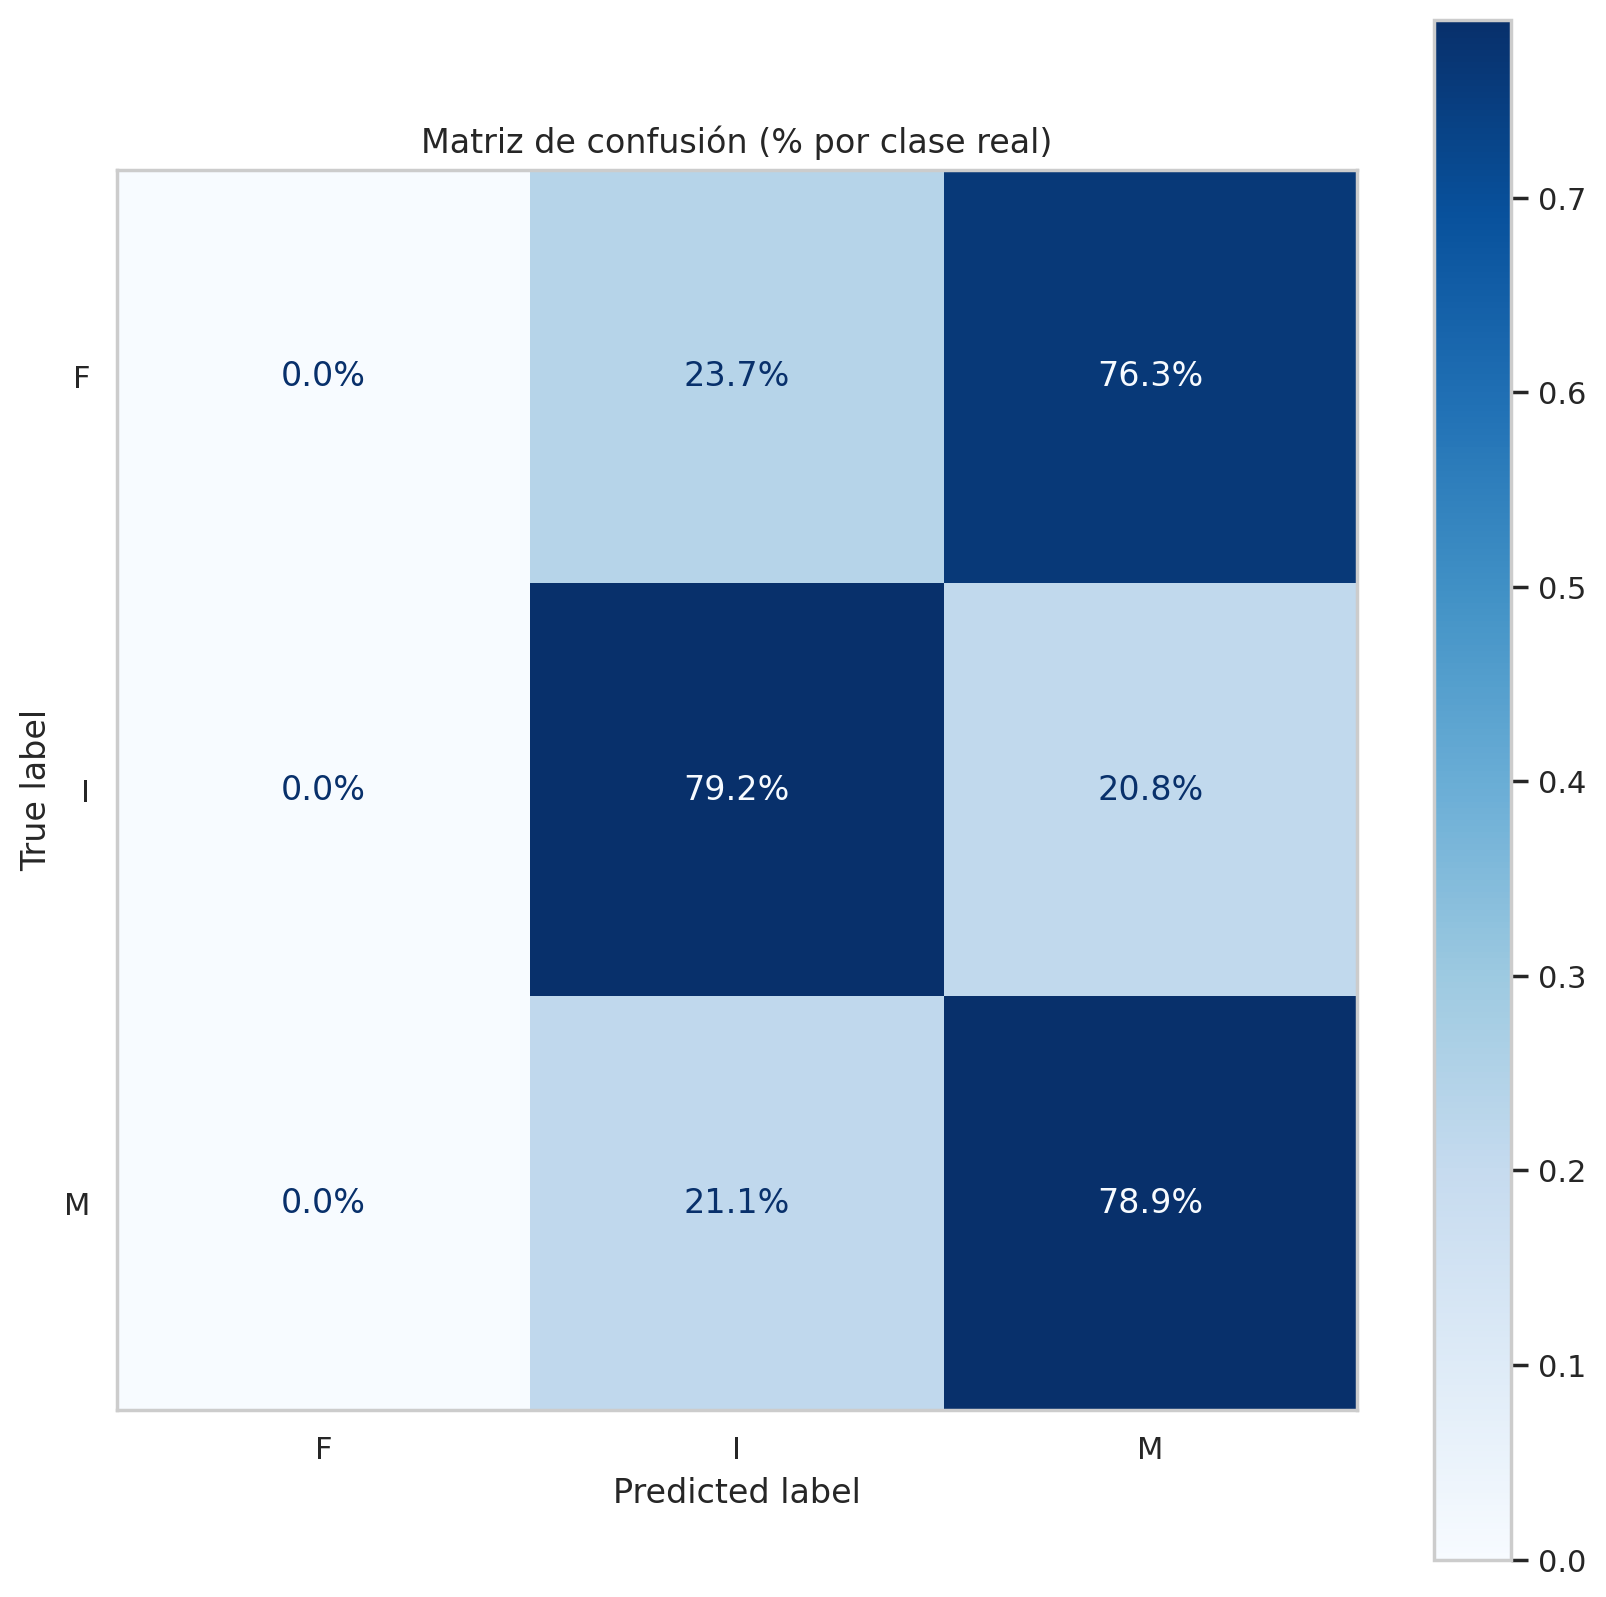

In [19]:
matriz_confusion(rf_a, Xte_a, yte_a);

In [20]:
validar_modelo(rf_a, Xtr_a, ytr_a, 'f1_weighted', 10);

Validacion cruzada (10 folds, score=f1_weighted): media = 0.531 +/- 0.015


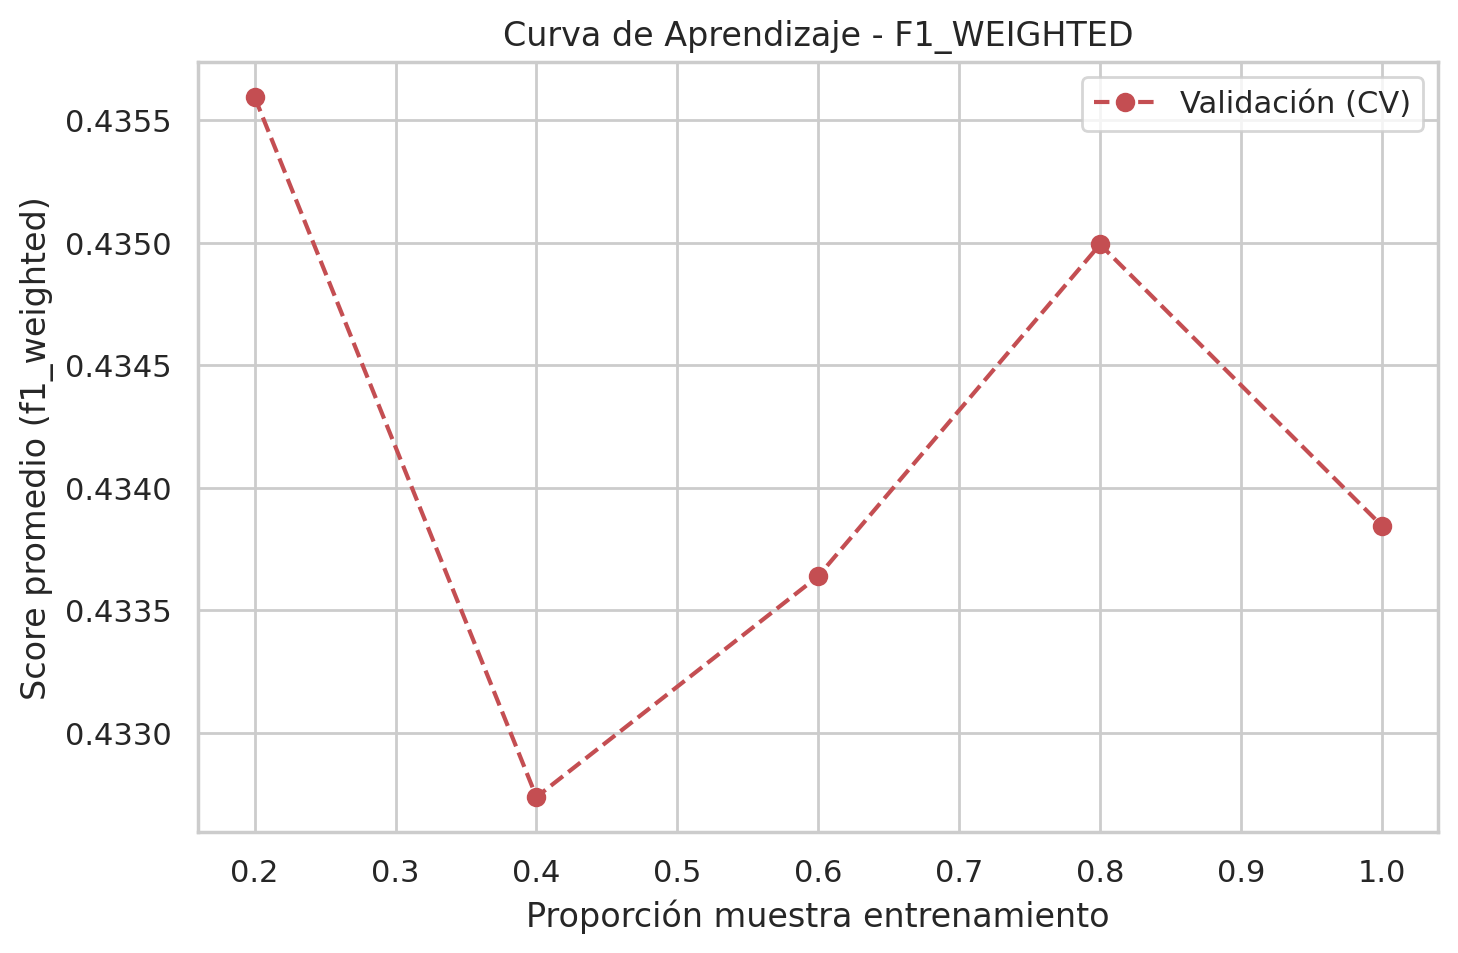

In [21]:
curva_aprendizaje(rf_a, Xtr_a, ytr_a, 'f1_weighted', 5);

La matriz confirma el diagnóstico: **M y F se confunden** sistemáticamente y solo los **infantiles (I)** se distinguen. La validación cruzada es estable en torno a 0.43 y la curva de aprendizaje muestra **curvas planas**.

### Importancia de los predictores

Realizamos ahora el análsiis de importancia de los predictores para determinar el conjunto de inputs más reelvantes en la construcción del modelo.

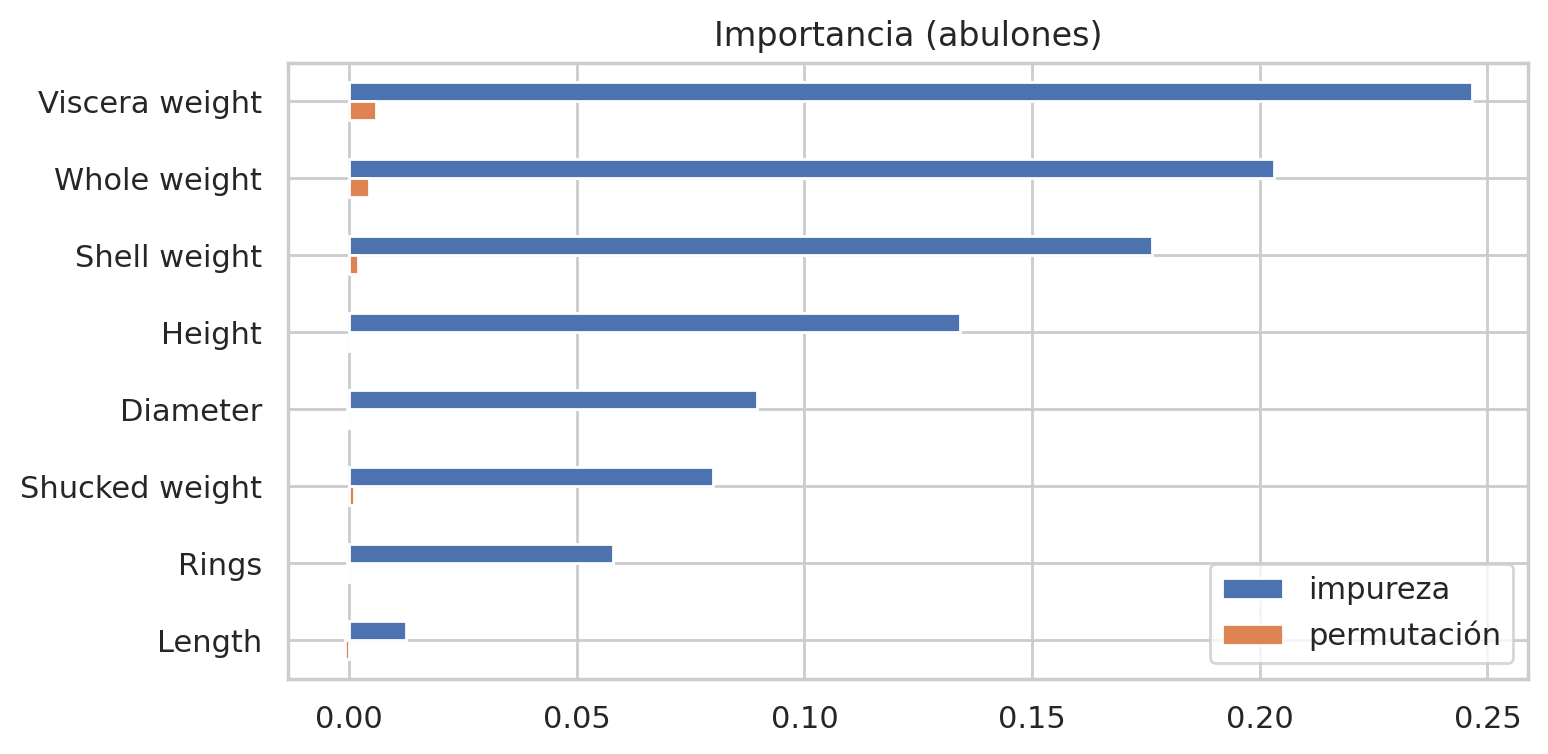

,impureza,permutación
Viscera weight,0.247,0.006
Whole weight,0.203,0.004
Shell weight,0.176,0.002
Height,0.134,0.000
Diameter,0.090,-0.000
Shucked weight,0.080,0.001
Rings,0.058,-0.000
Length,0.012,-0.001


In [22]:
imp_mdi = pd.Series(rf_a.feature_importances_, index=Xtr_a.columns)
perm_a = permutation_importance(rf_a, Xte_a, yte_a, n_repeats=10, random_state=0, scoring='f1_weighted')
imp_perm = pd.Series(perm_a.importances_mean, index=Xte_a.columns)
comp_a = pd.DataFrame({'impureza': imp_mdi, 'permutación': imp_perm}).sort_values('impureza', ascending=False)
comp_a.plot.barh(figsize=(8, 4)); plt.gca().invert_yaxis(); plt.title('Importancia (abulones)'); plt.show()
comp_a.round(3)

Las variables de **peso** (`Viscera weight`, `Whole weight`, `Shell weight`) son las más influyentes en ambas medidas; las de tamaño aportan menos.

### Explicabilidad con valores de Shapley (SHAP, multiclase)

Es un problema de **3 clases**, así que los valores SHAP tienen forma `(n, variables, 3)`. Mostramos la importancia **global** (promediando $|\phi|$ sobre las tres clases) y, para ver la **dirección**, nos centramos en la clase **infantil (I)**, la mejor identificada.

Forma de los valores SHAP: (300, 8, 3) | clases: ['F', 'I', 'M']


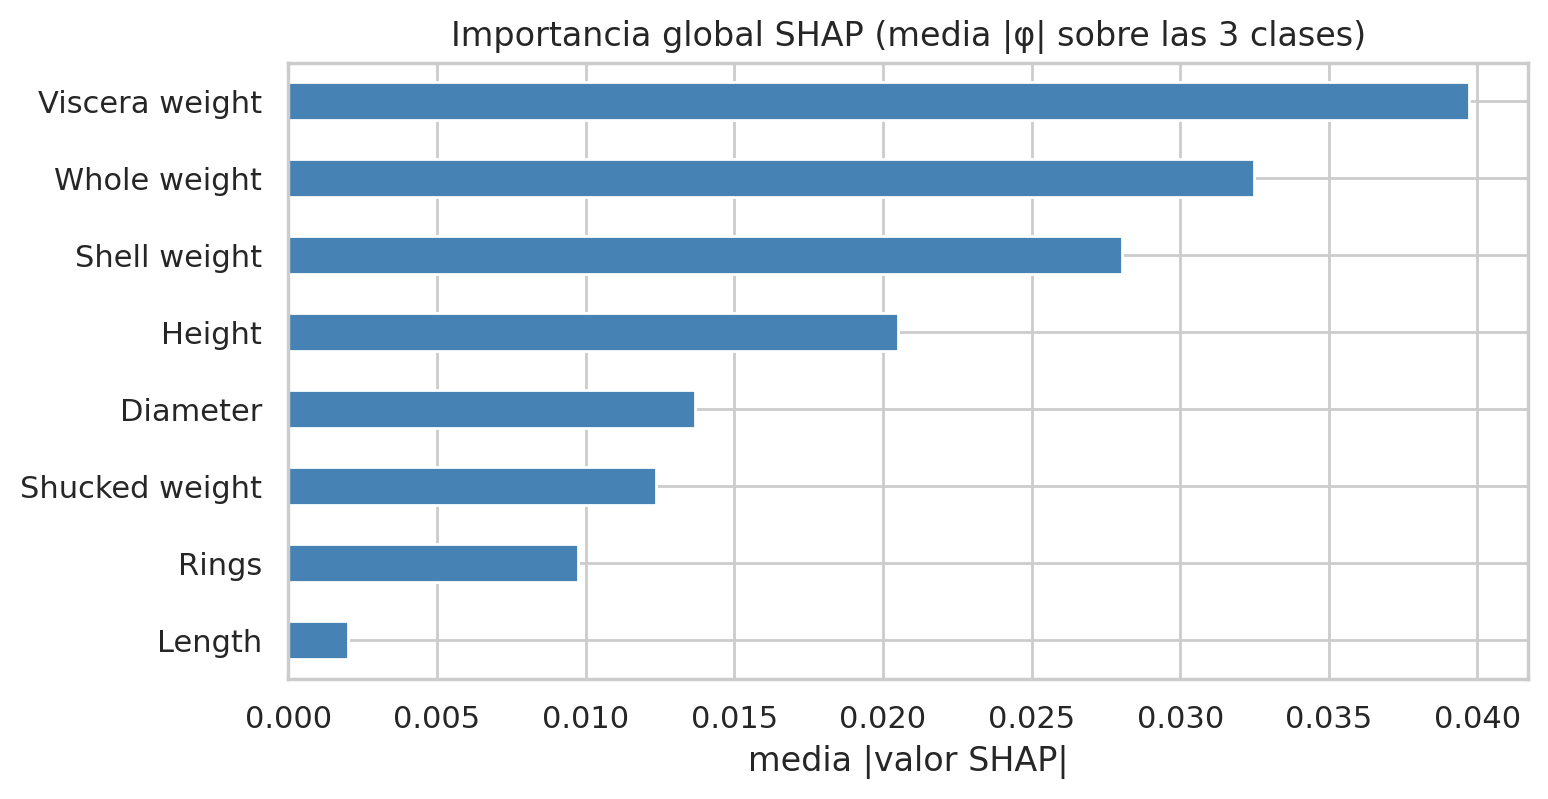

In [23]:
Xs_a = Xte_a.reset_index(drop=True).iloc[:300]
ys_a = yte_a.reset_index(drop=True).iloc[:300]
expl_a = shap.TreeExplainer(rf_a)(Xs_a)
idx_I = list(rf_a.classes_).index('I')
print('Forma de los valores SHAP:', np.array(expl_a.values).shape, '| clases:', list(rf_a.classes_))
imp_glob = pd.Series(np.abs(expl_a.values).mean(axis=(0, 2)), index=Xs_a.columns).sort_values()
imp_glob.plot.barh(figsize=(8, 4), color='steelblue')
plt.title('Importancia global SHAP (media |φ| sobre las 3 clases)'); plt.xlabel('media |valor SHAP|'); plt.show()

El resultado coincide con la importancia clásica: las variables de **peso** dominan. La ventaja de SHAP es que reparte la importancia de forma **coherente** y permite además ver **dirección** y **forma**.

#### Dirección del efecto para la clase infantil (*beeswarm*)

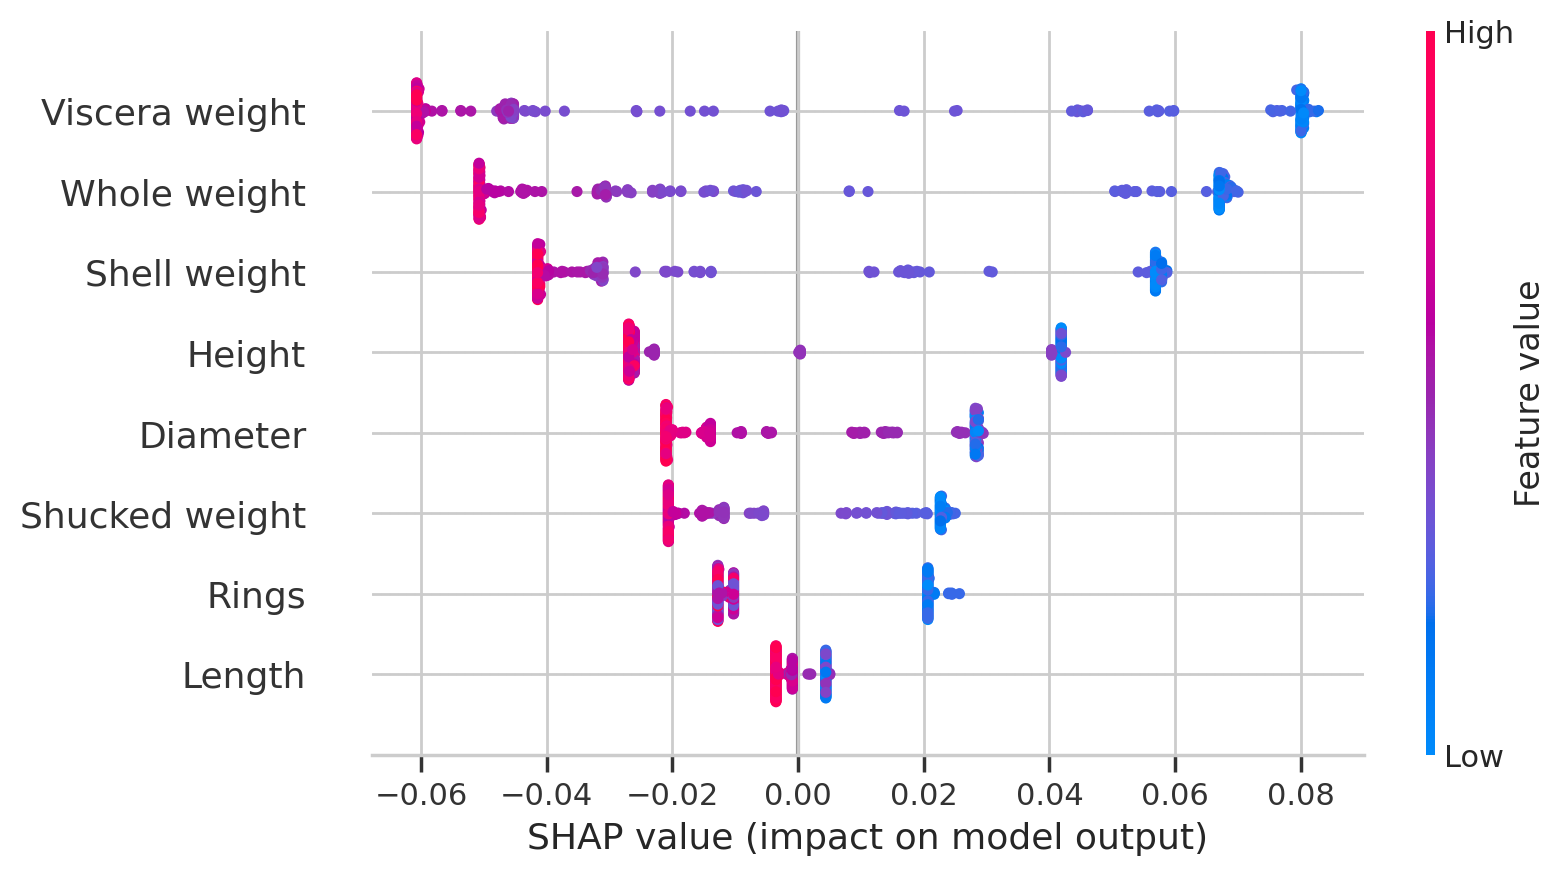

In [24]:
shap.plots.beeswarm(expl_a[:, :, idx_I], max_display=8)

Cada punto es un abulón; a la derecha, empuje hacia **infantil**. Los **valores bajos (azul) de las variables de peso** empujan hacia **infantil** (los juveniles pesan menos) y los pesos altos (rojo) empujan en contra: coherente con la biología.

#### Explicación local de 4 abulones (*waterfall*)

Mostramos cuatro abulones que cubren el rango de probabilidad de la clase infantil, indicando en cada uno su fila, su clase real y su probabilidad.

>>> Muestra 1: fila 2  |  clase real = M  |  probabilidad predicha de la clase analizada = 0.08


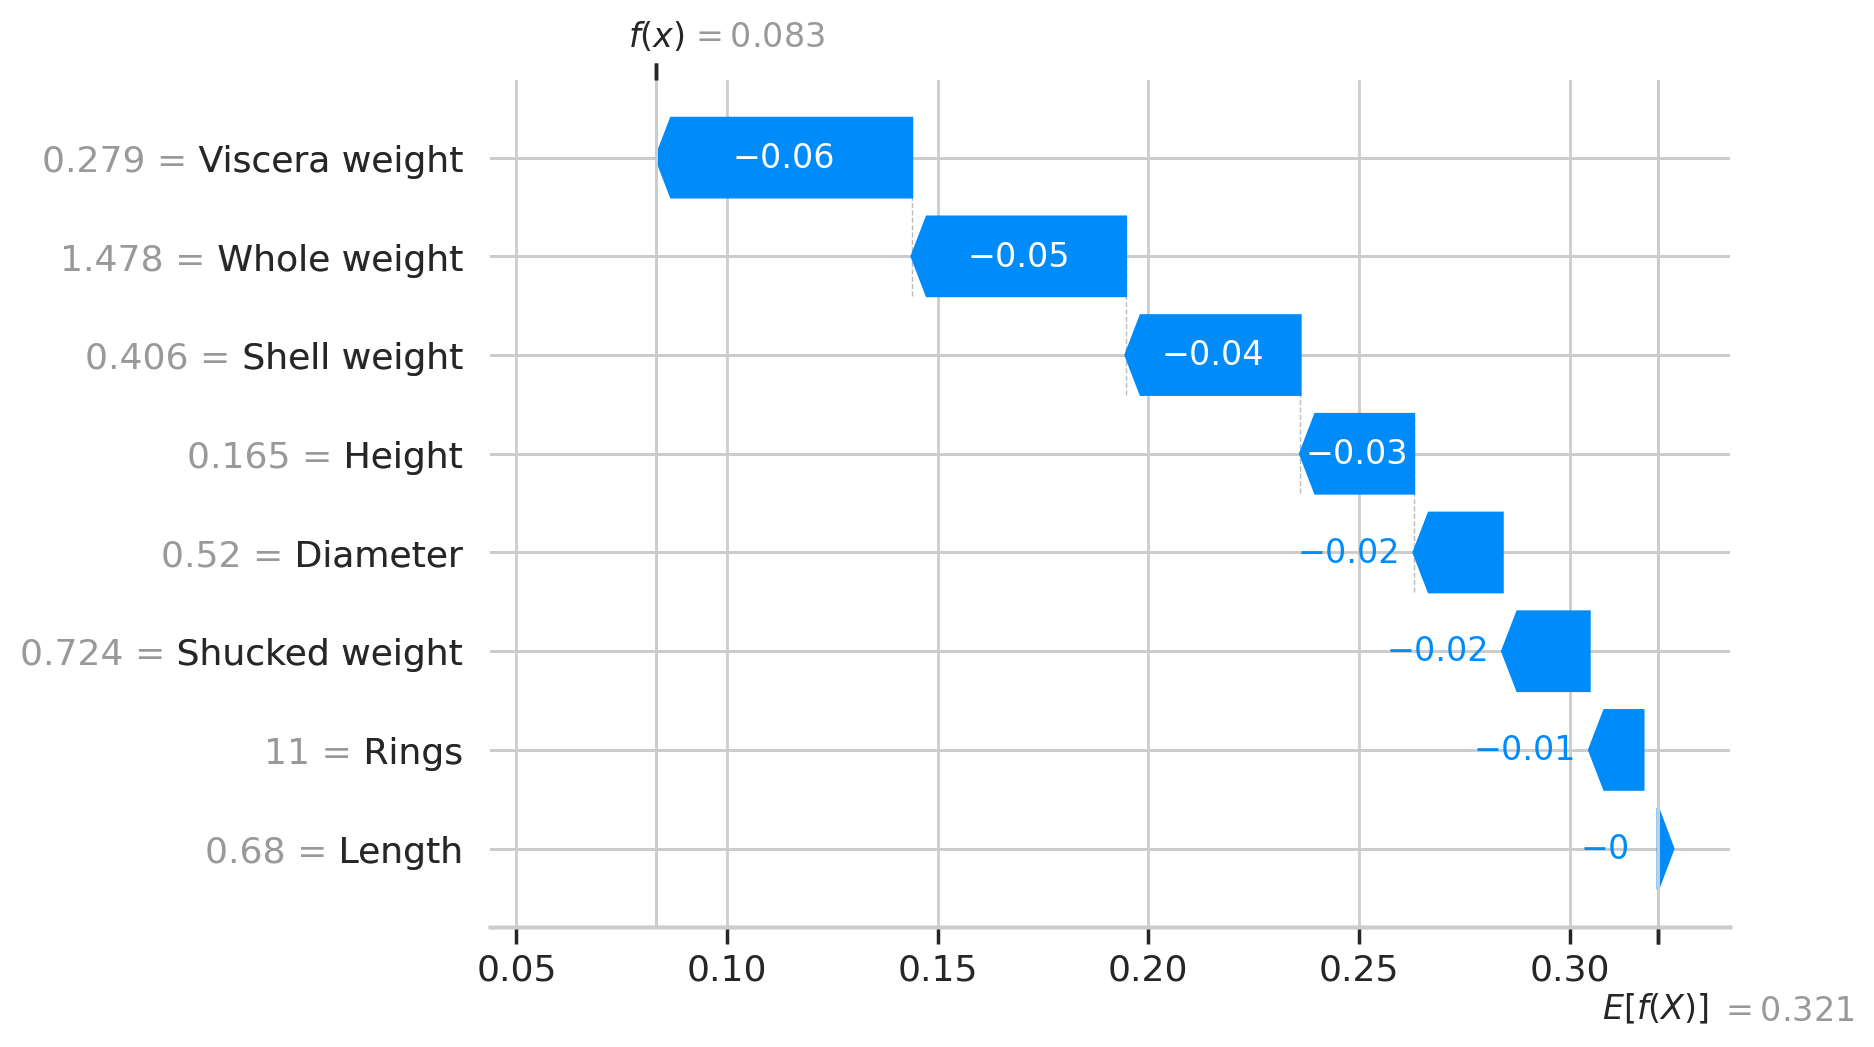

>>> Muestra 2: fila 207  |  clase real = M  |  probabilidad predicha de la clase analizada = 0.26


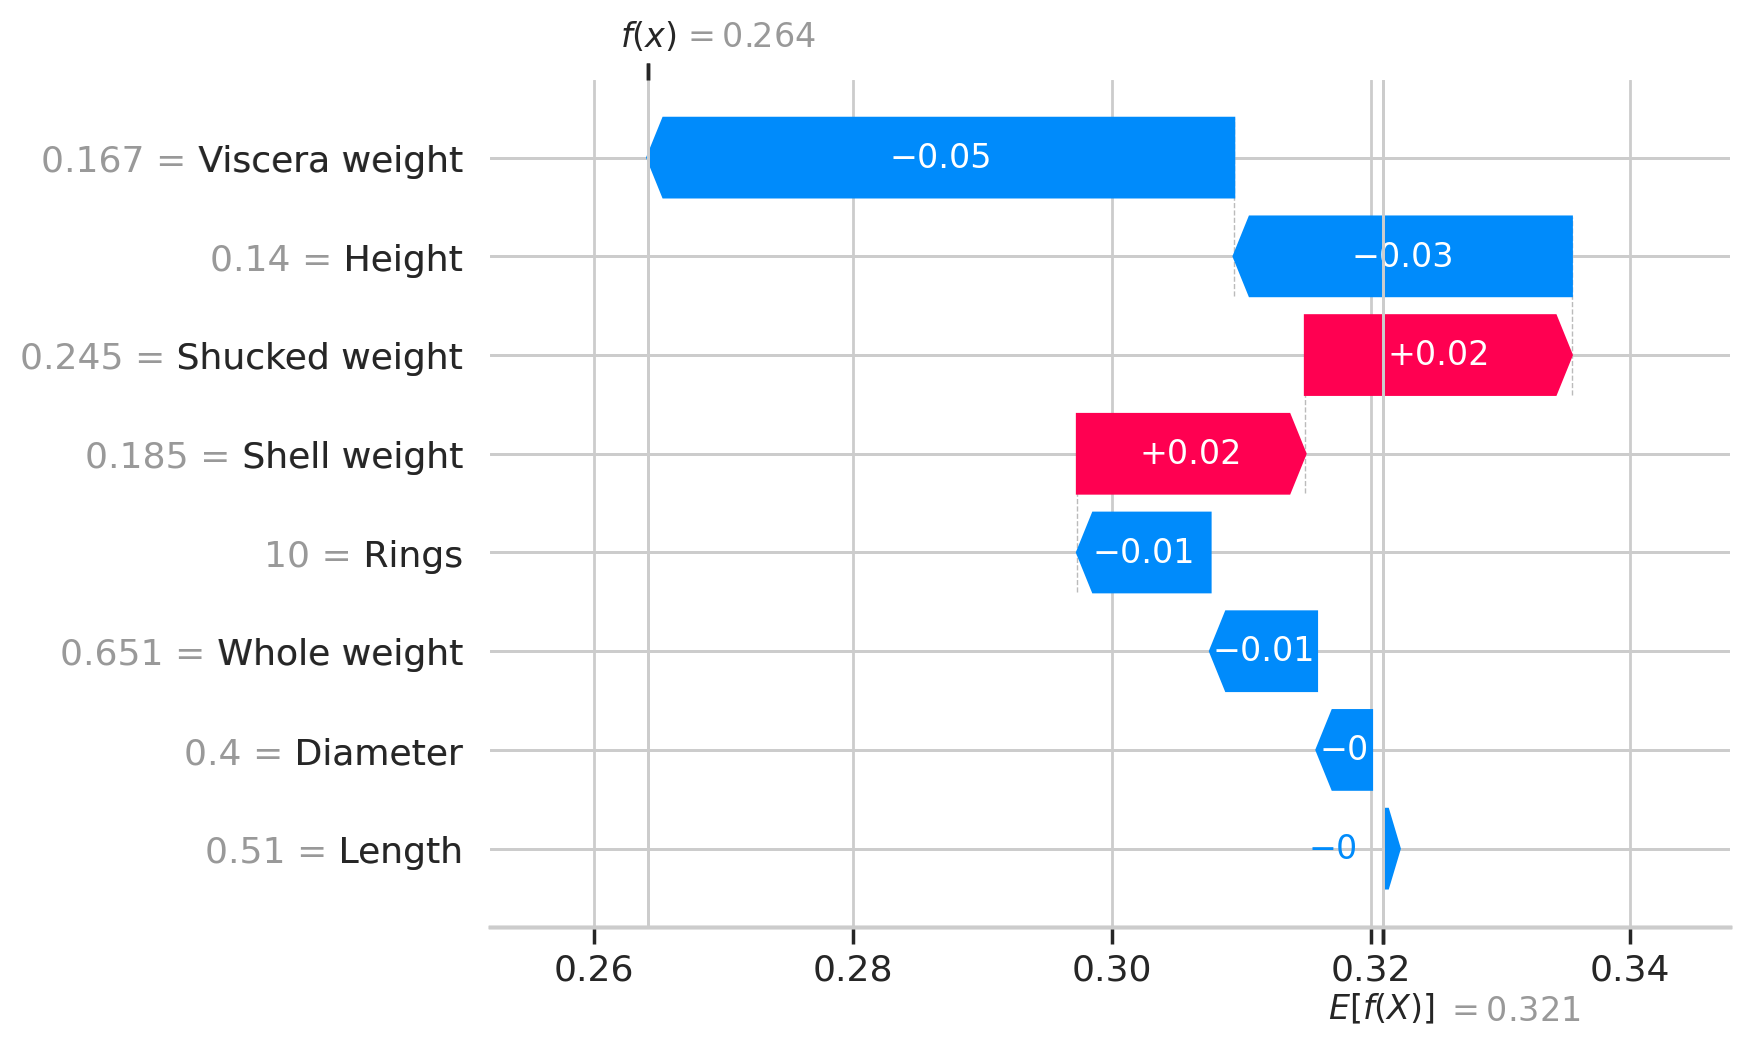

>>> Muestra 3: fila 157  |  clase real = I  |  probabilidad predicha de la clase analizada = 0.46


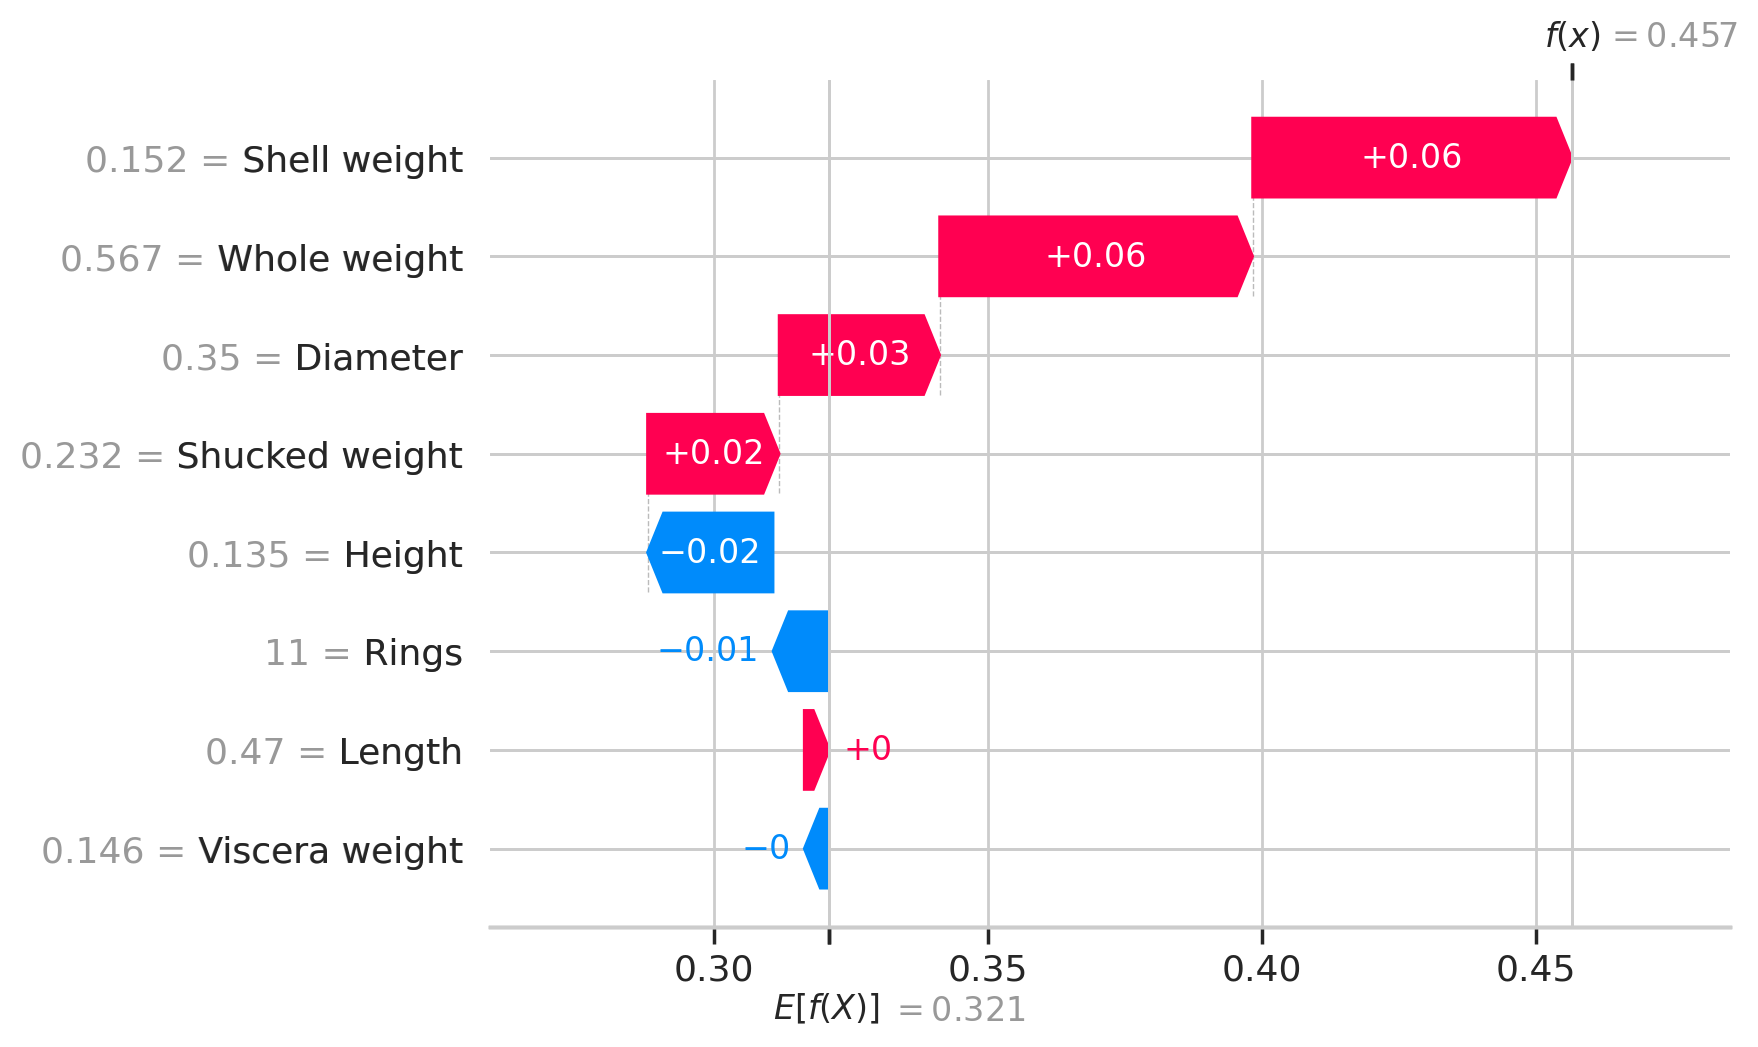

>>> Muestra 4: fila 8  |  clase real = I  |  probabilidad predicha de la clase analizada = 0.64


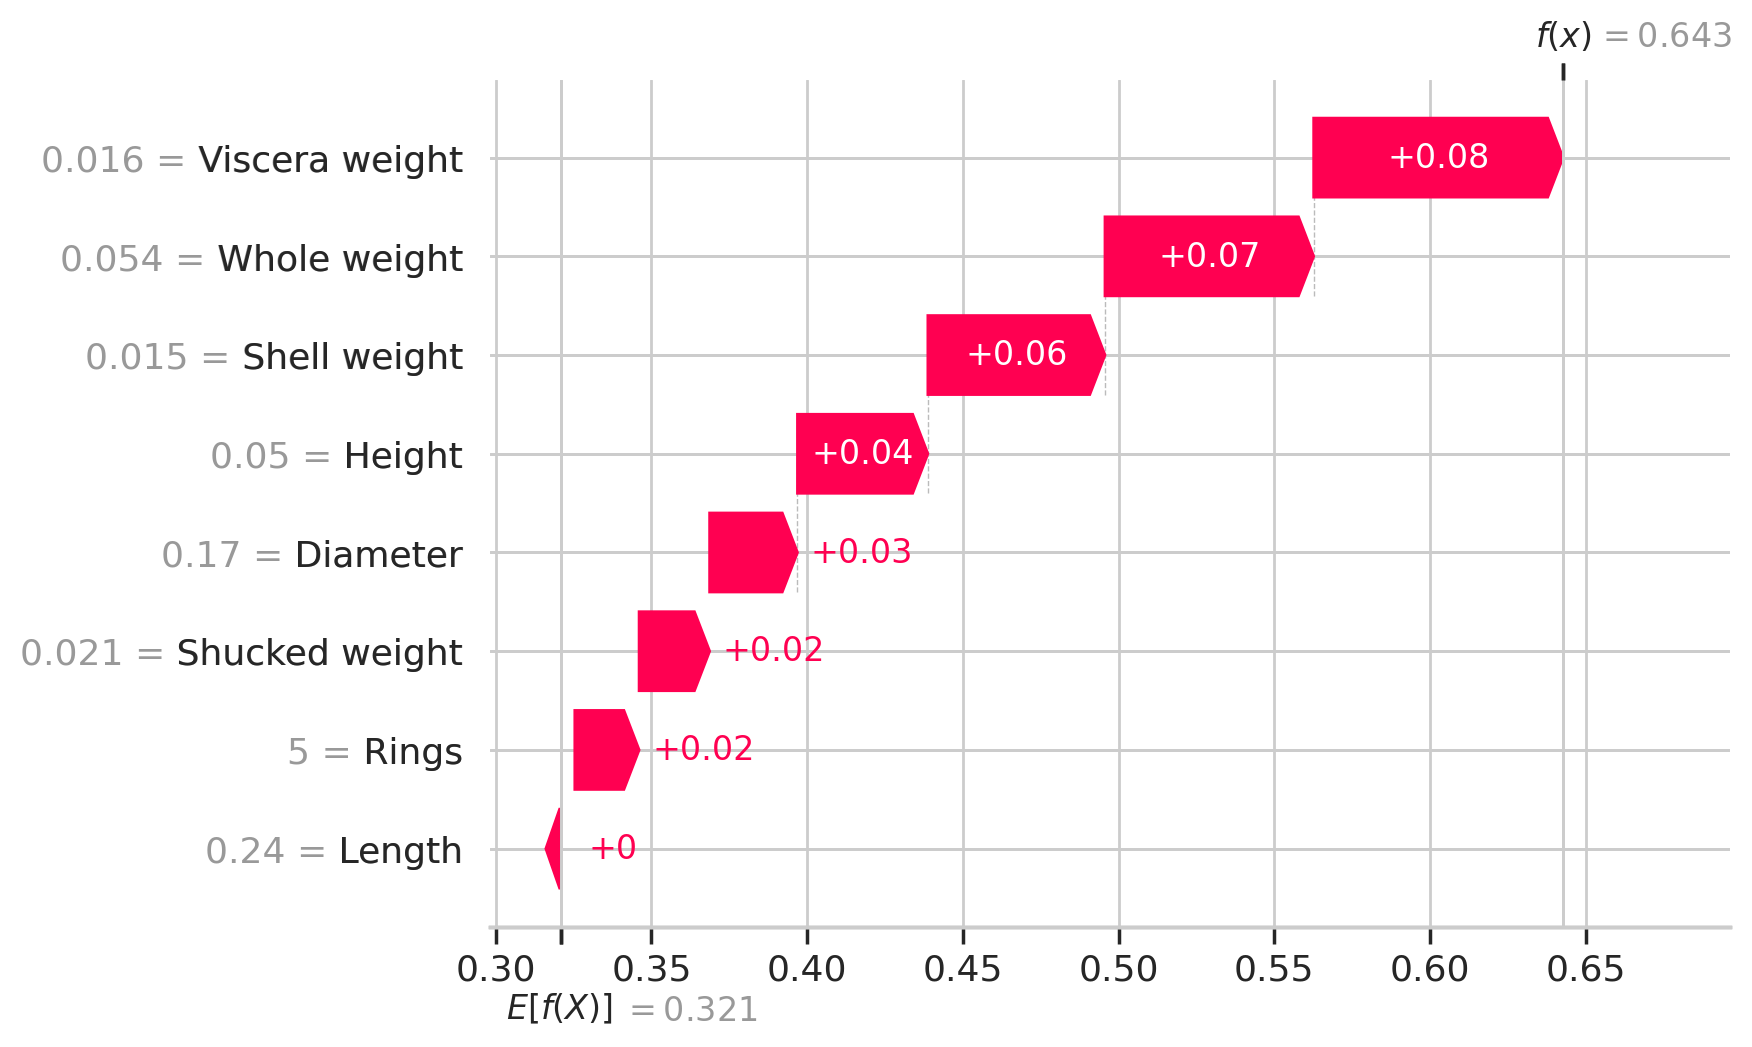

In [25]:
proba_I = rf_a.predict_proba(Xs_a)[:, idx_I]
waterfalls_muestras(expl_a[:, :, idx_I], proba_I, ys_a, n=4)

Comparando los cuatro casos se ve que el modelo usa **combinaciones distintas** de variables según el ejemplar: los individuos de pesos pequeños acumulan empujes hacia "infantil" (barras rojas) y los grandes, en contra (azules).

#### Forma del efecto (*scatter*)

Recordatorio de lectura: en el **eje X** va el **valor real** de la variable y en el **eje Y** su **valor SHAP**; así vemos **cómo cambia el empuje según el valor** de la variable. El color codifica la variable que más interactúa.

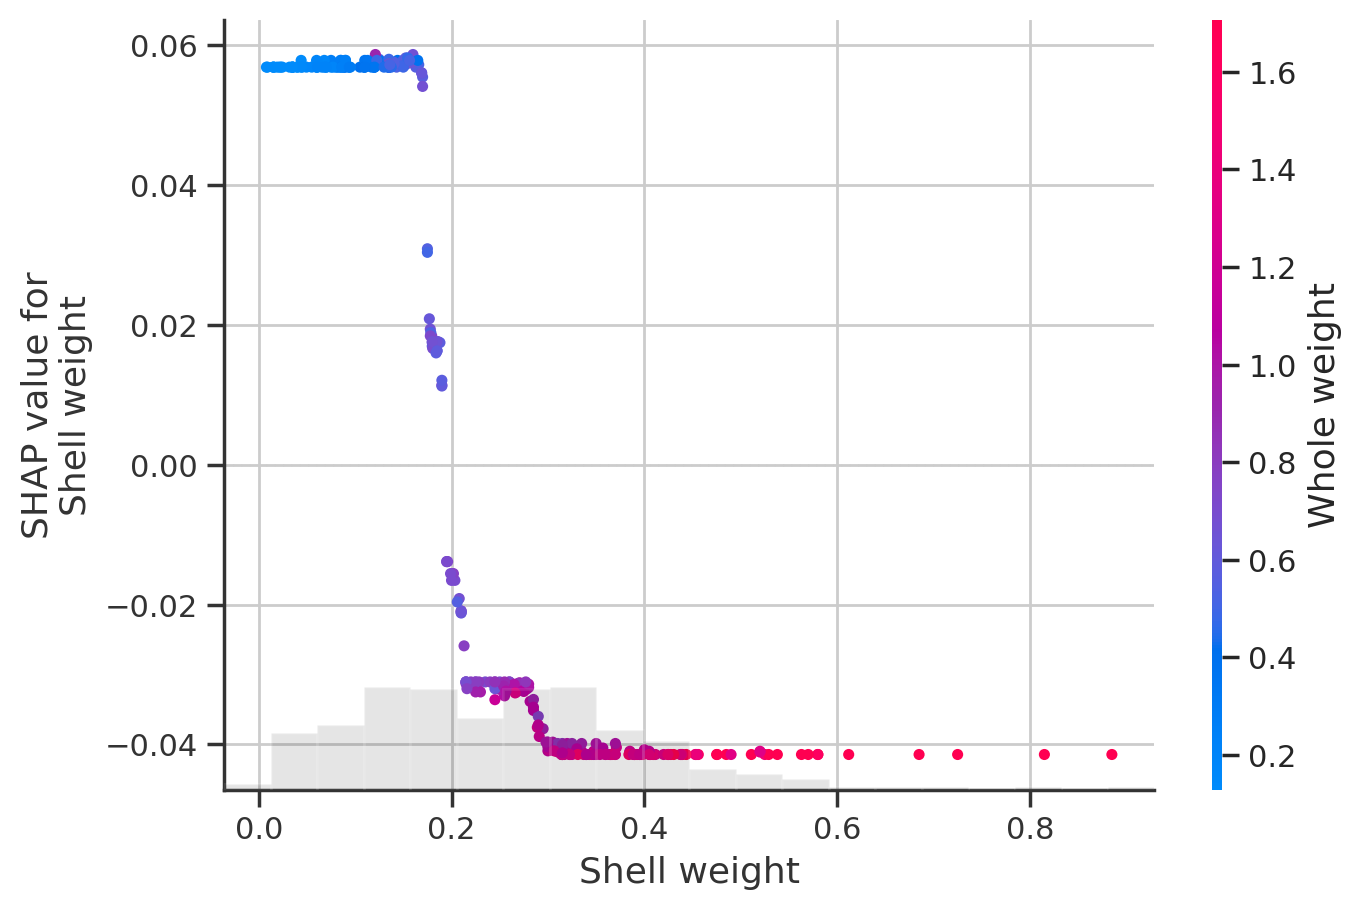

In [26]:
shap.plots.scatter(expl_a[:, :, idx_I][:, 'Shell weight'], color=expl_a[:, :, idx_I])

**Pesos pequeños** de `Shell weight` dan SHAP **positivo** (empujan a "infantil") y, al crecer el peso, el empuje **cae** y se vuelve negativo: un efecto **decreciente** claro, coherente con que los adultos pesan más.

## <font color="steelblue">9.4. Ejemplo 4: Cáncer de mama</font>

Clasificamos tumores como **benignos (B)** o **malignos (M)** por 30 medidas. Cargamos `cancer.csv` **sin limpiar** y solo **eliminamos el identificador `id`** (no es un predictor). **No estandarizamos** (árboles, sección 7), lo que además hará legibles las gráficas SHAP.

In [27]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer.csv'
cancer = pd.read_csv(url).drop(columns='id')
cancer['diagnosis'] = cancer['diagnosis'].astype('category')
print('Dimensiones:', cancer.shape, '| ausentes:', int(cancer.isna().sum().sum()))
tr, te = split_sample(cancer, 'diagnosis', 0.3, 0, True)
Xtr_c, ytr_c = tr.drop(columns='diagnosis'), tr['diagnosis']
Xte_c, yte_c = te.drop(columns='diagnosis'), te['diagnosis']

Dimensiones: (569, 31) | ausentes: 0
Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras


### Random Forest vs Extra Trees y diagnóstico de sobreajuste

In [28]:
tabla_c, modelos_c = comparar_rf_extra(Xtr_c, ytr_c, Xte_c, yte_c)
tabla_c

,F1 train,F1 test,desfase (train-test)
modelo,,,
Random Forest,1.0,0.948,0.052
Extra Trees,1.0,0.948,0.052


Aunque el F1 en train es perfecto (1.0), el de **test se mantiene muy alto (≈ 0.95)**: el **desfase es pequeño**, así que aquí el "train perfecto" **no es sobreajuste preocupante**, sino que el problema es **genuinamente aprendible**. RF y Extra Trees empatan.

### Optimización de hiperparámetros (grid sobre OOB)

In [29]:
malla = {'n_estimators': [300], 'max_depth': [4, 6, 8, None],
         'min_samples_leaf': [0.10, 0.15, 0.20], 'max_features': ['sqrt', 0.5]}
rf_c, params_c, oob_c = optimizar_oob(Xtr_c, ytr_c, malla)
print('Mejores hiperparámetros:', params_c, '| OOB =', round(oob_c, 3))
print(f'F1 train = {f1_score(ytr_c, rf_c.predict(Xtr_c), average="weighted"):.3f} | '
      f'F1 test = {f1_score(yte_c, rf_c.predict(Xte_c), average="weighted"):.3f}')

Mejores hiperparámetros: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 0.1, 'n_estimators': 300} | OOB = 0.93
F1 train = 0.955 | F1 test = 0.936


El OOB óptimo ronda **0.93**, coherente con el test (~0.95–0.94). El pequeño desfase confirma que **no hay sobreajuste relevante**.

### Evaluación del modelo óptimo

In [30]:
reports_clas(rf_c, Xtr_c, ytr_c, Xte_c, yte_c)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           B       0.96      0.97      0.96       250
           M       0.95      0.93      0.94       148

    accuracy                           0.95       398
   macro avg       0.95      0.95      0.95       398
weighted avg       0.95      0.95      0.95       398


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           B       0.97      0.93      0.95       107
           M       0.88      0.95      0.92        64

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.93       171
weighted avg       0.94      0.94      0.94       171



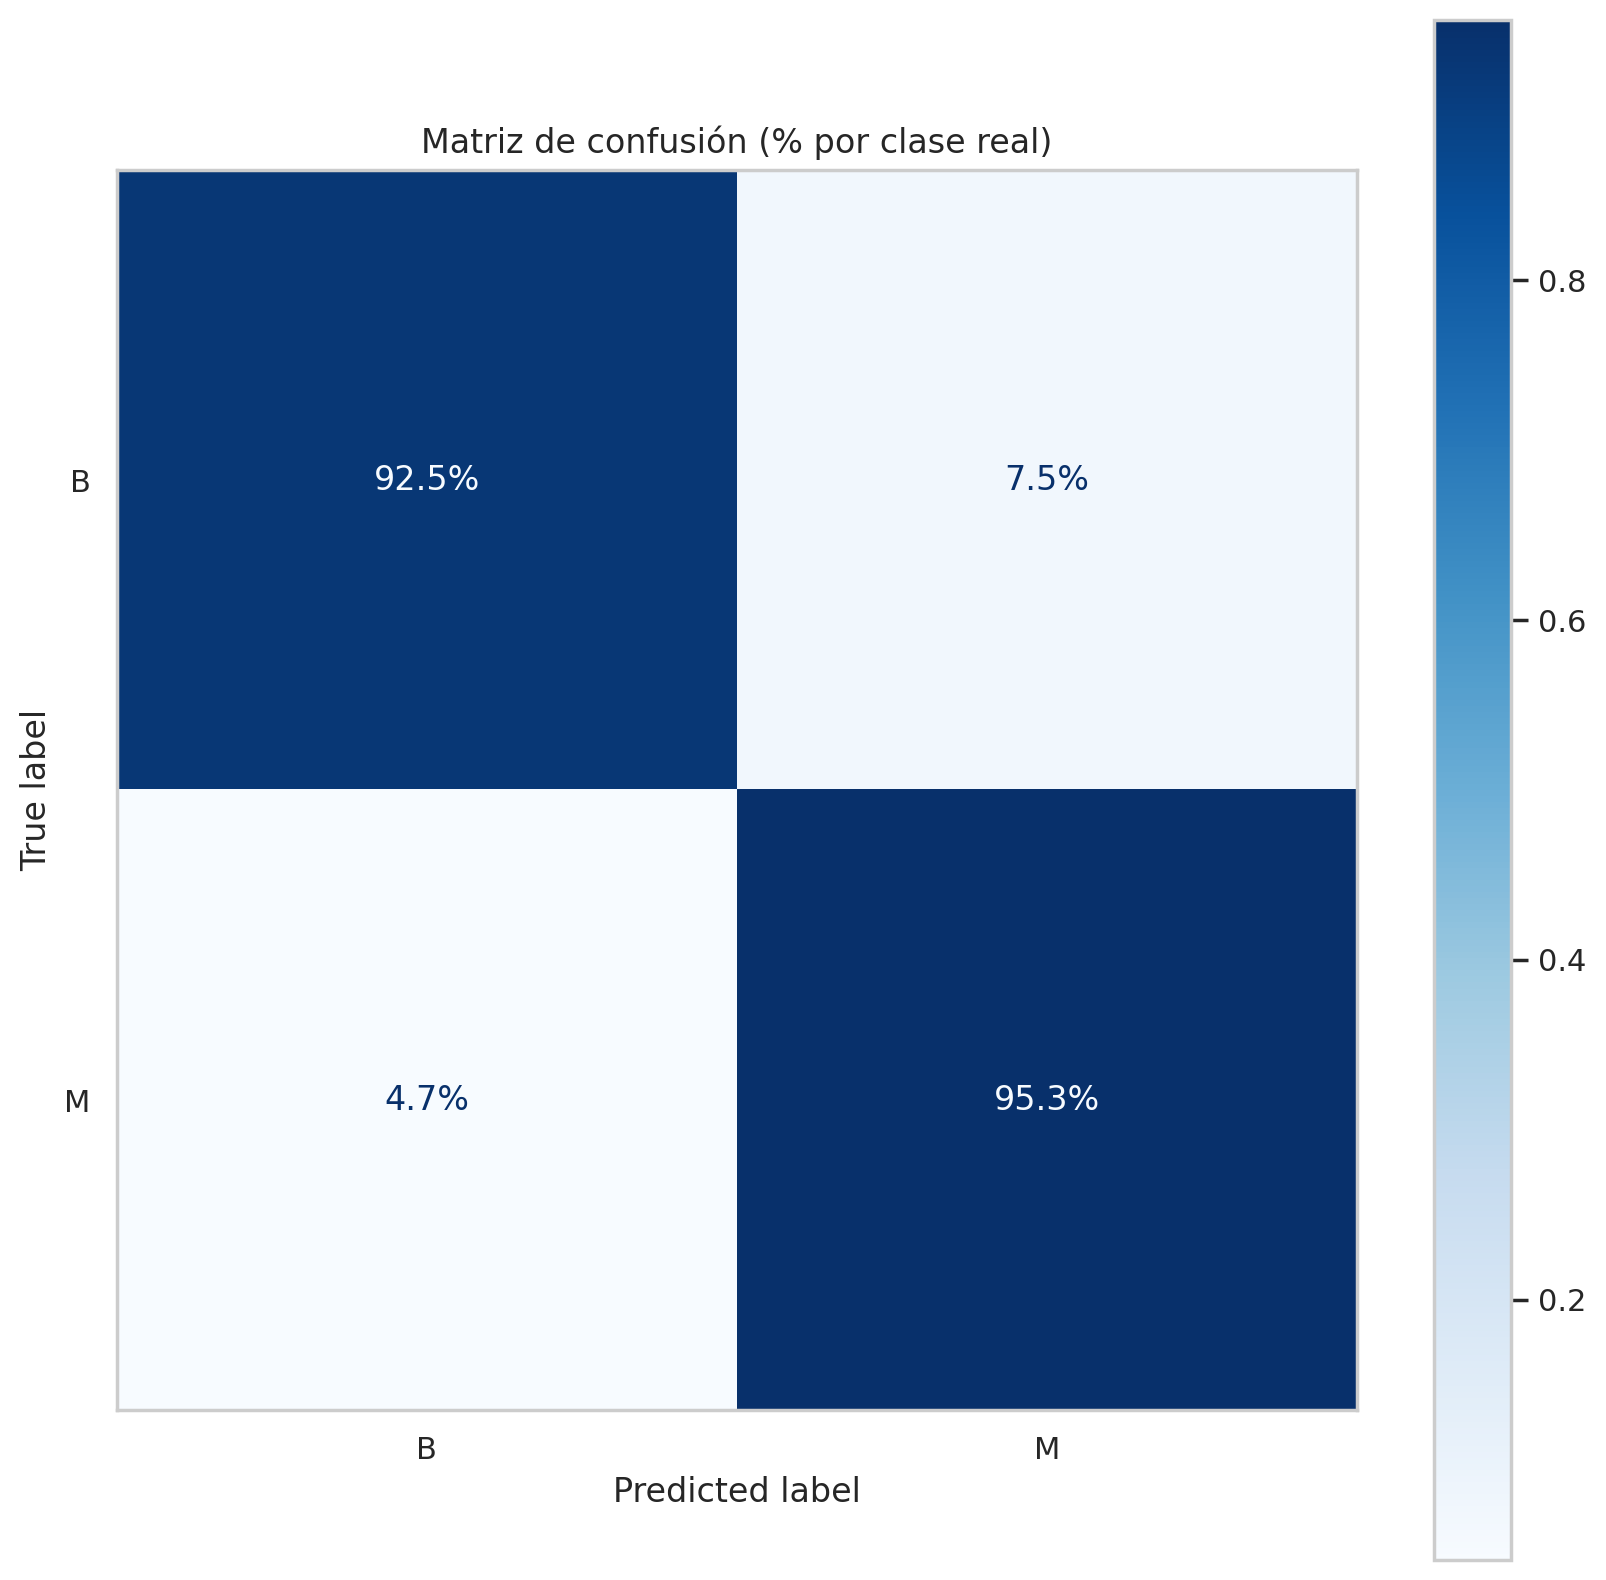

In [31]:
matriz_confusion(rf_c, Xte_c, yte_c);

### Importancia de los predictores: impureza y permutación

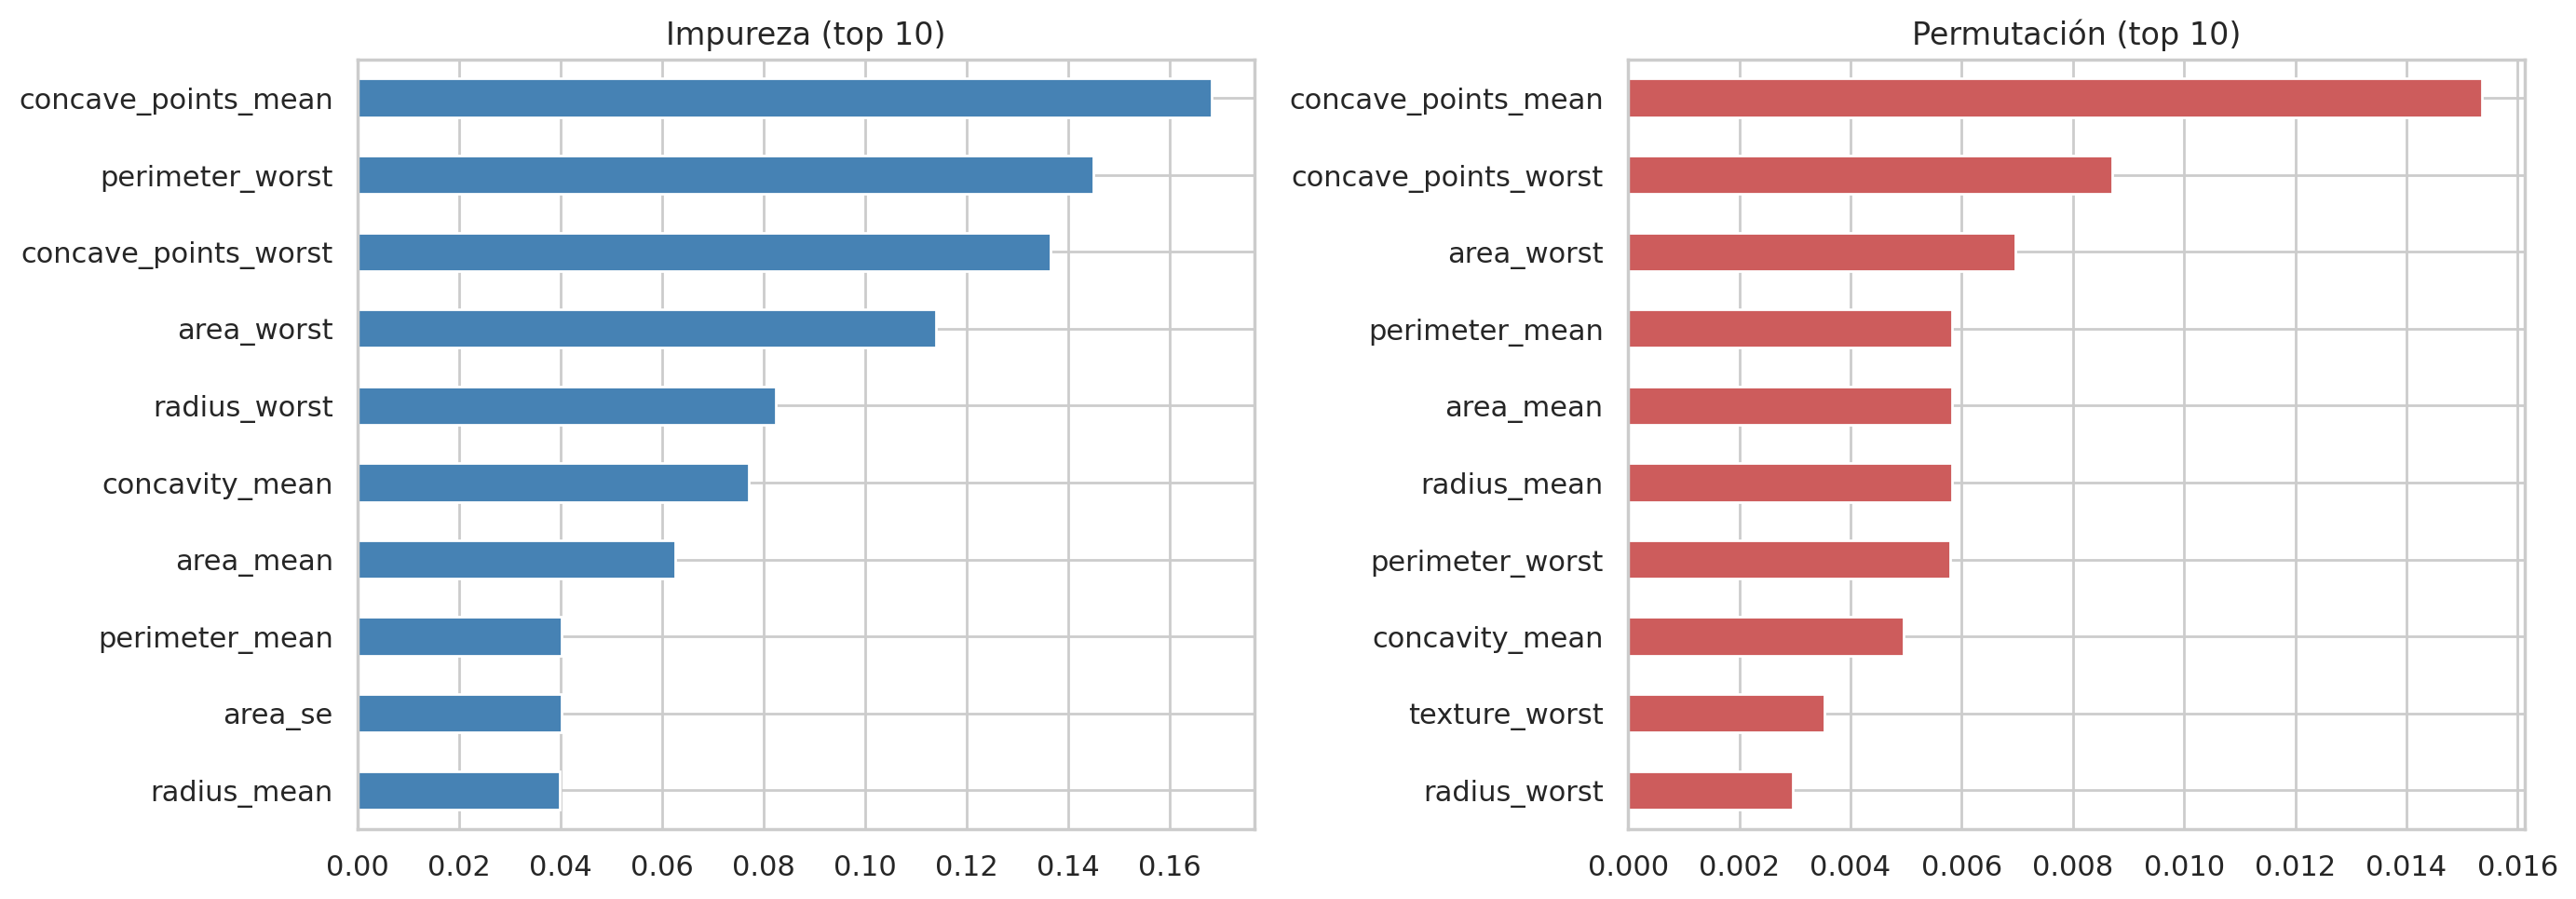

In [32]:
imp_c = pd.Series(rf_c.feature_importances_, index=Xtr_c.columns).sort_values(ascending=False).head(10)
perm = permutation_importance(rf_c, Xte_c, yte_c, n_repeats=10, random_state=0, scoring='f1_weighted')
imp_p = pd.Series(perm.importances_mean, index=Xte_c.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
imp_c.plot.barh(ax=ax[0], color='steelblue'); ax[0].invert_yaxis(); ax[0].set_title('Impureza (top 10)')
imp_p.plot.barh(ax=ax[1], color='indianred'); ax[1].invert_yaxis(); ax[1].set_title('Permutación (top 10)')
plt.tight_layout(); plt.show()

Dominan las variables del grupo *worst*. La permutación da valores **pequeños** porque muchas variables están **muy correlacionadas** y se "cubren" entre sí: justo la limitación que SHAP resuelve mejor.

### Explicabilidad con valores de Shapley (SHAP)

Aplicamos **TreeSHAP** al bosque óptimo. Como es binario, los valores SHAP tienen forma `(n, variables, 2)`; tomamos la clase **maligna** (`M`, índice 1).

In [33]:
muestra = Xte_c.reset_index(drop=True)
ys_c = yte_c.reset_index(drop=True)
expl = shap.TreeExplainer(rf_c)(muestra)
shap_M = expl[:, :, 1]
print('Forma de los valores SHAP:', np.array(expl.values).shape)
print('Valor base (probabilidad media de maligno):', round(float(expl.base_values[0, 1]), 3))
i0 = int((rf_c.predict_proba(muestra)[:, 1] > 0.5).argmax())
print(f'Aditividad (fila {i0}) -> base + Σshap = {shap_M.values[i0].sum() + shap_M.base_values[i0]:.3f}'
      f'   |   predict_proba(M) = {rf_c.predict_proba(muestra.iloc[[i0]])[0,1]:.3f}')

Forma de los valores SHAP: (171, 30, 2)
Valor base (probabilidad media de maligno): 0.372
Aditividad (fila 3) -> base + Σshap = 0.968   |   predict_proba(M) = 0.968


El **valor base** es la probabilidad media de maligno; sumándole los valores SHAP de una observación se reconstruye **exactamente** su probabilidad predicha (aditividad).



#### Importancia global: gráfico de barras

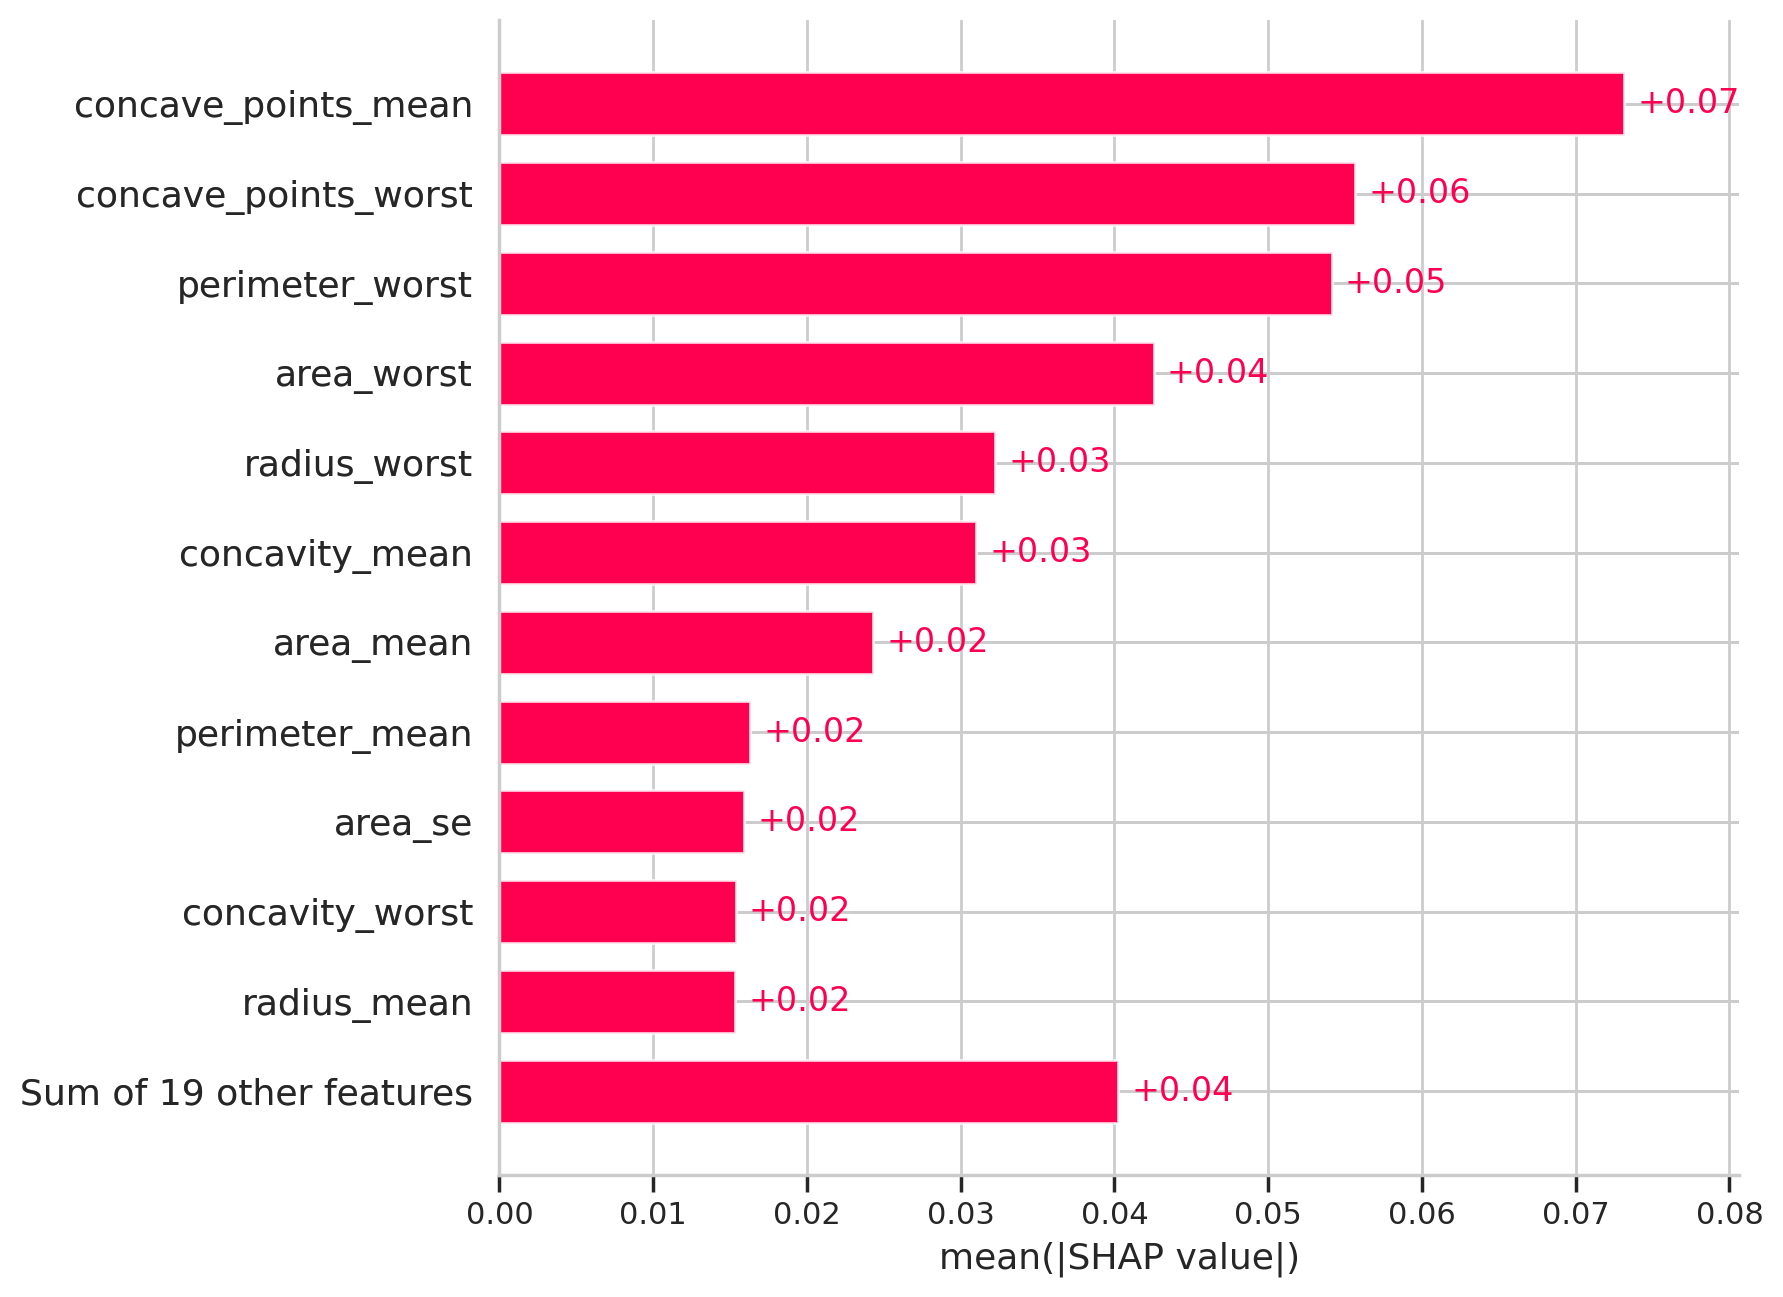

In [34]:
shap.plots.bar(shap_M, max_display=12)

Las variables del grupo *worst* (`concave_points_worst`, `radius_worst`, `area_worst`…) son las que más mueven la predicción, repartiendo la importancia de forma justa entre las correlacionadas.



#### Efecto y dirección: gráfico de enjambre (*beeswarm*)

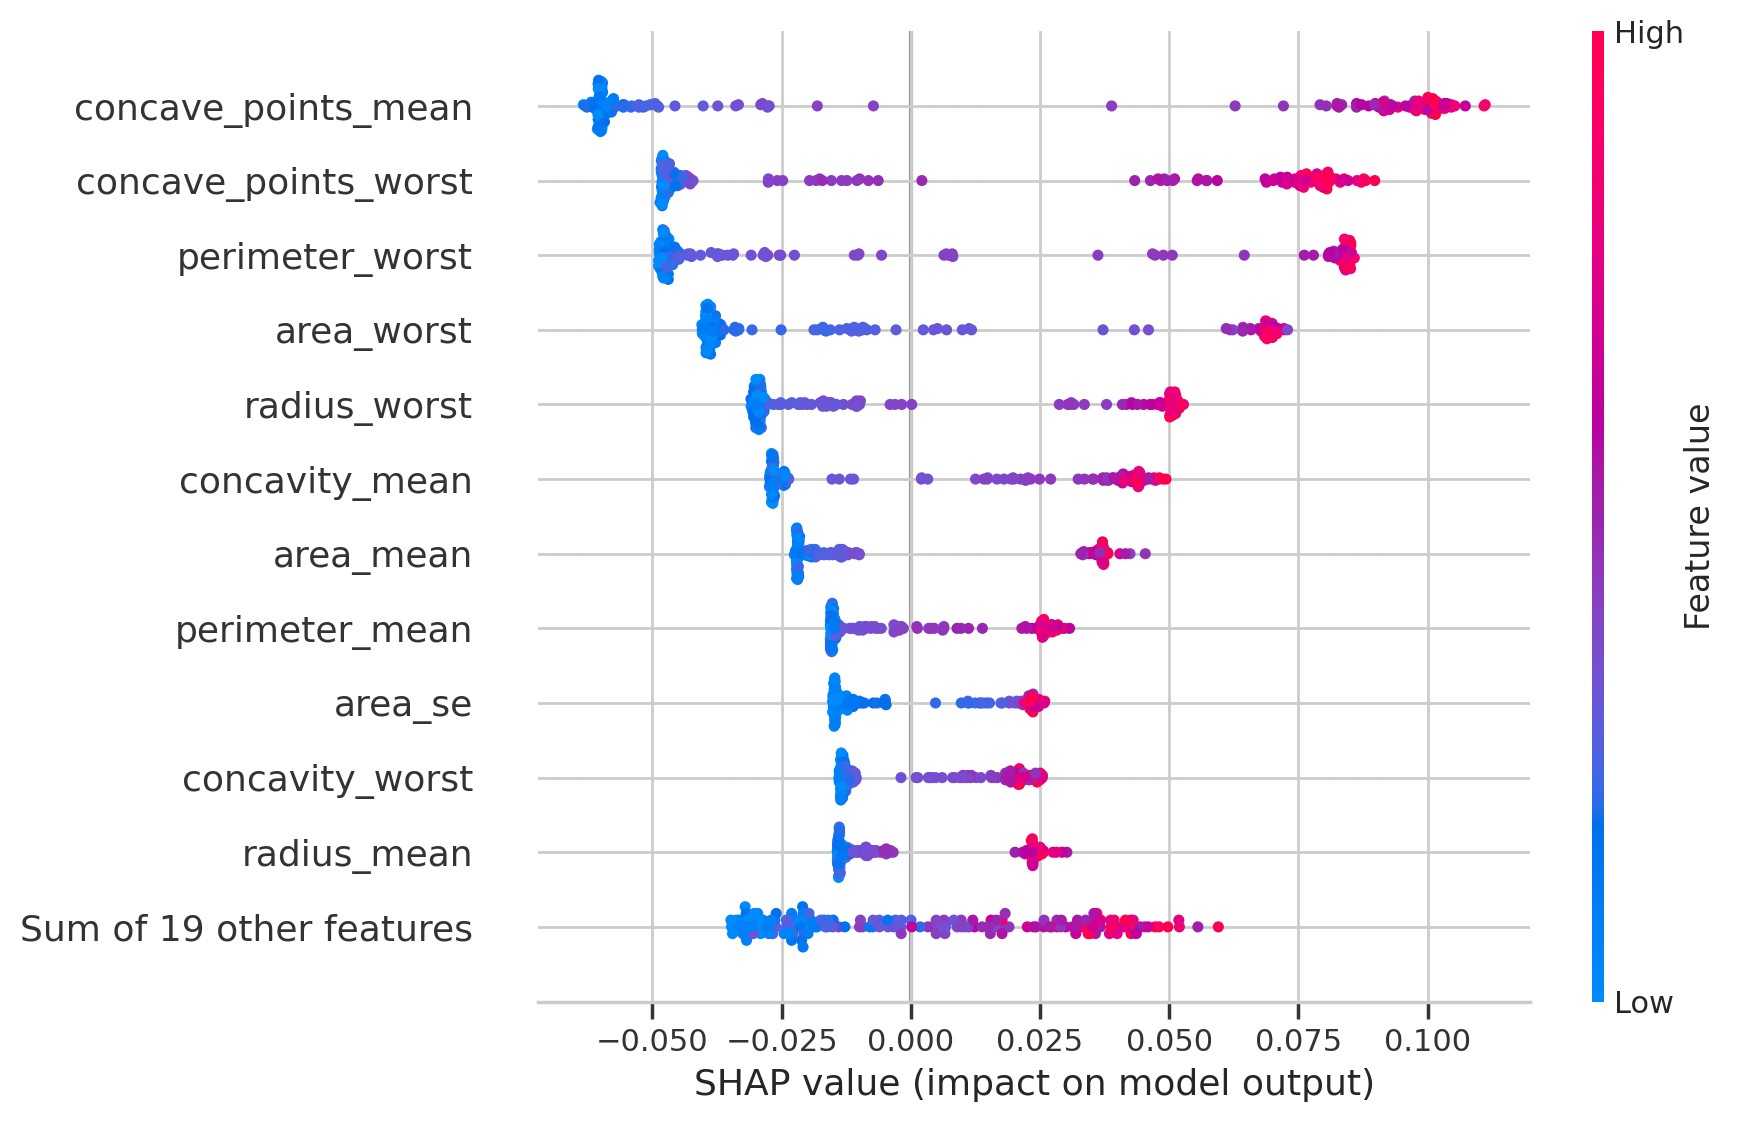

In [35]:
shap.plots.beeswarm(shap_M, max_display=12)

Para `concave_points_worst` o `radius_worst`, los **valores altos (rojo) están a la derecha**: tumores más grandes/irregulares → mayor probabilidad de **maligno**. Los valores bajos (azul) empujan hacia benigno.



#### Explicación local de 4 pacientes (*waterfall*)

Mostramos cuatro pacientes que cubren el rango de probabilidad (de claramente benigno a claramente maligno), indicando en cada uno su fila, su diagnóstico real y su probabilidad predicha.

>>> Muestra 1: fila 23  |  clase real = B  |  probabilidad predicha de la clase analizada = 0.00


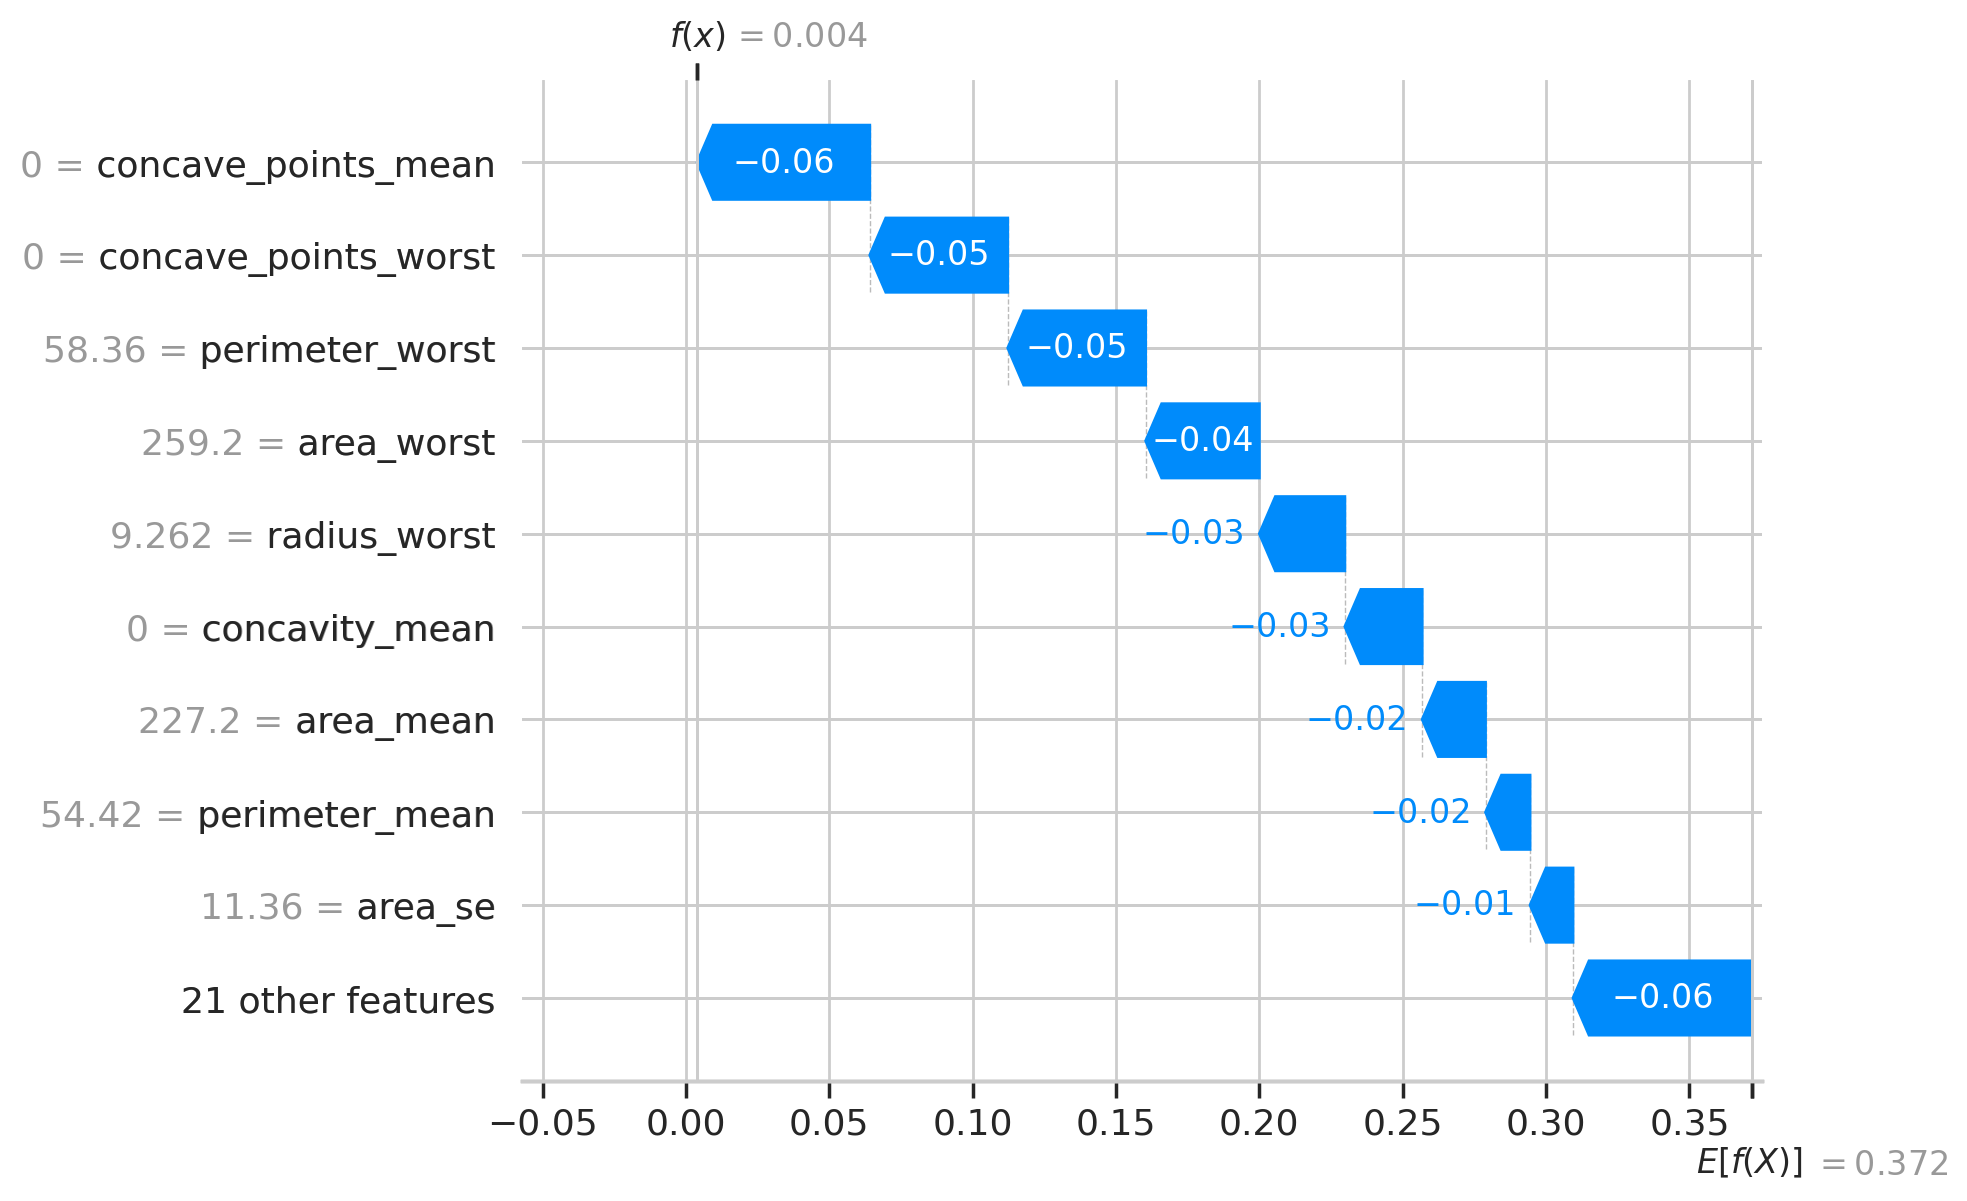

>>> Muestra 2: fila 6  |  clase real = B  |  probabilidad predicha de la clase analizada = 0.33


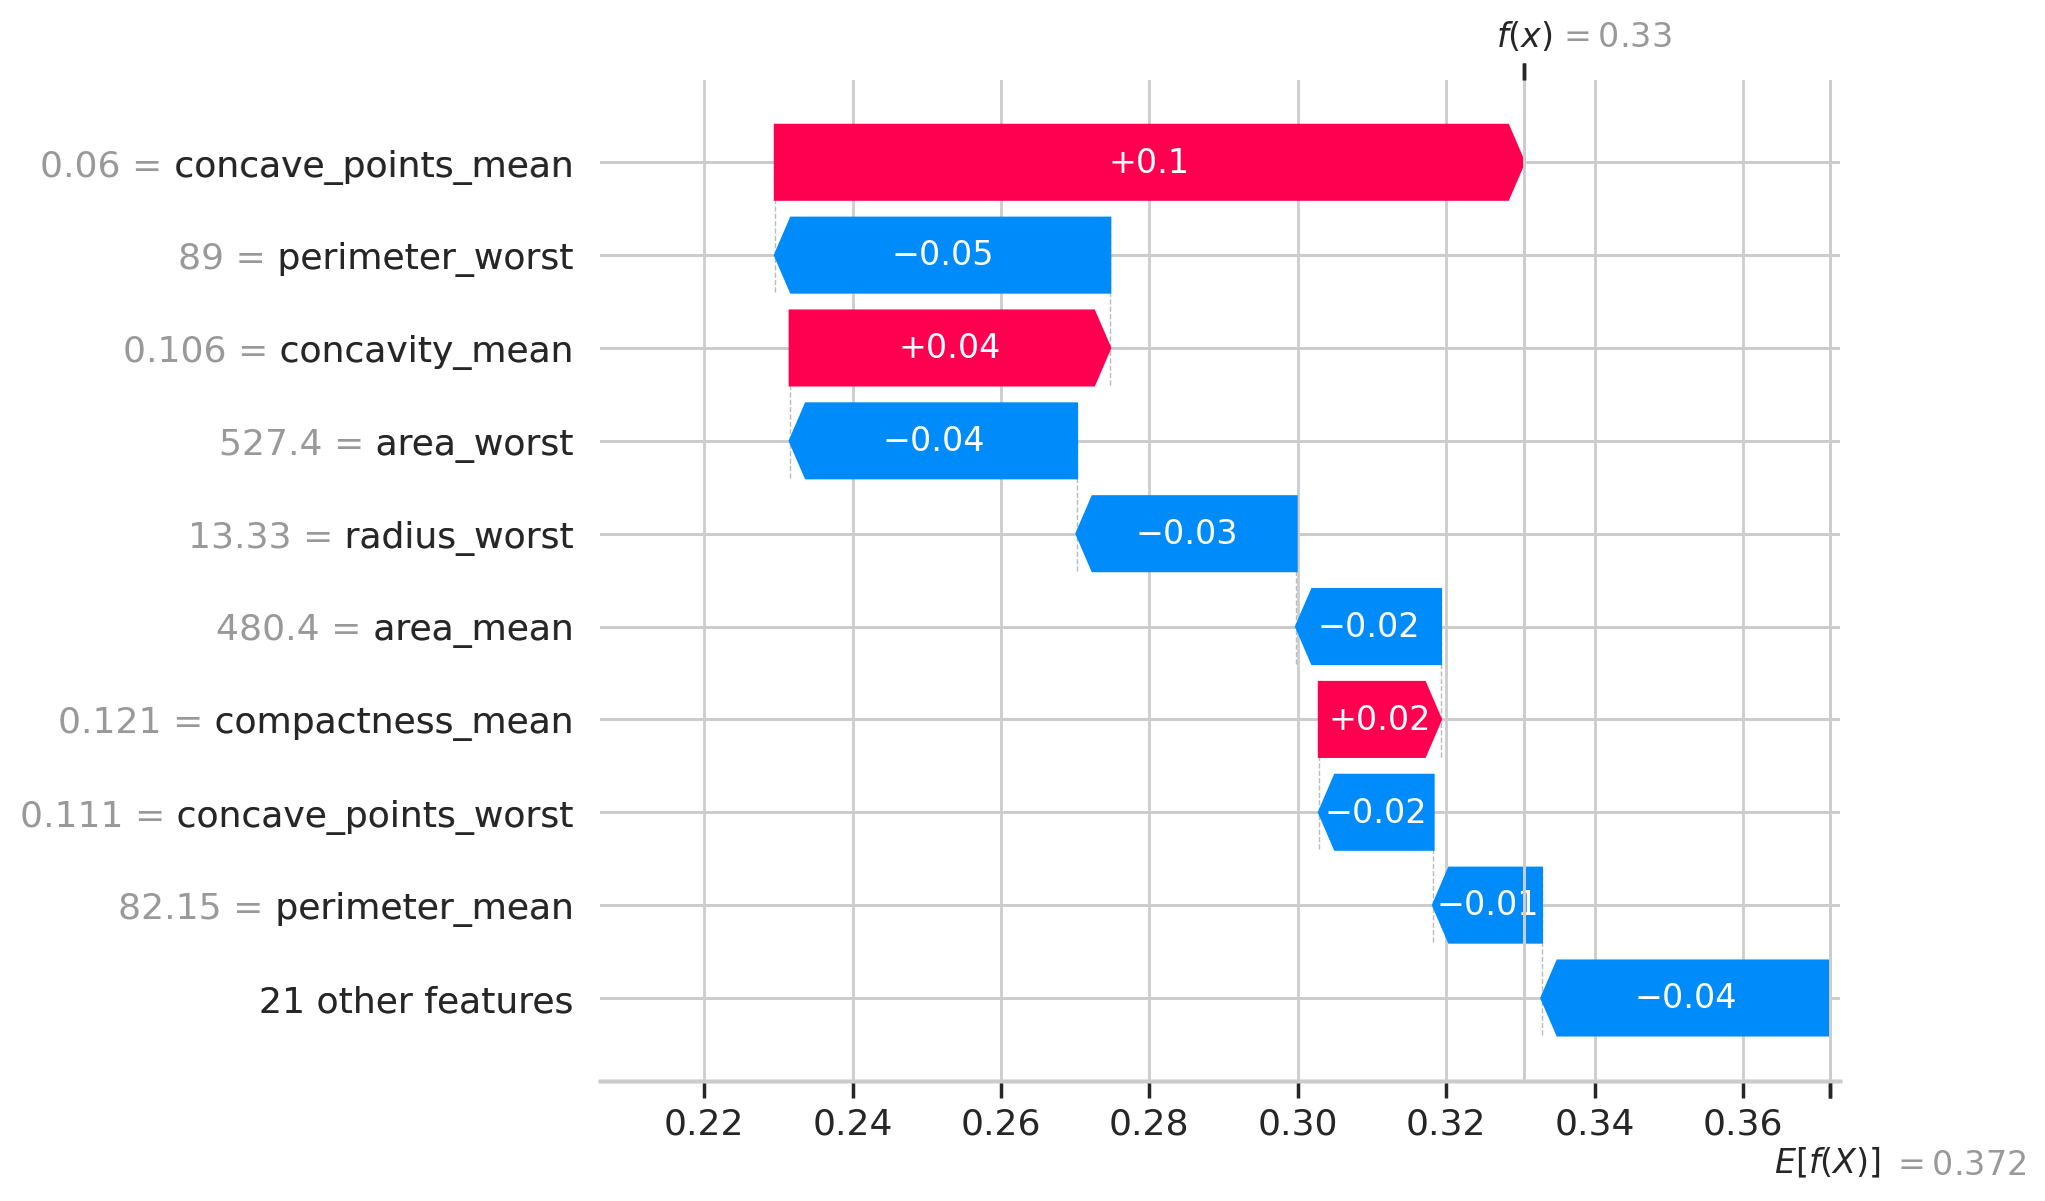

>>> Muestra 3: fila 90  |  clase real = M  |  probabilidad predicha de la clase analizada = 0.64


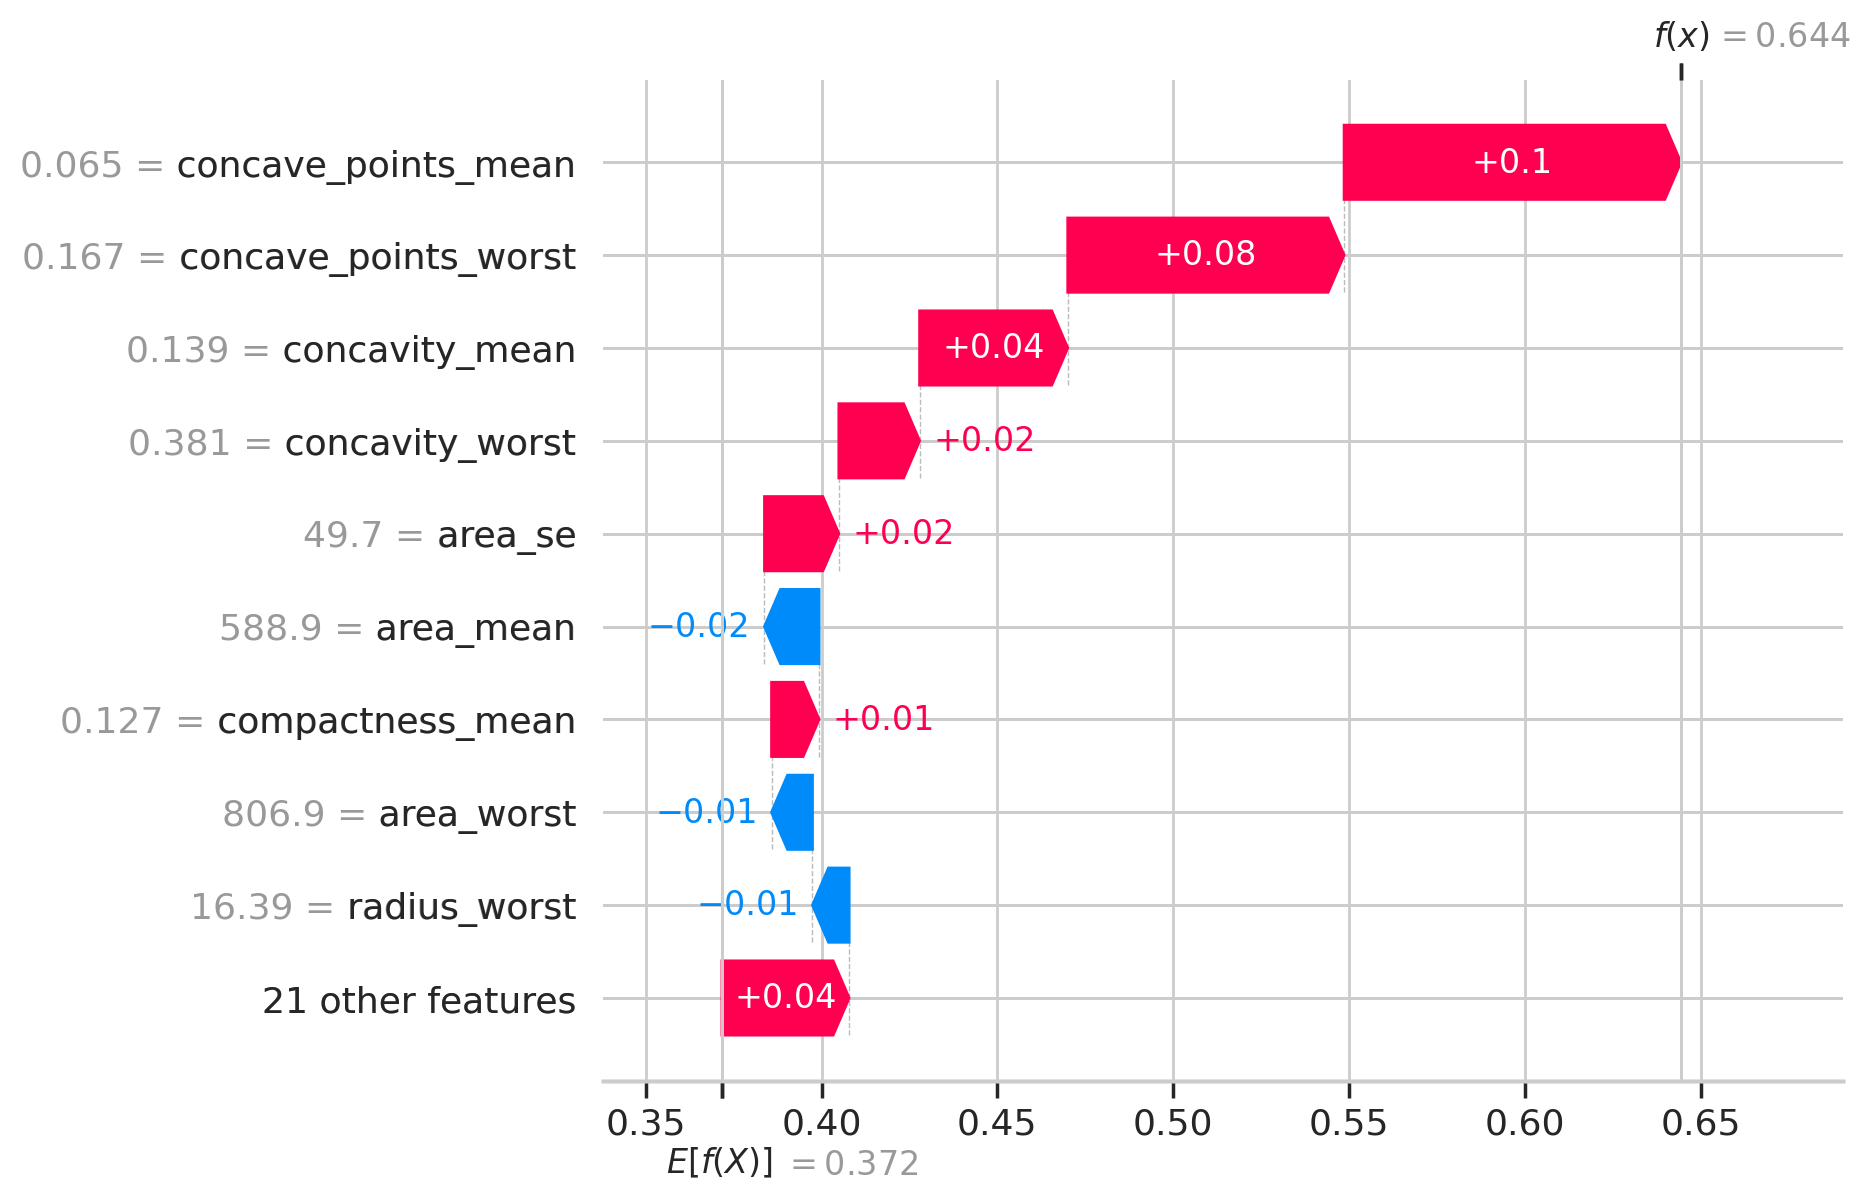

>>> Muestra 4: fila 123  |  clase real = M  |  probabilidad predicha de la clase analizada = 0.98


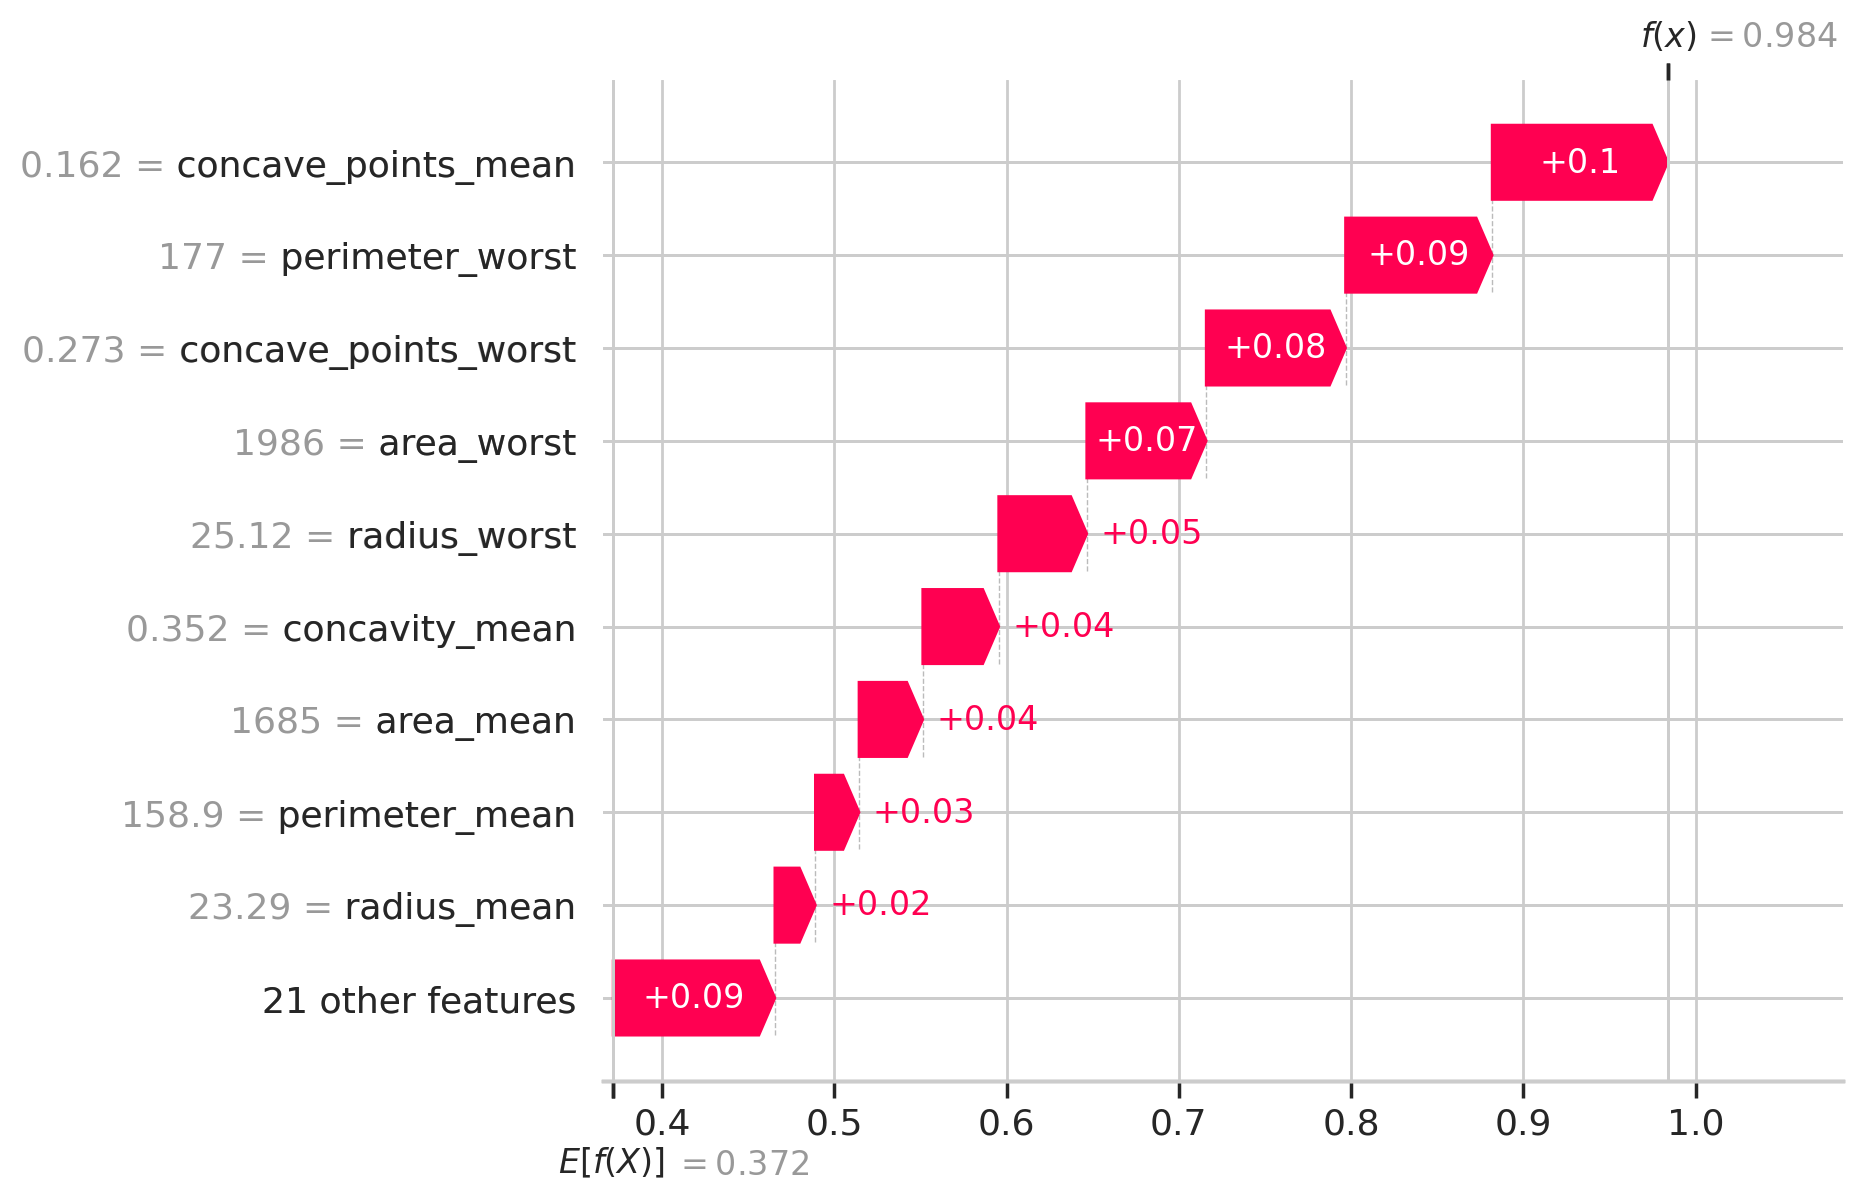

In [36]:
proba_M = rf_c.predict_proba(muestra)[:, 1]
waterfalls_muestras(shap_M, proba_M, ys_c, n=4)

Se aprecia el contraste: en un paciente **benigno** casi todas las barras son **azules** (empujan a benigno) y la probabilidad final es ≈ 0; en uno **maligno**, dominan las **rojas** y la probabilidad ≈ 1; los casos **intermedios** mezclan empujes en ambos sentidos. Así se justifica, paciente a paciente, **por qué** el modelo decide lo que decide.



#### Forma del efecto: gráfico de dependencia (*scatter*)

Recordatorio de lectura: el **eje X** es el **valor real** de la variable y el **eje Y** su **valor SHAP**; la nube muestra **cómo cambia el empuje de la variable a medida que cambia su valor**, y el color codifica la variable que más interactúa con ella.

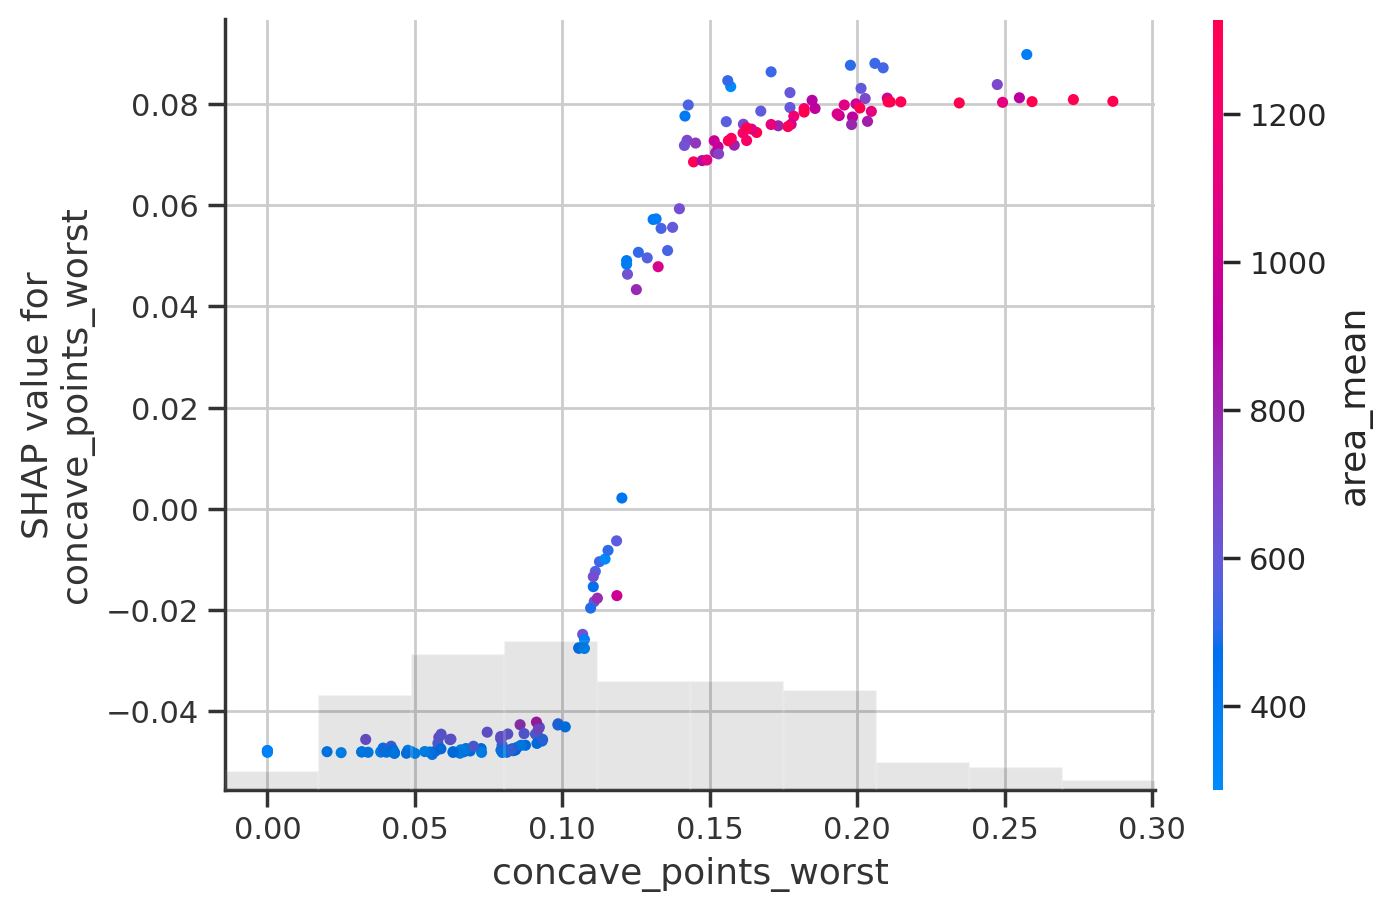

In [37]:
shap.plots.scatter(shap_M[:, 'concave_points_worst'], color=shap_M)

A partir de cierto **umbral** de `concave_points_worst` el SHAP **se dispara** hacia valores positivos: por encima de ese punto la variable empuja con fuerza hacia **maligno** (efecto **no lineal, de umbral**). El color revela posibles **interacciones** con otra variable.

## <font color="steelblue">9.5. Ejemplo 5: Potabilidad del agua</font>

Clasificamos el agua como **potable (1)** o **no potable (0)**. Cargamos `water_potability.csv` **sin limpiar**: contiene **valores ausentes**, así que el único preprocesado necesario para árboles es **imputar la mediana** (no escalamos, sección 7). Las clases están **desequilibradas** (≈61 % no potable): medimos con **F1 ponderada** y usamos `class_weight='balanced'` en el modelo final.

In [38]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/water_potability.csv'
water = pd.read_csv(url)
print('Dimensiones:', water.shape, '| ausentes:', int(water.isna().sum().sum()))
water = water.fillna(water.median(numeric_only=True))      # imputación de la mediana
water['Potability'] = water['Potability'].astype('category')
tr, te = split_sample(water, 'Potability', 0.3, 0, True)
Xtr_w, ytr_w = tr.drop(columns='Potability'), tr['Potability']
Xte_w, yte_w = te.drop(columns='Potability'), te['Potability']

Dimensiones: (3276, 10) | ausentes: 1434
Estratificando por 'Potability'.
  Entrenamiento: 2293 muestras | Test: 983 muestras


### Random Forest vs Extra Trees y diagnóstico de sobreajuste

In [39]:
tabla_w, modelos_w = comparar_rf_extra(Xtr_w, ytr_w, Xte_w, yte_w)
tabla_w

,F1 train,F1 test,desfase (train-test)
modelo,,,
Random Forest,1.0,0.638,0.362
Extra Trees,1.0,0.635,0.365


De nuevo **F1 train ≈ 1.0** frente a **test ≈ 0.64**: un **desfase grande** que delata **sobreajuste**. RF y Extra Trees son equivalentes. Optimizamos para intentar reducir el desfase.

### Optimización de hiperparámetros (grid sobre OOB)

In [40]:
malla = {'n_estimators': [300], 'max_depth': [6, 10, 14, None],
         'min_samples_leaf': [0.1, 0.15, 0.20], 'max_features': ['sqrt']}
rf_w, params_w, oob_w = optimizar_oob(Xtr_w, ytr_w, malla)
rf_w = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=RNG, **params_w).fit(Xtr_w, ytr_w)
print('Mejores hiperparámetros:', params_w, '| OOB =', round(oob_w, 3))
print(f'F1 train = {f1_score(ytr_w, rf_w.predict(Xtr_w), average="weighted"):.3f} | '
      f'F1 test = {f1_score(yte_w, rf_w.predict(Xte_w), average="weighted"):.3f}')

Mejores hiperparámetros: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 0.1, 'n_estimators': 300} | OOB = 0.61
F1 train = 0.621 | F1 test = 0.561


La optimización **reduce el desfase** train-test, pero el test se queda en torno a **0.6**: como en abulones, el problema tiene una **dificultad intrínseca** (las propiedades químicas no separan bien la potabilidad).

### Evaluación del modelo óptimo

In [41]:
reports_clas(rf_w, Xtr_w, ytr_w, Xte_w, yte_w)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.70      0.65      0.67      1398
           1       0.51      0.57      0.54       895

    accuracy                           0.62      2293
   macro avg       0.60      0.61      0.61      2293
weighted avg       0.63      0.62      0.62      2293


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.65      0.60      0.62       600
           1       0.44      0.50      0.47       383

    accuracy                           0.56       983
   macro avg       0.54      0.55      0.54       983
weighted avg       0.57      0.56      0.56       983



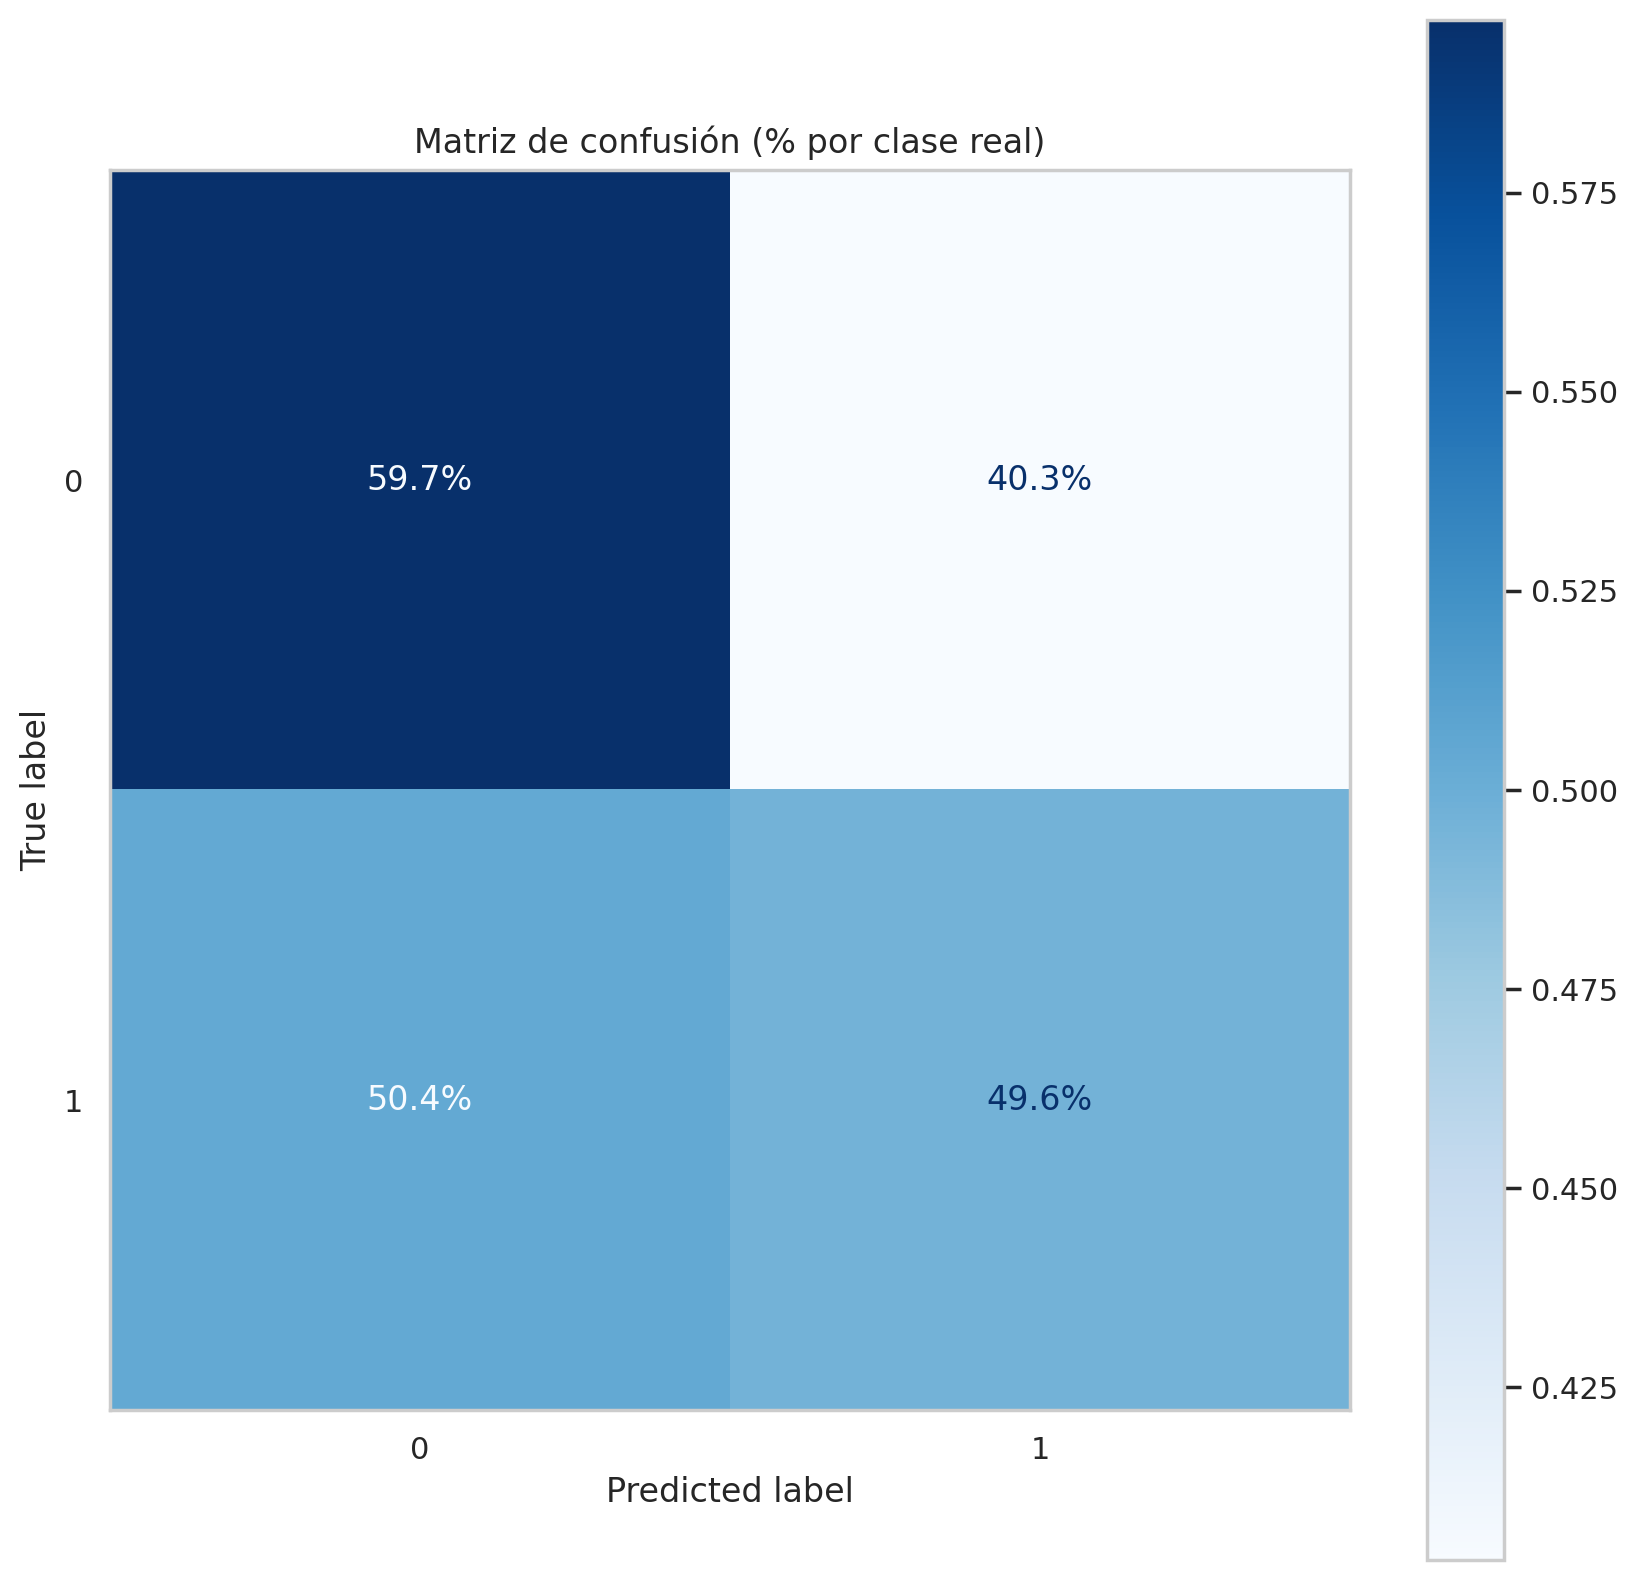

In [42]:
matriz_confusion(rf_w, Xte_w, yte_w);

Pese a la ponderación, el modelo acierta mejor la clase mayoritaria (no potable). La validación es estable en torno a 0.6 y la curva de aprendizaje sugiere que más datos apenas mejorarían.

### Importancia de los predictores

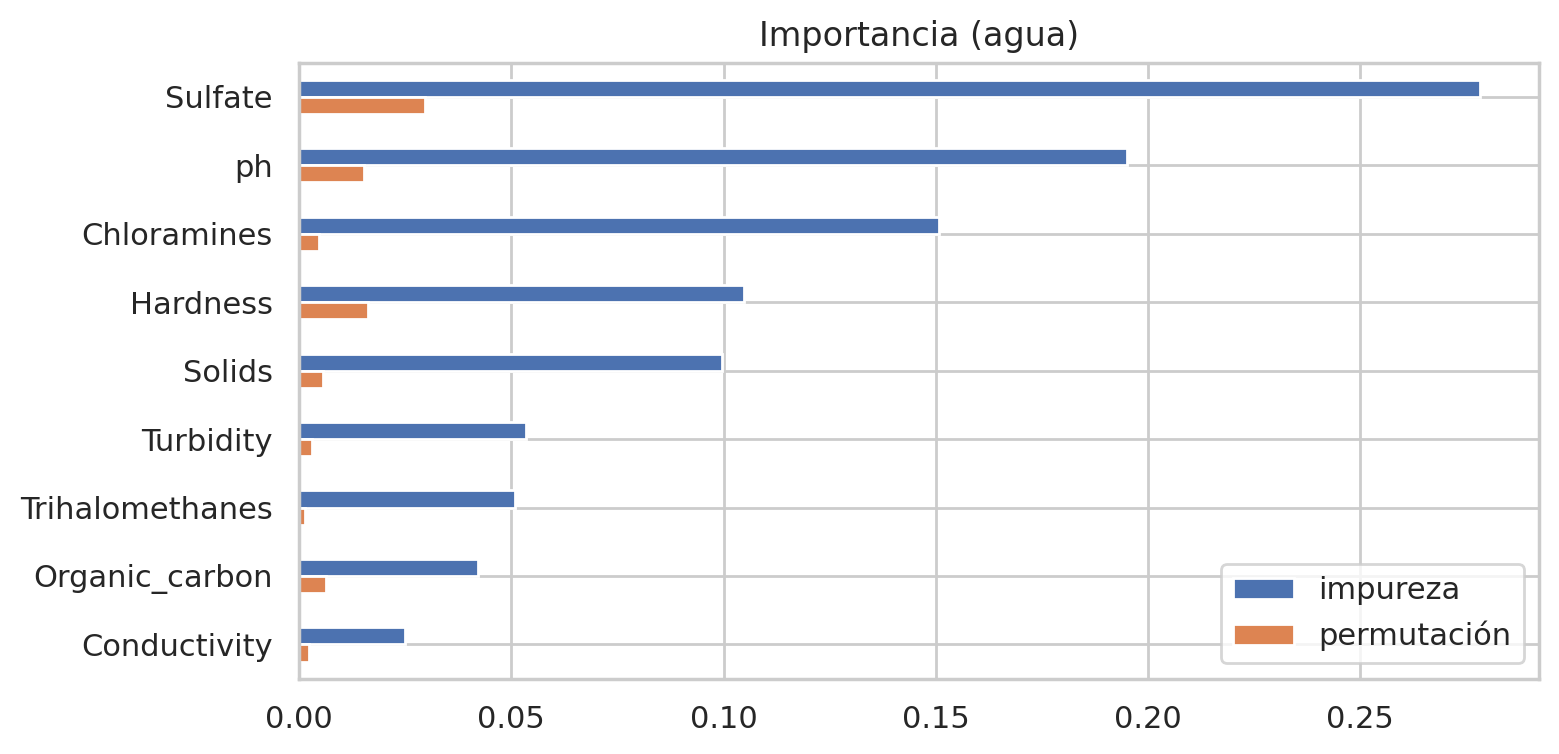

,impureza,permutación
Sulfate,0.278,0.030
ph,0.195,0.015
Chloramines,0.151,0.005
Hardness,0.105,0.016
Solids,0.100,0.006
Turbidity,0.053,0.003
Trihalomethanes,0.051,0.001
Organic_carbon,0.042,0.006
Conductivity,0.025,0.002


In [43]:
imp_mdi = pd.Series(rf_w.feature_importances_, index=Xtr_w.columns)
perm_w = permutation_importance(rf_w, Xte_w, yte_w, n_repeats=10, random_state=0, scoring='f1_weighted')
imp_perm = pd.Series(perm_w.importances_mean, index=Xte_w.columns)
comp_w = pd.DataFrame({'impureza': imp_mdi, 'permutación': imp_perm}).sort_values('impureza', ascending=False)
comp_w.plot.barh(figsize=(8, 4)); plt.gca().invert_yaxis(); plt.title('Importancia (agua)'); plt.show()
comp_w.round(3)

La importancia se reparte de forma **bastante homogénea** entre las variables químicas (con `Sulfate`, `ph` y `Hardness` algo por delante): **ninguna** propiedad determina por sí sola la potabilidad.

### Explicabilidad con valores de Shapley (SHAP)

Problema binario: tomamos la clase **potable (1)**.

In [44]:
Xs_w = Xte_w.reset_index(drop=True)
ys_w = yte_w.reset_index(drop=True)
expl_w = shap.TreeExplainer(rf_w)(Xs_w)
shap_pot = expl_w[:, :, 1]
print('Forma de los valores SHAP:', np.array(expl_w.values).shape)
print('Valor base (probabilidad media de potable):', round(float(expl_w.base_values[0, 1]), 3))

Forma de los valores SHAP: (983, 9, 2)
Valor base (probabilidad media de potable): 0.5


#### Importancia global: gráfico de barras

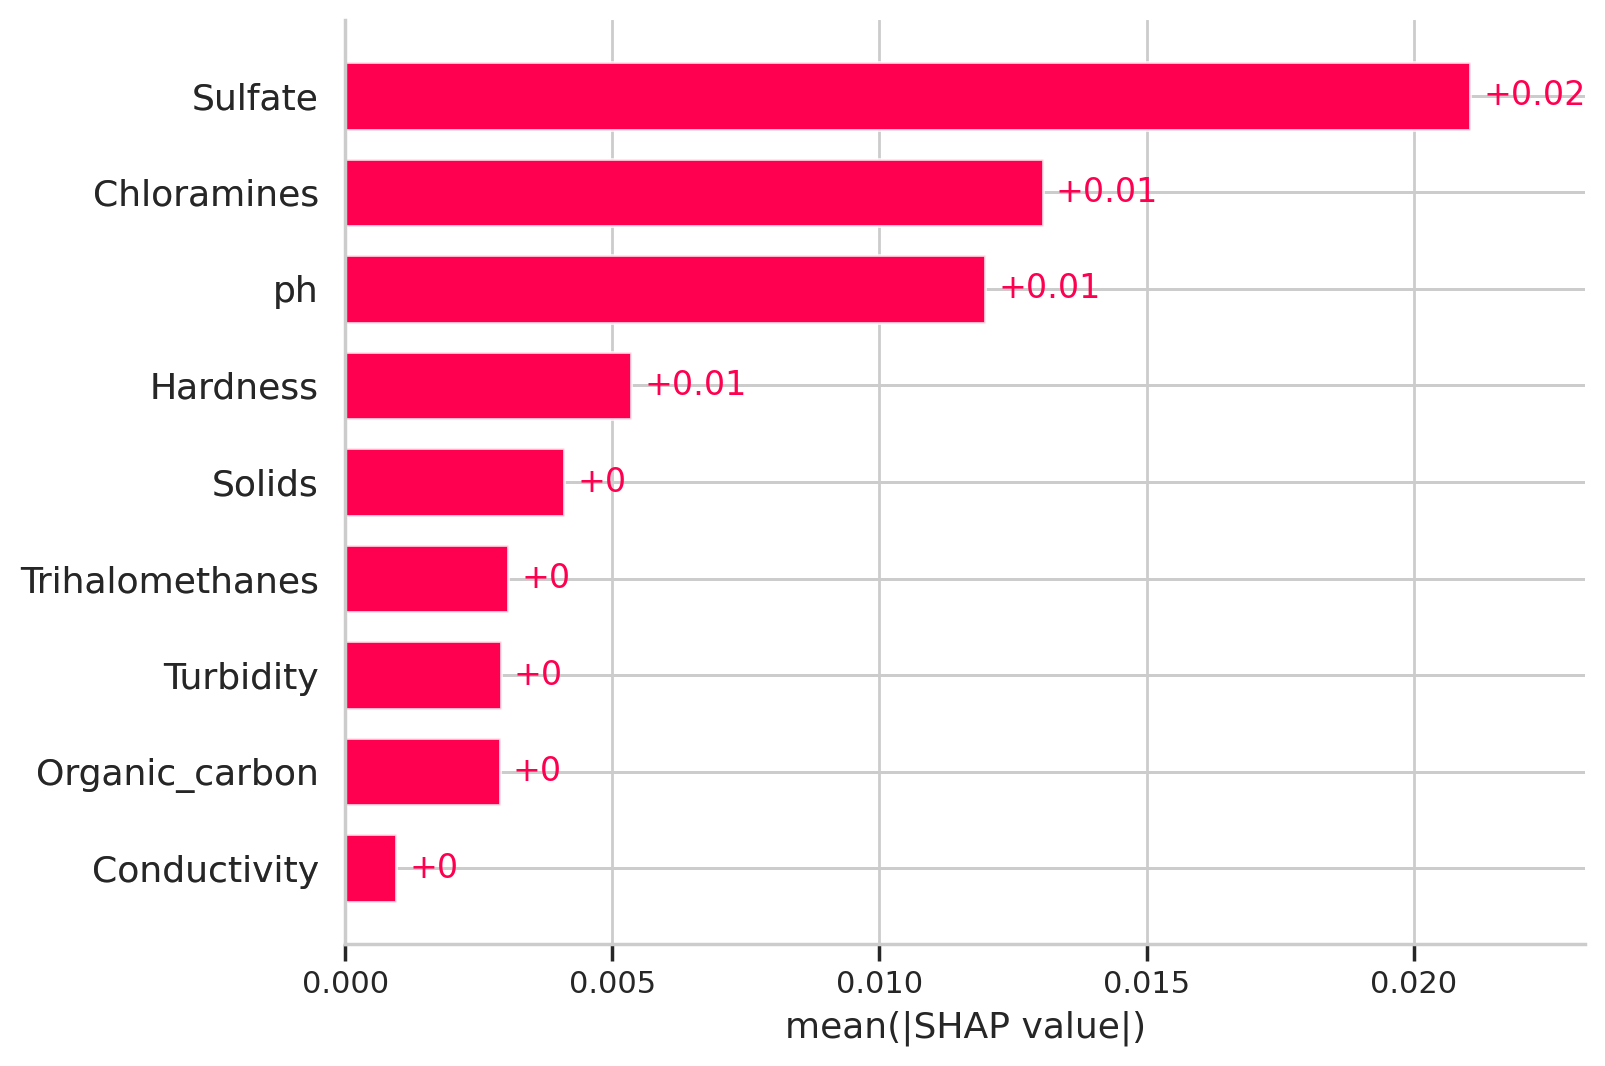

In [45]:
shap.plots.bar(shap_pot, max_display=9)

Confirma el reparto **homogéneo** de la importancia: barras de longitudes parecidas, sin una variable claramente dominante.



#### Efecto y dirección: gráfico de enjambre (*beeswarm*)

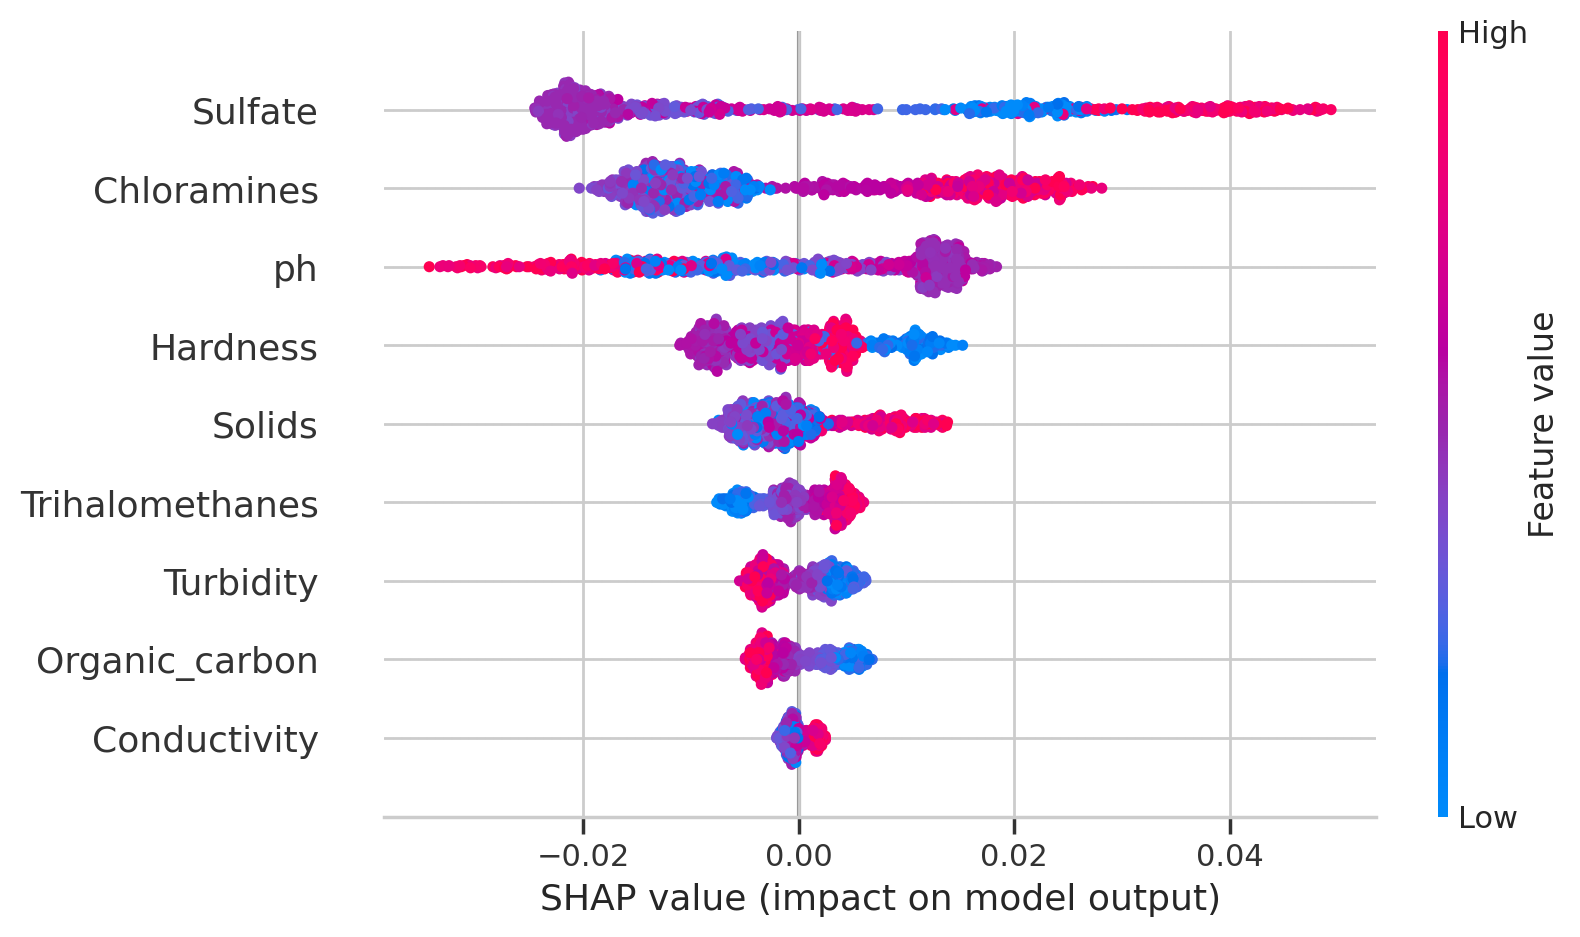

In [46]:
shap.plots.beeswarm(shap_pot, max_display=9)

Los empujes son **moderados** y los colores están **mezclados** (no se separan a un lado u otro): las variables **no discriminan** con claridad la potabilidad, lo que explica el bajo rendimiento.



#### Explicación local de 4 muestras (*waterfall*)

Cuatro muestras de agua que cubren el rango de probabilidad, con su fila, su clase real y su probabilidad predicha.

>>> Muestra 1: fila 109  |  clase real = 0  |  probabilidad predicha de la clase analizada = 0.42


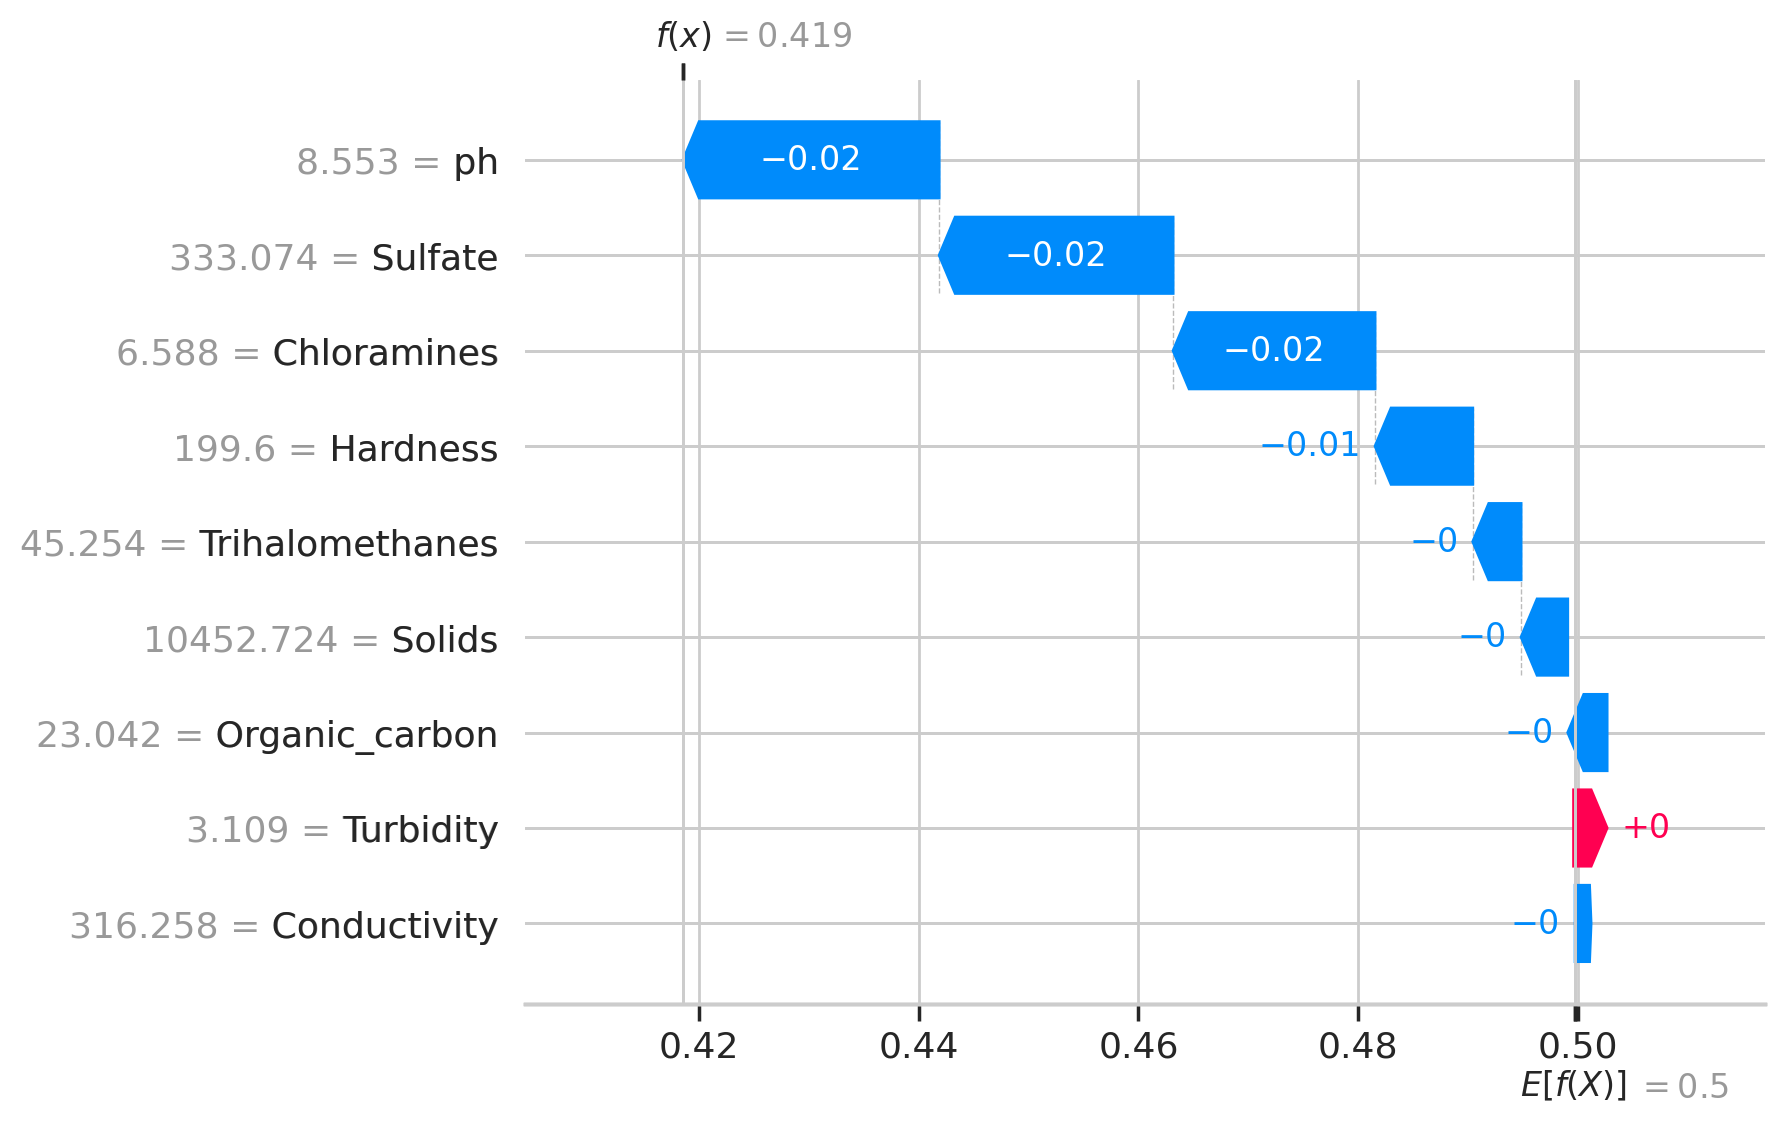

>>> Muestra 2: fila 338  |  clase real = 1  |  probabilidad predicha de la clase analizada = 0.47


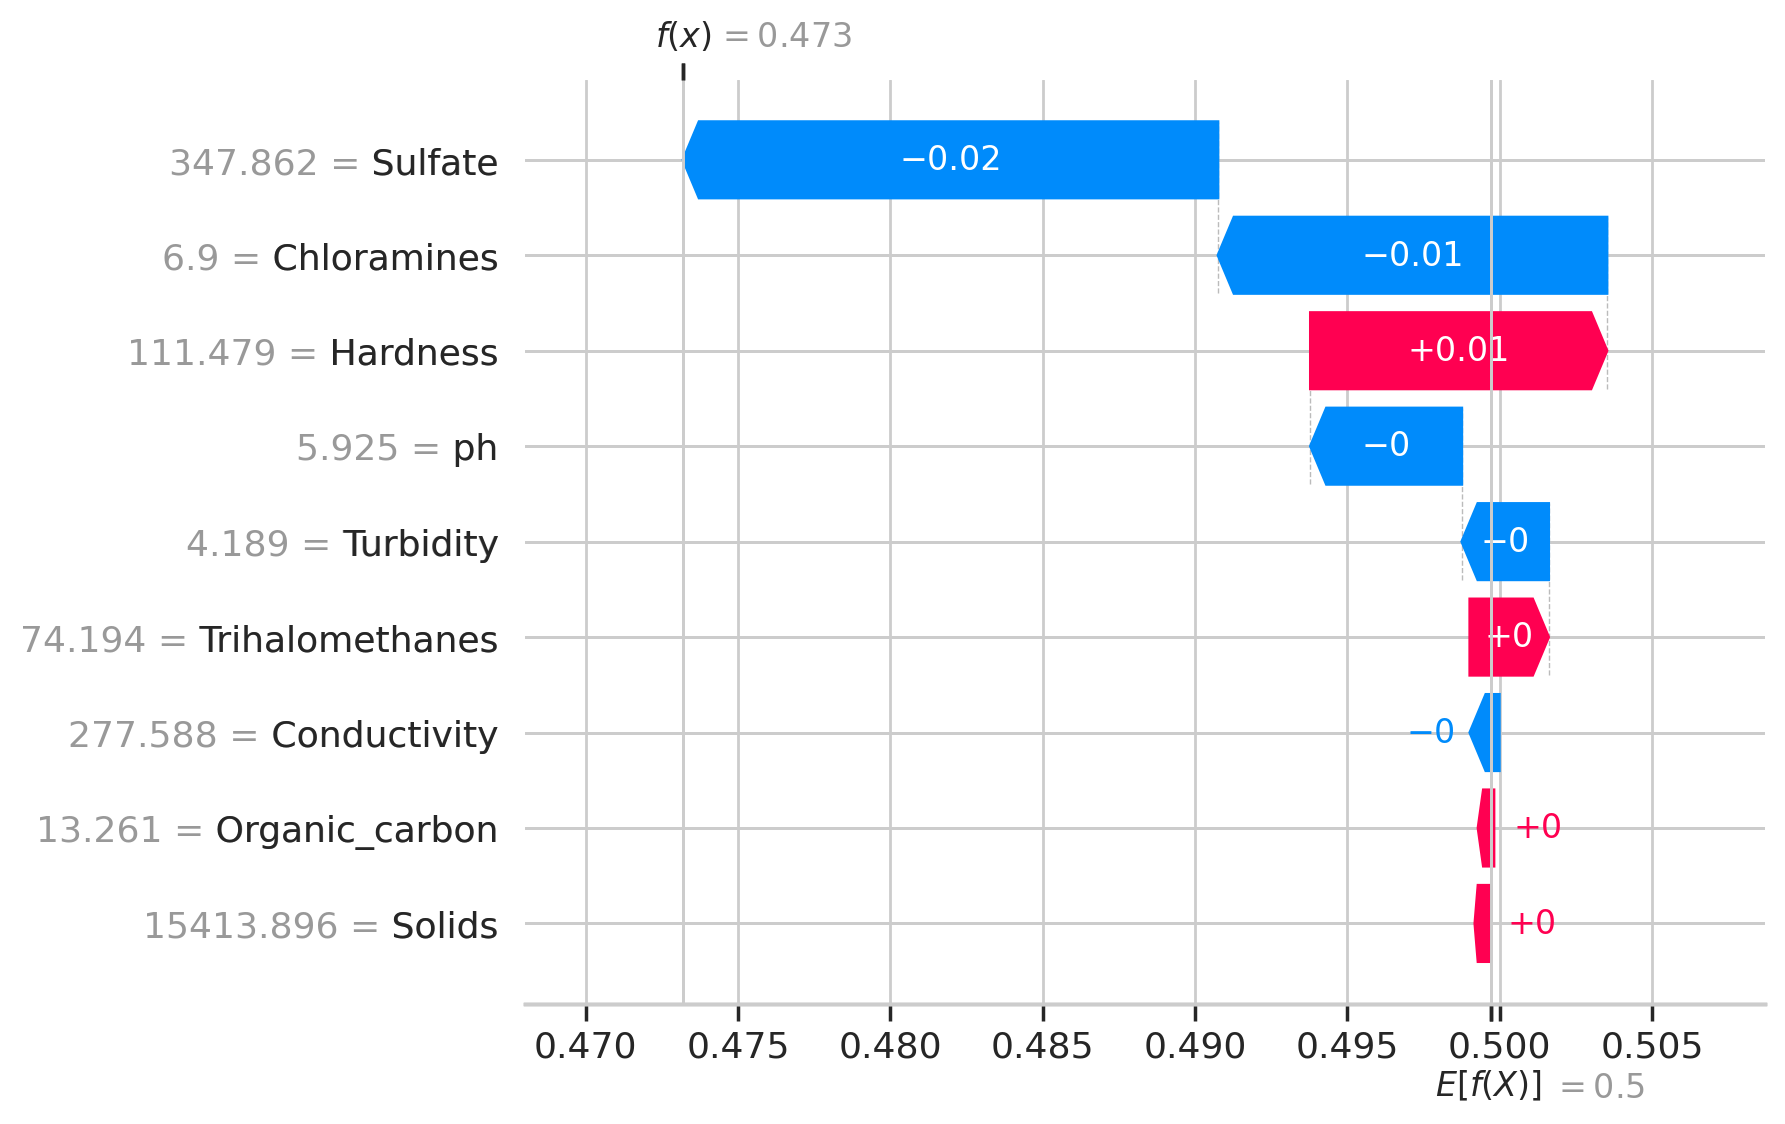

>>> Muestra 3: fila 9  |  clase real = 1  |  probabilidad predicha de la clase analizada = 0.53


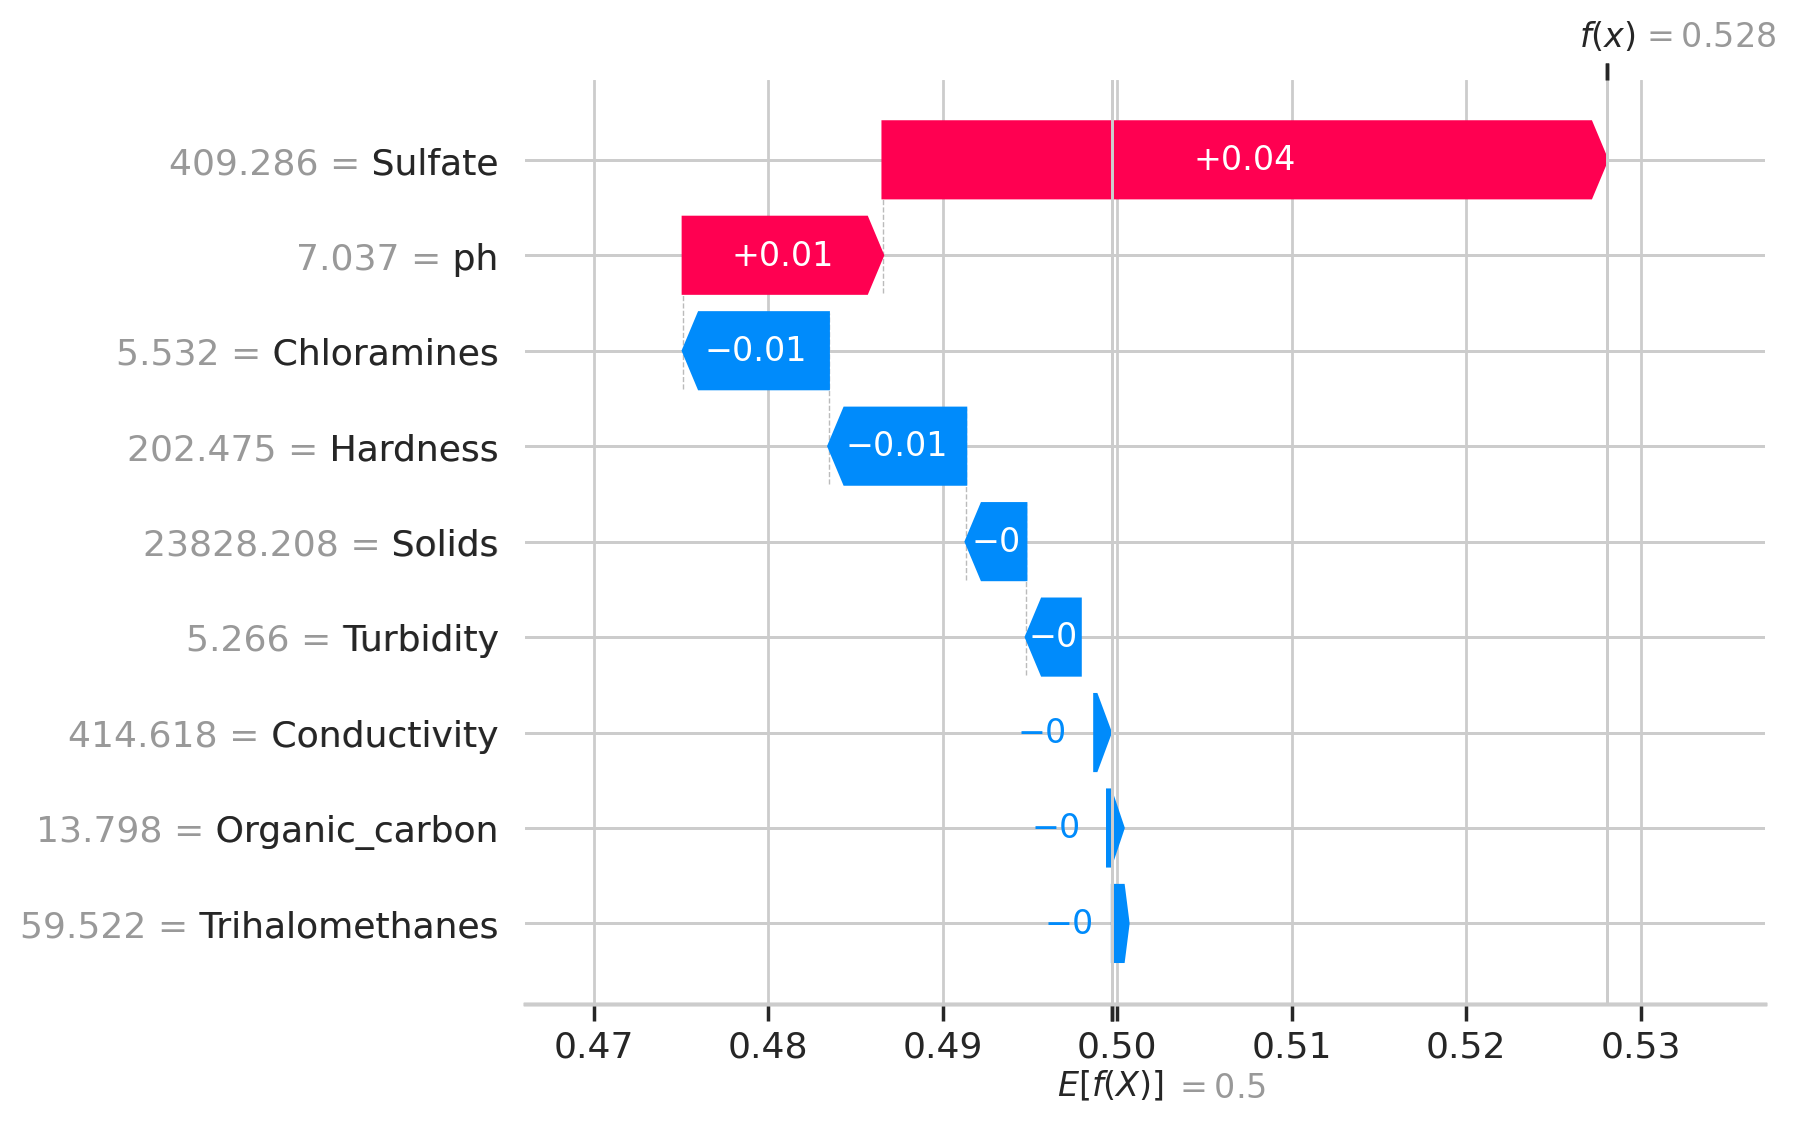

>>> Muestra 4: fila 95  |  clase real = 1  |  probabilidad predicha de la clase analizada = 0.58


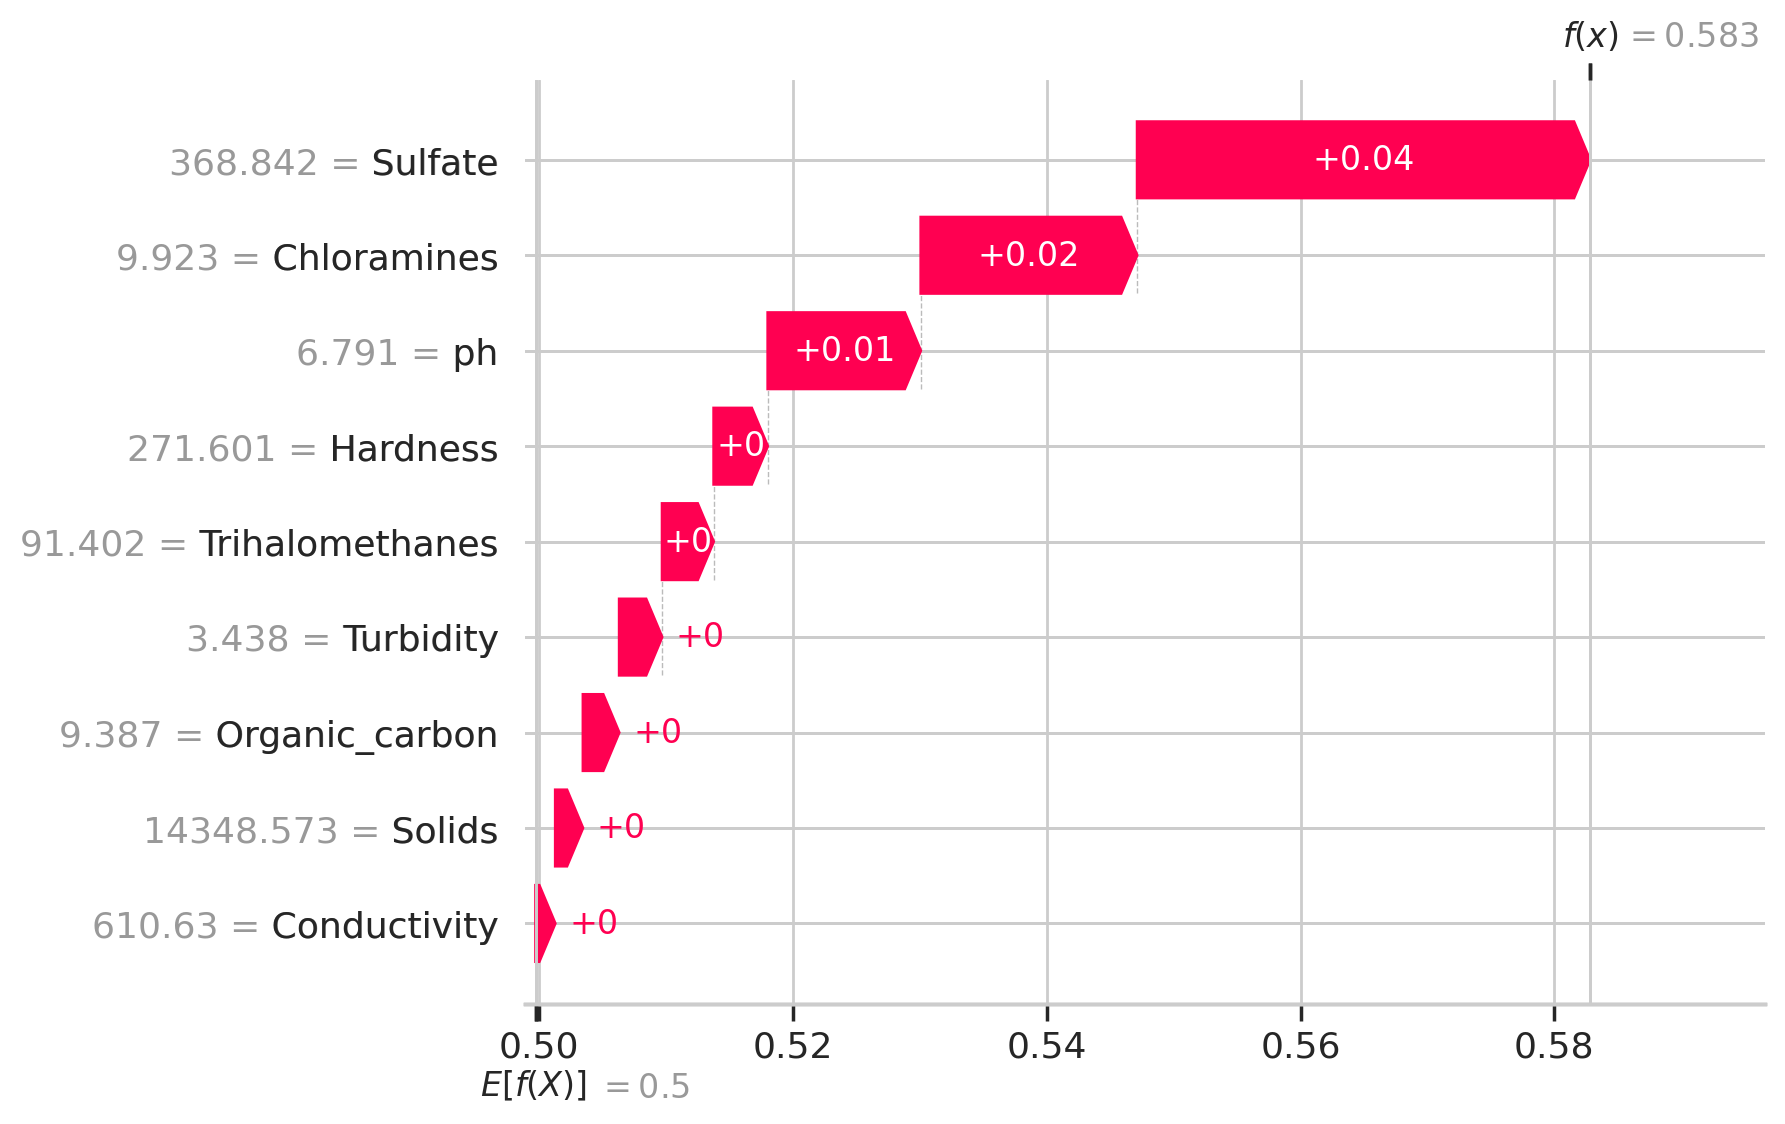

In [47]:
proba_pot = rf_w.predict_proba(Xs_w)[:, 1]
waterfalls_muestras(shap_pot, proba_pot, ys_w, n=4)

Al ser un problema difícil, las explicaciones son **menos contundentes** que en cáncer: muchas variables aportan empujes pequeños en distintos sentidos, sin un factor decisivo, incluso en las muestras con probabilidad más extrema.

#### Forma del efecto: gráfico de dependencia (*scatter*)

Recordatorio: **eje X** = valor real de la variable, **eje Y** = su valor SHAP; muestra cómo cambia el empuje según el valor, y el color codifica la variable que más interactúa.

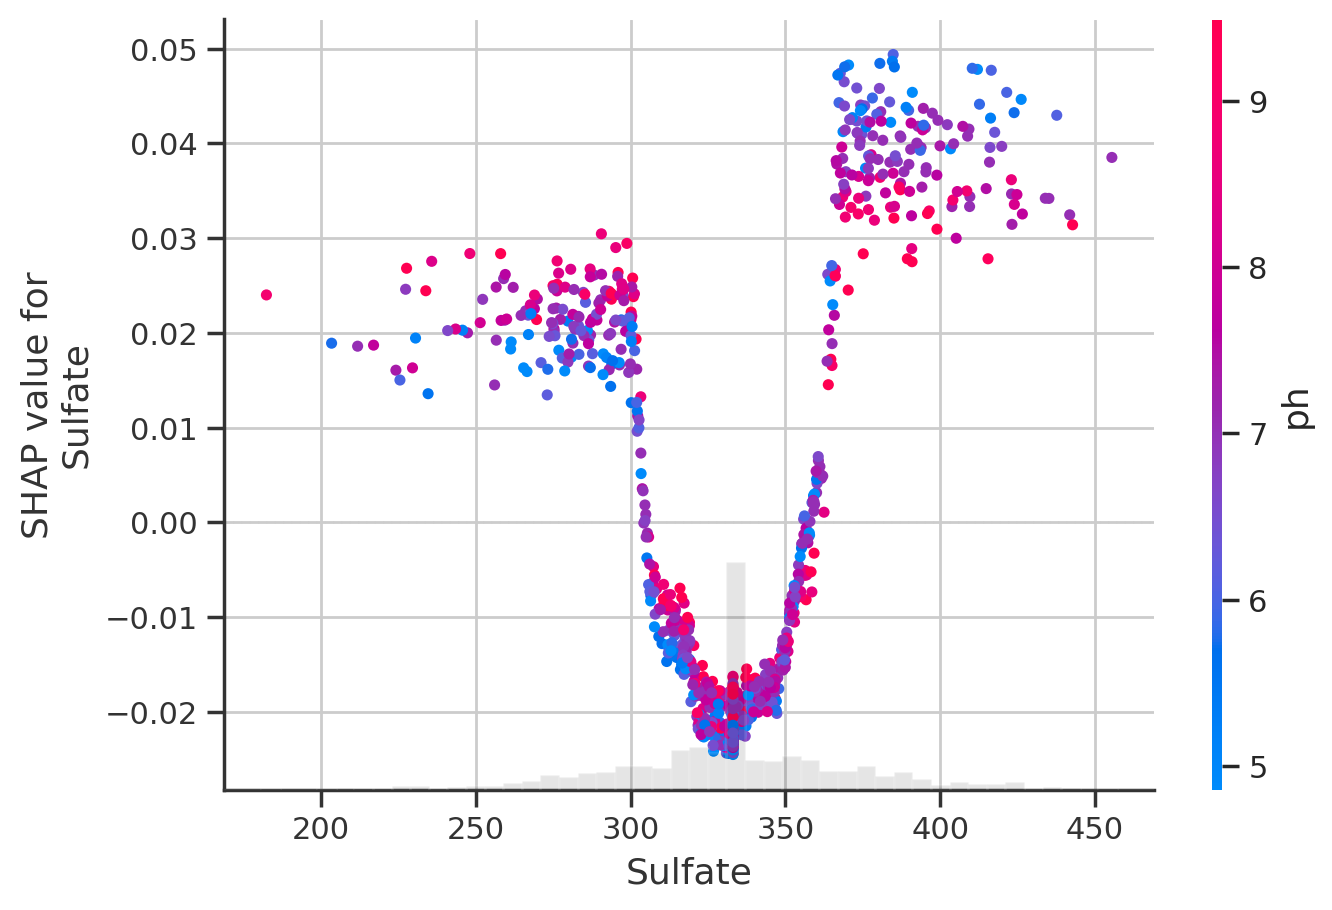

In [48]:
shap.plots.scatter(shap_pot[:, 'Sulfate'], color=shap_pot)

La nube es **muy difusa** (gran dispersión vertical para cada valor de X): el efecto de `Sulfate` **depende fuertemente de otras variables** (interacciones) y no tiene una forma simple, otra señal de la complejidad del problema.



# <font color="steelblue">Referencias</font>

* Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1).
* Geurts, Ernst & Wehenkel (2006). *Extremely Randomized Trees*. Machine Learning, 63(1).
* Lundberg, S. & Lee, S. (2017). *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS.
* Molnar, C. (2022). *Interpretable Machine Learning* (2ª ed.). https://christophm.github.io/interpretable-ml-book/
* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 8). Springer.
* scikit-learn — *Ensembles*: https://scikit-learn.org/stable/modules/ensemble.html
* Documentación de `shap`: https://shap.readthedocs.io
